In [2]:
import os, pandas as pd, subprocess, time, numpy as np
from google.cloud import bigquery

result = subprocess.run(['bash', '-c', 'source ~/load-env.sh && env'], capture_output=True, text=True)
for line in result.stdout.split('\n'):
    if '=' in line:
        key, _, value = line.partition('=')
        if any(k in key.upper() for k in ['CDR', 'WORKSPACE', 'GOOGLE_PROJECT', 'AOU', 'BUCKET']):
            os.environ[key] = value

CDR = os.environ['WORKSPACE_CDR']
client = bigquery.Client()

# Reload all analysis data
analytic_df = pd.read_csv('analytic_cohort.csv')
windows_df = pd.read_csv('case_control_windows.csv', parse_dates=['window_start', 'window_end', 'event_date'])
hormonal = pd.read_csv('hormonal_status.csv')
event_history = pd.read_csv('window_event_history.csv', parse_dates=['window_start', 'window_end', 'event_date'])
full_features = pd.read_csv('window_features_full.csv', low_memory=False)

print(f"CDR: {CDR}")
print(f"\nReloaded everything:")
print(f"  Cohort: {len(analytic_df)} patients")
print(f"  Windows: {len(windows_df):,}")
print(f"  Hormonal: {len(hormonal)}")
print(f"  Event history: {len(event_history):,}")
print(f"  Full features: {full_features.shape}")

CDR: wb-affable-acorn-7941.R2024Q3R8

Reloaded everything:
  Cohort: 1700 patients
  Windows: 42,149
  Hormonal: 1700
  Event history: 42,149
  Full features: (30573, 150)


In [2]:
def safe_query(sql, client, max_bytes_gb=30, timeout_minutes=10, dry_run_first=True, label=None):
    if dry_run_first:
        dry_config = bigquery.QueryJobConfig(dry_run=True, use_query_cache=False)
        try:
            dry_job = client.query(sql, job_config=dry_config)
            gb = dry_job.total_bytes_processed / (1024**3)
            print(f"  [Dry run] Will scan {gb:.2f} GB (~${gb * 0.005:.3f})")
            if gb > max_bytes_gb:
                print(f"  REFUSED: {gb:.2f} GB exceeds cap of {max_bytes_gb} GB")
                return None
        except Exception as e:
            print(f"  [Dry run] Failed: {e}")
            return None
    
    job_config = bigquery.QueryJobConfig(maximum_bytes_billed=int(max_bytes_gb * 1024**3))
    label_str = f"[{label}] " if label else ""
    t0 = time.time()
    try:
        job = client.query(sql, job_config=job_config)
        result = job.result(timeout=timeout_minutes * 60)
        df = result.to_dataframe()
        elapsed = time.time() - t0
        gb_billed = (job.total_bytes_billed or 0) / (1024**3)
        print(f"  {label_str}Done in {elapsed:.0f}s, {len(df):,} rows, billed {gb_billed:.2f} GB")
        return df
    except Exception as e:
        elapsed = time.time() - t0
        try: job.cancel()
        except: pass
        print(f"  {label_str}FAILED after {elapsed:.0f}s: {type(e).__name__}: {str(e)[:200]}")
        return None

print("safe_query helper loaded.")

safe_query helper loaded.


In [ ]:
import os, pandas as pd, subprocess, time, numpy as np
from google.cloud import bigquery

# Reload AoU environment
result = subprocess.run(['bash', '-c', 'source ~/load-env.sh && env'], capture_output=True, text=True)
for line in result.stdout.split('\n'):
    if '=' in line:
        key, _, value = line.partition('=')
        if any(k in key.upper() for k in ['CDR', 'WORKSPACE', 'GOOGLE_PROJECT', 'AOU', 'BUCKET']):
            os.environ[key] = value

CDR = os.environ['WORKSPACE_CDR']
client = bigquery.Client()

# Reload cohorts and windows
analytic_df = pd.read_csv('analytic_cohort.csv')
windows_df = pd.read_csv('case_control_windows.csv', parse_dates=['window_start', 'window_end', 'event_date'])

print(f"CDR: {CDR}")
print(f"Analytic cohort: {len(analytic_df):,}")
print(f"Windows: {len(windows_df):,}")


def safe_query(sql, client, max_bytes_gb=30, timeout_minutes=10, dry_run_first=True, label=None):
    """
    Run BigQuery with safety guards:
    - Dry run to estimate cost
    - Hard cap on bytes billed
    - Client-side timeout (kernel won't hang)
    Returns: DataFrame or None if failed/cancelled
    """
    if dry_run_first:
        dry_config = bigquery.QueryJobConfig(dry_run=True, use_query_cache=False)
        try:
            dry_job = client.query(sql, job_config=dry_config)
            gb_to_scan = dry_job.total_bytes_processed / (1024**3)
            est_cost = gb_to_scan * 0.005
            print(f"  [Dry run] Will scan {gb_to_scan:.2f} GB (~${est_cost:.3f})")
            if gb_to_scan > max_bytes_gb:
                print(f"  REFUSED: {gb_to_scan:.2f} GB exceeds cap of {max_bytes_gb} GB")
                return None
        except Exception as e:
            print(f"  [Dry run] Failed: {e}")
            return None
    
    job_config = bigquery.QueryJobConfig(
        maximum_bytes_billed=int(max_bytes_gb * 1024**3),
    )
    
    label_str = f"[{label}] " if label else ""
    t0 = time.time()
    
    try:
        job = client.query(sql, job_config=job_config)
        result = job.result(timeout=timeout_minutes * 60)
        df = result.to_dataframe()
        elapsed = time.time() - t0
        gb_billed = (job.total_bytes_billed or 0) / (1024**3)
        print(f"  {label_str}Done in {elapsed:.0f}s, {len(df):,} rows, billed {gb_billed:.2f} GB")
        return df
    except Exception as e:
        elapsed = time.time() - t0
        try:
            job.cancel()
        except Exception:
            pass
        print(f"  {label_str}FAILED after {elapsed:.0f}s: {type(e).__name__}: {str(e)[:200]}")
        return None

print("\nsafe_query() helper ready.")

In [ ]:
# Load the All of Us environment variables
!cat /home/jupyter/load-env.sh

In [2]:
import subprocess
import os

# Source the load-env.sh script and capture the resulting environment
result = subprocess.run(
    ['bash', '-c', 'source ~/load-env.sh && env'],
    capture_output=True, text=True
)

if result.returncode != 0:
    print("STDERR:", result.stderr)
else:
    # Parse the env output and inject relevant vars into Python's os.environ
    for line in result.stdout.split('\n'):
        if '=' in line:
            key, _, value = line.partition('=')
            # Only inject the AoU-relevant ones to avoid clobbering everything
            if any(k in key.upper() for k in ['CDR', 'WORKSPACE', 'GOOGLE_PROJECT', 'AOU', 'BIGQUERY', 'BUCKET']):
                os.environ[key] = value

# Print what got set
print("AoU environment variables now available:")
for key in sorted(os.environ.keys()):
    if any(k in key.upper() for k in ['CDR', 'WORKSPACE', 'GOOGLE_PROJECT', 'AOU', 'BUCKET']):
        # Truncate long values for readability
        val = os.environ[key]
        if len(val) > 100:
            val = val[:100] + '...'
        print(f"  {key} = {val}")

AoU environment variables now available:
  WORKSPACE_BUCKET = gs://cloned-mybucket-wb-blinding-pecan-7025
  WORKSPACE_CDR = wb-affable-acorn-7941.R2024Q3R8
  WORKSPACE_UFID = early-migraine-detection


In [4]:
from google.cloud import bigquery
import pandas as pd
import os

client = bigquery.Client()
CDR = os.environ['WORKSPACE_CDR']

# Find all migraine-related concepts in the OMOP vocabulary
query = f"""
SELECT 
    c.concept_id,
    c.concept_code,
    c.concept_name,
    c.vocabulary_id,
    c.standard_concept,
    COUNT(DISTINCT co.person_id) AS n_patients
FROM `{CDR}.concept` c
LEFT JOIN `{CDR}.condition_occurrence` co
    ON co.condition_concept_id = c.concept_id
WHERE (
    (c.concept_code LIKE 'G43%' AND c.vocabulary_id = 'ICD10CM')
    OR (LOWER(c.concept_name) LIKE '%migraine%' AND c.vocabulary_id = 'SNOMED')
)
GROUP BY c.concept_id, c.concept_code, c.concept_name, c.vocabulary_id, c.standard_concept
ORDER BY n_patients DESC
LIMIT 30
"""

migraine_concepts = client.query(query).to_dataframe()
print(f"Top migraine-related concepts and patient counts:\n")
print(migraine_concepts.to_string(index=False))

Top migraine-related concepts and patient counts:

 concept_id    concept_code                                          concept_name vocabulary_id standard_concept  n_patients
     318736        37796009                                              Migraine        SNOMED                S       37580
     378735        56097005                                 Migraine without aura        SNOMED                S       17088
     381549         4473006                                    Migraine with aura        SNOMED                S       12083
     443616       423279000                      Refractory migraine without aura        SNOMED                S        3467
   43530652 124171000119105             Chronic intractable migraine without aura        SNOMED                S        3451
     443615       423894005                                   Refractory migraine        SNOMED                S        3063
     372886       423683008                         Refractory migraine wi

In [4]:
# Query 1: Total unique migraine patients
total_query = f"""
SELECT COUNT(DISTINCT co.person_id) AS n
FROM `{CDR}.condition_occurrence` co
JOIN `{CDR}.concept` c ON co.condition_concept_id = c.concept_id
WHERE LOWER(c.concept_name) LIKE '%migraine%' AND c.vocabulary_id = 'SNOMED'
"""
total_n = client.query(total_query).to_dataframe()['n'].iloc[0]
print(f"Total unique patients with any migraine diagnosis: {total_n:,}")

# Query 2: Migraine patients with ANY Fitbit data
fitbit_query = f"""
WITH migraine_patients AS (
    SELECT DISTINCT co.person_id
    FROM `{CDR}.condition_occurrence` co
    JOIN `{CDR}.concept` c ON co.condition_concept_id = c.concept_id
    WHERE LOWER(c.concept_name) LIKE '%migraine%' AND c.vocabulary_id = 'SNOMED'
)
SELECT COUNT(DISTINCT mp.person_id) AS n
FROM migraine_patients mp
WHERE mp.person_id IN (
    SELECT DISTINCT person_id FROM `{CDR}.activity_summary`
)
"""
fitbit_n = client.query(fitbit_query).to_dataframe()['n'].iloc[0]
print(f"Migraine patients with any Fitbit activity data: {fitbit_n:,}")

# Query 3: Migraine patients with substantial Fitbit coverage (>=90 days)
coverage_query = f"""
WITH migraine_patients AS (
    SELECT DISTINCT co.person_id
    FROM `{CDR}.condition_occurrence` co
    JOIN `{CDR}.concept` c ON co.condition_concept_id = c.concept_id
    WHERE LOWER(c.concept_name) LIKE '%migraine%' AND c.vocabulary_id = 'SNOMED'
),
fitbit_coverage AS (
    SELECT person_id, COUNT(DISTINCT date) AS days_with_data
    FROM `{CDR}.activity_summary`
    GROUP BY person_id
)
SELECT COUNT(DISTINCT mp.person_id) AS n
FROM migraine_patients mp
JOIN fitbit_coverage fc ON mp.person_id = fc.person_id
WHERE fc.days_with_data >= 90
"""
coverage_n = client.query(coverage_query).to_dataframe()['n'].iloc[0]
print(f"Migraine patients with >=90 days of Fitbit data: {coverage_n:,}")

# Summary
print(f"\n{'='*60}")
print(f"Cohort funnel:")
print(f"  Any migraine diagnosis:           {total_n:>8,}")
print(f"  + Any Fitbit data:                {fitbit_n:>8,}  ({100*fitbit_n/total_n:.1f}%)")
print(f"  + >=90 days Fitbit coverage:      {coverage_n:>8,}  ({100*coverage_n/total_n:.1f}%)")

Total unique patients with any migraine diagnosis: 49,398
Migraine patients with any Fitbit activity data: 5,615
Migraine patients with >=90 days of Fitbit data: 4,496

Cohort funnel:
  Any migraine diagnosis:             49,398
  + Any Fitbit data:                   5,615  (11.4%)
  + >=90 days Fitbit coverage:         4,496  (9.1%)


In [5]:
# Encounter density per participant + Fitbit overlap
density_query = f"""
WITH migraine_patients AS (
    SELECT DISTINCT co.person_id
    FROM `{CDR}.condition_occurrence` co
    JOIN `{CDR}.concept` c ON co.condition_concept_id = c.concept_id
    WHERE LOWER(c.concept_name) LIKE '%migraine%' AND c.vocabulary_id = 'SNOMED'
),
fitbit_window AS (
    SELECT person_id, 
           MIN(date) AS fitbit_start, 
           MAX(date) AS fitbit_end,
           COUNT(DISTINCT date) AS n_fitbit_days
    FROM `{CDR}.activity_summary`
    GROUP BY person_id
),
migraine_encounters AS (
    SELECT co.person_id, 
           DATE(co.condition_start_datetime) AS encounter_date
    FROM `{CDR}.condition_occurrence` co
    JOIN `{CDR}.concept` c ON co.condition_concept_id = c.concept_id
    WHERE LOWER(c.concept_name) LIKE '%migraine%' AND c.vocabulary_id = 'SNOMED'
)
SELECT 
    mp.person_id,
    fw.n_fitbit_days,
    COUNT(DISTINCT me.encounter_date) AS total_migraine_encounters,
    COUNT(DISTINCT CASE 
        WHEN me.encounter_date BETWEEN fw.fitbit_start AND fw.fitbit_end 
        THEN me.encounter_date 
    END) AS encounters_during_fitbit_window
FROM migraine_patients mp
JOIN fitbit_window fw ON mp.person_id = fw.person_id
JOIN migraine_encounters me ON mp.person_id = me.person_id
WHERE fw.n_fitbit_days >= 90
GROUP BY mp.person_id, fw.n_fitbit_days
"""
df = client.query(density_query).to_dataframe()

print(f"Analytic cohort size: {len(df):,}")
print(f"\nMigraine encounters per patient (total, lifetime):")
print(df['total_migraine_encounters'].describe(percentiles=[.25, .5, .75, .9]).round(1))

print(f"\nMigraine encounters DURING Fitbit observation window:")
print(df['encounters_during_fitbit_window'].describe(percentiles=[.25, .5, .75, .9]).round(1))

print(f"\nPatients with >=1 encounter during Fitbit window: {(df['encounters_during_fitbit_window'] >= 1).sum():,}")
print(f"Patients with >=2 encounters during Fitbit window: {(df['encounters_during_fitbit_window'] >= 2).sum():,}")
print(f"Patients with >=5 encounters during Fitbit window: {(df['encounters_during_fitbit_window'] >= 5).sum():,}")
print(f"Patients with >=10 encounters during Fitbit window: {(df['encounters_during_fitbit_window'] >= 10).sum():,}")

Analytic cohort size: 4,496

Migraine encounters per patient (total, lifetime):
count    4496.0
mean        9.2
std        19.4
min         1.0
25%         1.0
50%         3.0
75%         8.0
90%        23.0
max       321.0
Name: total_migraine_encounters, dtype: Float64

Migraine encounters DURING Fitbit observation window:
count    4496.0
mean        3.3
std        10.0
min         0.0
25%         0.0
50%         0.0
75%         2.0
90%         8.0
max       195.0
Name: encounters_during_fitbit_window, dtype: Float64

Patients with >=1 encounter during Fitbit window: 2,189
Patients with >=2 encounters during Fitbit window: 1,403
Patients with >=5 encounters during Fitbit window: 729
Patients with >=10 encounters during Fitbit window: 369


In [6]:
# Find migraine abortive medications in the drug vocabulary
drug_query = f"""
SELECT 
    c.concept_id,
    c.concept_name,
    c.vocabulary_id,
    c.concept_class_id,
    COUNT(DISTINCT de.person_id) AS n_patients_exposed
FROM `{CDR}.concept` c
LEFT JOIN `{CDR}.drug_exposure` de ON de.drug_concept_id = c.concept_id
WHERE c.vocabulary_id IN ('RxNorm', 'RxNorm Extension')
  AND (
    -- Triptans (acute)
    LOWER(c.concept_name) LIKE '%sumatriptan%'
    OR LOWER(c.concept_name) LIKE '%rizatriptan%'
    OR LOWER(c.concept_name) LIKE '%zolmitriptan%'
    OR LOWER(c.concept_name) LIKE '%eletriptan%'
    OR LOWER(c.concept_name) LIKE '%naratriptan%'
    OR LOWER(c.concept_name) LIKE '%almotriptan%'
    OR LOWER(c.concept_name) LIKE '%frovatriptan%'
    -- CGRP antagonists (acute/preventive)
    OR LOWER(c.concept_name) LIKE '%rimegepant%'
    OR LOWER(c.concept_name) LIKE '%ubrogepant%'
    OR LOWER(c.concept_name) LIKE '%zavegepant%'
    OR LOWER(c.concept_name) LIKE '%atogepant%'
    -- Ergots (acute)
    OR LOWER(c.concept_name) LIKE '%dihydroergotamine%'
    OR LOWER(c.concept_name) LIKE '%ergotamine%'
    -- Lasmiditan (acute)
    OR LOWER(c.concept_name) LIKE '%lasmiditan%'
  )
  AND c.concept_class_id = 'Ingredient'  -- avoid pulling every dosage form
GROUP BY c.concept_id, c.concept_name, c.vocabulary_id, c.concept_class_id
ORDER BY n_patients_exposed DESC
"""
drugs = client.query(drug_query).to_dataframe()
print("Migraine acute medications (ingredients) in the dataset:\n")
print(drugs.to_string(index=False))

Migraine acute medications (ingredients) in the dataset:

 concept_id          concept_name    vocabulary_id concept_class_id  n_patients_exposed
    1140643           sumatriptan           RxNorm       Ingredient                2979
    1154077           rizatriptan           RxNorm       Ingredient                 879
    1116031          zolmitriptan           RxNorm       Ingredient                 535
    1189697            eletriptan           RxNorm       Ingredient                 402
    1118117           naratriptan           RxNorm       Ingredient                 230
   37498993            rimegepant           RxNorm       Ingredient                 202
   37498244            ubrogepant           RxNorm       Ingredient                 178
    1145379            ergotamine           RxNorm       Ingredient                 116
    1126557     dihydroergotamine           RxNorm       Ingredient                  96
    1103552           almotriptan           RxNorm       Ingre

In [8]:
# Combined event density: encounters + drug exposures
combined_query = f"""
WITH migraine_patients AS (
    SELECT DISTINCT co.person_id
    FROM `{CDR}.condition_occurrence` co
    JOIN `{CDR}.concept` c ON co.condition_concept_id = c.concept_id
    WHERE LOWER(c.concept_name) LIKE '%migraine%' AND c.vocabulary_id = 'SNOMED'
),
fitbit_window AS (
    SELECT person_id, 
           MIN(date) AS fitbit_start, 
           MAX(date) AS fitbit_end,
           COUNT(DISTINCT date) AS n_fitbit_days
    FROM `{CDR}.activity_summary`
    GROUP BY person_id
    HAVING COUNT(DISTINCT date) >= 90
),
encounter_events AS (
    SELECT co.person_id, DATE(co.condition_start_datetime) AS event_date, 'encounter' AS event_type
    FROM `{CDR}.condition_occurrence` co
    JOIN `{CDR}.concept` c ON co.condition_concept_id = c.concept_id
    WHERE LOWER(c.concept_name) LIKE '%migraine%' AND c.vocabulary_id = 'SNOMED'
),
drug_events AS (
    SELECT de.person_id, DATE(de.drug_exposure_start_datetime) AS event_date, 'drug' AS event_type
    FROM `{CDR}.drug_exposure` de
    JOIN `{CDR}.concept_ancestor` ca ON ca.descendant_concept_id = de.drug_concept_id
    WHERE ca.ancestor_concept_id IN (
        1140643, 1154077, 1116031, 1189697, 1118117, 1103552, 1189458,
        37498993, 37498244, 701982, 1200957,
        1145379, 1126557,
        37497426
    )
),
all_events AS (
    SELECT person_id, event_date, event_type FROM encounter_events
    UNION DISTINCT
    SELECT person_id, event_date, event_type FROM drug_events
),
events_in_window AS (
    SELECT 
        mp.person_id,
        fw.n_fitbit_days,
        COUNT(DISTINCT CASE WHEN ae.event_type = 'encounter' AND ae.event_date BETWEEN fw.fitbit_start AND fw.fitbit_end THEN ae.event_date END) AS n_encounters,
        COUNT(DISTINCT CASE WHEN ae.event_type = 'drug' AND ae.event_date BETWEEN fw.fitbit_start AND fw.fitbit_end THEN ae.event_date END) AS n_drug_events,
        COUNT(DISTINCT CASE WHEN ae.event_date BETWEEN fw.fitbit_start AND fw.fitbit_end THEN ae.event_date END) AS n_total_events
    FROM migraine_patients mp
    JOIN fitbit_window fw ON mp.person_id = fw.person_id
    LEFT JOIN all_events ae ON ae.person_id = mp.person_id
    GROUP BY mp.person_id, fw.n_fitbit_days
)
SELECT * FROM events_in_window
"""

df_events = client.query(combined_query).to_dataframe()

print(f"Cohort size (migraine + >=90 days Fitbit): {len(df_events):,}\n")

print("Distribution of events during Fitbit window:")
print("\nEncounter events:")
print(df_events['n_encounters'].describe(percentiles=[.5, .75, .9]).round(1))

print("\nDrug events:")
print(df_events['n_drug_events'].describe(percentiles=[.5, .75, .9]).round(1))

print("\nTotal events (encounter OR drug):")
print(df_events['n_total_events'].describe(percentiles=[.5, .75, .9]).round(1))

print("\nCohort funnel using combined events:")
for threshold in [1, 2, 3, 5, 10]:
    n = (df_events['n_total_events'] >= threshold).sum()
    pct = 100 * n / len(df_events)
    print(f"  >={threshold} events in window: {n:>6,} patients ({pct:.1f}%)")

Cohort size (migraine + >=90 days Fitbit): 4,496

Distribution of events during Fitbit window:

Encounter events:
count    4496.0
mean        3.3
std        10.0
min         0.0
50%         0.0
75%         2.0
90%         8.0
max       195.0
Name: n_encounters, dtype: Float64

Drug events:
count    4496.0
mean        2.0
std        10.7
min         0.0
50%         0.0
75%         1.0
90%         4.0
max       248.0
Name: n_drug_events, dtype: Float64

Total events (encounter OR drug):
count    4496.0
mean        5.0
std        15.5
min         0.0
50%         1.0
75%         3.0
90%        12.0
max       349.0
Name: n_total_events, dtype: Float64

Cohort funnel using combined events:
  >=1 events in window:  2,445 patients (54.4%)
  >=2 events in window:  1,700 patients (37.8%)
  >=3 events in window:  1,331 patients (29.6%)
  >=5 events in window:    934 patients (20.8%)
  >=10 events in window:    527 patients (11.7%)


In [9]:
# Demographic breakdown of analytic cohort (>=2 events in Fitbit window)
analytic_cohort = df_events[df_events['n_total_events'] >= 2]['person_id'].tolist()
print(f"Analytic cohort: {len(analytic_cohort):,} patients\n")

# Convert list to a comma-separated string for SQL IN clause
# For large lists, BigQuery is fine with thousands
person_ids_sql = ','.join(map(str, analytic_cohort))

demo_query = f"""
SELECT 
    p.person_id,
    p.gender_concept_id,
    g.concept_name AS gender,
    p.race_concept_id,
    r.concept_name AS race,
    p.ethnicity_concept_id,
    e.concept_name AS ethnicity,
    p.year_of_birth
FROM `{CDR}.person` p
LEFT JOIN `{CDR}.concept` g ON p.gender_concept_id = g.concept_id
LEFT JOIN `{CDR}.concept` r ON p.race_concept_id = r.concept_id
LEFT JOIN `{CDR}.concept` e ON p.ethnicity_concept_id = e.concept_id
WHERE p.person_id IN ({person_ids_sql})
"""

demo_df = client.query(demo_query).to_dataframe()

# Compute age (current year - YOB)
import datetime
current_year = datetime.date.today().year
demo_df['age'] = current_year - demo_df['year_of_birth']

print("=" * 60)
print("Sex distribution:")
print("=" * 60)
print(demo_df['gender'].value_counts(dropna=False))

print("\n" + "=" * 60)
print("Race distribution:")
print("=" * 60)
print(demo_df['race'].value_counts(dropna=False))

print("\n" + "=" * 60)
print("Ethnicity distribution:")
print("=" * 60)
print(demo_df['ethnicity'].value_counts(dropna=False))

print("\n" + "=" * 60)
print("Age distribution:")
print("=" * 60)
print(demo_df['age'].describe(percentiles=[.25, .5, .75]).round(1))

print("\n" + "=" * 60)
print("Age groups:")
print("=" * 60)
age_bins = [0, 18, 30, 45, 55, 65, 75, 120]
age_labels = ['<18', '18-29', '30-44', '45-54', '55-64', '65-74', '75+']
demo_df['age_group'] = pd.cut(demo_df['age'], bins=age_bins, labels=age_labels, right=False)
print(demo_df['age_group'].value_counts().sort_index())

Analytic cohort: 1,700 patients

Sex distribution:
gender
Female                                                            1464
Male                                                               184
Not man only, not woman only, prefer not to answer, or skipped      52
Name: count, dtype: int64

Race distribution:
race
White                        1348
Black or African American     119
More than one population      113
None Indicated                 56
Asian                          20
None of these                  15
Another single population      14
PMI: Skip                       9
I prefer not to answer          6
Name: count, dtype: int64

Ethnicity distribution:
ethnicity
Not Hispanic or Latino                               1566
Hispanic or Latino                                    104
What Race Ethnicity: Race Ethnicity None Of These      15
PMI: Skip                                               9
PMI: Prefer Not To Answer                               6
Name: count, dtype: i

In [10]:
# Check Fitbit measurement breadth for analytic cohort
person_ids_sql = ','.join(map(str, analytic_cohort))

fitbit_breadth_query = f"""
WITH cohort AS (
    SELECT DISTINCT person_id FROM UNNEST([{person_ids_sql}]) AS person_id
)
SELECT
    'activity_summary' AS table_name,
    COUNT(DISTINCT a.person_id) AS n_patients_with_data
FROM `{CDR}.activity_summary` a
JOIN cohort c ON a.person_id = c.person_id

UNION ALL

SELECT
    'heart_rate_summary' AS table_name,
    COUNT(DISTINCT h.person_id) AS n_patients_with_data
FROM `{CDR}.heart_rate_summary` h
JOIN cohort c ON h.person_id = c.person_id

UNION ALL

SELECT
    'heart_rate_minute_level' AS table_name,
    COUNT(DISTINCT h.person_id) AS n_patients_with_data
FROM `{CDR}.heart_rate_minute_level` h
JOIN cohort c ON h.person_id = c.person_id

UNION ALL

SELECT
    'sleep_daily_summary' AS table_name,
    COUNT(DISTINCT s.person_id) AS n_patients_with_data
FROM `{CDR}.sleep_daily_summary` s
JOIN cohort c ON s.person_id = c.person_id

UNION ALL

SELECT
    'sleep_level' AS table_name,
    COUNT(DISTINCT s.person_id) AS n_patients_with_data
FROM `{CDR}.sleep_level` s
JOIN cohort c ON s.person_id = c.person_id

UNION ALL

SELECT
    'steps_intraday' AS table_name,
    COUNT(DISTINCT s.person_id) AS n_patients_with_data
FROM `{CDR}.steps_intraday` s
JOIN cohort c ON s.person_id = c.person_id
"""

breadth_df = client.query(fitbit_breadth_query).to_dataframe()
print("Fitbit data availability in analytic cohort (N=1,700):\n")
print(breadth_df.to_string(index=False))
print(f"\n(Numbers are unique patients with ANY data in each table)")

Fitbit data availability in analytic cohort (N=1,700):

             table_name  n_patients_with_data
            sleep_level                  1649
       activity_summary                  1700
         steps_intraday                  1700
    sleep_daily_summary                  1649
     heart_rate_summary                  1647
heart_rate_minute_level                  1622

(Numbers are unique patients with ANY data in each table)


In [11]:
# Save the analytic cohort as a persistent BigQuery table in your workspace
# This lets you reload it instantly in future notebooks without recomputing

# Get the analytic cohort with all the event info
analytic_df = df_events[df_events['n_total_events'] >= 2].copy()
print(f"Saving analytic cohort: {len(analytic_df):,} patients")

# Write to BigQuery
# Tables in your workspace go into a project namespace you can write to
# Format: {GOOGLE_PROJECT}.{your_dataset}.{table_name}
import os
GOOGLE_PROJECT = os.environ.get('GOOGLE_PROJECT', os.environ['WORKSPACE_CDR'].split('.')[0])
print(f"Writing to project: {GOOGLE_PROJECT}")

# Use a dataset name like 'migraine_cohort' inside your workspace project
# First, let's see what writable datasets exist
print("\nWritable datasets in your project:")
try:
    for ds in client.list_datasets(project=GOOGLE_PROJECT):
        print(f"  {ds.dataset_id}")
except Exception as e:
    print(f"Listing failed: {e}")

# Save the cohort as a CSV in your workspace bucket (always works, fallback)
import pandas as pd
analytic_df.to_csv('analytic_cohort.csv', index=False)
print(f"\nAlso saved locally as analytic_cohort.csv ({len(analytic_df)} rows)")
print(f"Columns: {list(analytic_df.columns)}")

Saving analytic cohort: 1,700 patients
Writing to project: wb-affable-acorn-7941

Writable datasets in your project:
  R2022Q4R13
  R2024Q3R8
  R2024Q3R8_index_110625
  R2024Q3R9
  R2024Q3R9_index_022426
  R_V8_R2_offcycle_etm
  R_V8_R2_offcycle_mhwb
  export_dataset_uscentral1
  prep_R2024Q3R8
  prep_R2024Q3R9

Also saved locally as analytic_cohort.csv (1700 rows)
Columns: ['person_id', 'n_fitbit_days', 'n_encounters', 'n_drug_events', 'n_total_events']


In [15]:
import os
import pandas as pd

csv_path = 'analytic_cohort.csv'

if os.path.exists(csv_path):
    print(f" CSV exists: {csv_path}")
    print(f"   Size: {os.path.getsize(csv_path):,} bytes")
    
    # Reload to confirm it works
    test_load = pd.read_csv(csv_path)
    print(f"   Loaded: {len(test_load):,} rows, {len(test_load.columns)} columns")
    print(f"   Columns: {list(test_load.columns)}")
    print(f"\n   First 3 rows:")
    print(test_load.head(3).to_string(index=False))
else:
    print(f"❌ CSV NOT FOUND at {csv_path}")

 CSV exists: analytic_cohort.csv
   Size: 32,598 bytes
   Loaded: 1,700 rows, 5 columns
   Columns: ['person_id', 'n_fitbit_days', 'n_encounters', 'n_drug_events', 'n_total_events']

   First 3 rows:
 person_id  n_fitbit_days  n_encounters  n_drug_events  n_total_events
   6986318            448            13              0              13
   3469909           2754             8             13              18
   1732838           2071            20              3              21


In [16]:
# Search for visual snow concepts
vss_query = f"""
SELECT 
    c.concept_id,
    c.concept_code,
    c.concept_name,
    c.vocabulary_id,
    c.standard_concept,
    COUNT(DISTINCT co.person_id) AS n_patients
FROM `{CDR}.concept` c
LEFT JOIN `{CDR}.condition_occurrence` co
    ON co.condition_concept_id = c.concept_id
WHERE (
    LOWER(c.concept_name) LIKE '%visual snow%'
    OR LOWER(c.concept_name) LIKE '%snow syndrome%'
)
GROUP BY c.concept_id, c.concept_code, c.concept_name, c.vocabulary_id, c.standard_concept
ORDER BY n_patients DESC
"""

vss_concepts = client.query(vss_query).to_dataframe()
print("Visual snow concepts in All of Us:\n")
if len(vss_concepts) > 0:
    print(vss_concepts.to_string(index=False))
else:
    print("No exact 'visual snow' concept matches found.")

# Also check related visual disturbance concepts that might catch VSS patients miscoded
print("\n" + "=" * 70)
print("Related visual disturbance concepts (often used when VSS isn't coded specifically):")
print("=" * 70)

related_query = f"""
SELECT 
    c.concept_id,
    c.concept_code,
    c.concept_name,
    c.vocabulary_id,
    COUNT(DISTINCT co.person_id) AS n_patients
FROM `{CDR}.concept` c
LEFT JOIN `{CDR}.condition_occurrence` co
    ON co.condition_concept_id = c.concept_id
WHERE (
    LOWER(c.concept_name) LIKE '%photopsia%'
    OR LOWER(c.concept_name) LIKE '%entoptic%'
    OR LOWER(c.concept_name) LIKE '%palinopsia%'
    OR LOWER(c.concept_name) LIKE '%persistent visual%'
    OR LOWER(c.concept_name) LIKE '%hppd%'
    OR LOWER(c.concept_name) LIKE '%afterimage%'
    OR (LOWER(c.concept_name) LIKE '%visual disturbance%' AND c.vocabulary_id = 'SNOMED')
)
AND c.standard_concept = 'S'
GROUP BY c.concept_id, c.concept_code, c.concept_name, c.vocabulary_id
HAVING COUNT(DISTINCT co.person_id) > 0
ORDER BY n_patients DESC
LIMIT 20
"""

related = client.query(related_query).to_dataframe()
print(related.to_string(index=False))

Visual snow concepts in All of Us:

 concept_id concept_code         concept_name vocabulary_id standard_concept  n_patients
   36674278    771237009 Visual snow syndrome        SNOMED                S           1

Related visual disturbance concepts (often used when VSS isn't coded specifically):
 concept_id    concept_code                                             concept_name vocabulary_id  n_patients
     374034        63102001                                       Visual disturbance        SNOMED       30616
     381001        78455002                            Subjective visual disturbance        SNOMED        3514
     373775        70042006                        Psychophysical visual disturbance        SNOMED         427
   44782470       699314009                     Migraine with persistent visual aura        SNOMED         411
   43531583  87551000119101 Visual disturbance as sequela of cerebrovascular disease        SNOMED         261
    4206763        56170001        

In [17]:
# Check overlap of migraine-with-persistent-visual-aura with Fitbit data
ppa_query = f"""
WITH ppa_patients AS (
    SELECT DISTINCT co.person_id
    FROM `{CDR}.condition_occurrence` co
    WHERE co.condition_concept_id = 44782470  -- Migraine with persistent visual aura
),
fitbit_patients AS (
    SELECT person_id, COUNT(DISTINCT date) AS n_days
    FROM `{CDR}.activity_summary`
    GROUP BY person_id
)
SELECT 
    COUNT(DISTINCT pp.person_id) AS total_ppa,
    COUNT(DISTINCT CASE WHEN fp.person_id IS NOT NULL THEN pp.person_id END) AS ppa_with_fitbit,
    COUNT(DISTINCT CASE WHEN fp.n_days >= 90 THEN pp.person_id END) AS ppa_with_fitbit_90d
FROM ppa_patients pp
LEFT JOIN fitbit_patients fp ON pp.person_id = fp.person_id
"""

ppa_overlap = client.query(ppa_query).to_dataframe()
print("Migraine with persistent visual aura cohort:")
print(f"  Total patients: {ppa_overlap['total_ppa'].iloc[0]}")
print(f"  With any Fitbit data: {ppa_overlap['ppa_with_fitbit'].iloc[0]}")
print(f"  With >=90 days Fitbit: {ppa_overlap['ppa_with_fitbit_90d'].iloc[0]}")

Migraine with persistent visual aura cohort:
  Total patients: 411
  With any Fitbit data: 52
  With >=90 days Fitbit: 43


In [18]:
# Save the persistent visual aura subgroup for sensitivity analysis later
ppa_query_save = f"""
SELECT DISTINCT co.person_id
FROM `{CDR}.condition_occurrence` co
WHERE co.condition_concept_id = 44782470  -- Migraine with persistent visual aura
"""
ppa_df = client.query(ppa_query_save).to_dataframe()
ppa_df.to_csv('ppa_subgroup.csv', index=False)
print(f"Saved {len(ppa_df)} PPA patient IDs to ppa_subgroup.csv")

Saved 411 PPA patient IDs to ppa_subgroup.csv


In [1]:
import os, pandas as pd, subprocess
from google.cloud import bigquery

# Reload environment
result = subprocess.run(['bash', '-c', 'source ~/load-env.sh && env'], capture_output=True, text=True)
for line in result.stdout.split('\n'):
    if '=' in line:
        key, _, value = line.partition('=')
        if any(k in key.upper() for k in ['CDR', 'WORKSPACE', 'GOOGLE_PROJECT', 'AOU', 'BUCKET']):
            os.environ[key] = value

CDR = os.environ['WORKSPACE_CDR']
client = bigquery.Client()

# Reload cohorts
analytic_df = pd.read_csv('analytic_cohort.csv')
ppa_df = pd.read_csv('ppa_subgroup.csv')

print(f"CDR: {CDR}")
print(f"Analytic cohort: {len(analytic_df):,} patients")
print(f"PPA subgroup: {len(ppa_df):,} patients")

CDR: wb-affable-acorn-7941.R2024Q3R8
Analytic cohort: 1,700 patients
PPA subgroup: 411 patients


In [2]:
# Check which datasets we can actually query (read access)
test_datasets = ['R2024Q3R8', 'R2024Q3R9']
GOOGLE_PROJECT = 'wb-affable-acorn-7941'

for ds in test_datasets:
    try:
        test_query = f"SELECT COUNT(*) as n FROM `{GOOGLE_PROJECT}.{ds}.person` LIMIT 1"
        result = client.query(test_query).to_dataframe()
        print(f"{ds}: accessible, person table has {result['n'].iloc[0]:,} rows")
    except Exception as e:
        print(f"{ds}: NOT accessible -- {str(e)[:100]}")

R2024Q3R8: accessible, person table has 626,396 rows
R2024Q3R9: accessible, person table has 626,396 rows


In [3]:
person_ids = ','.join(map(str, analytic_df['person_id'].tolist()))

timeline_query = f"""
WITH cohort AS (
    SELECT DISTINCT person_id FROM UNNEST([{person_ids}]) AS person_id
),
fitbit_window AS (
    SELECT person_id, MIN(date) AS fitbit_start, MAX(date) AS fitbit_end
    FROM `{CDR}.activity_summary`
    GROUP BY person_id
),
encounter_events AS (
    SELECT co.person_id, DATE(co.condition_start_datetime) AS event_date, 'encounter' AS event_type
    FROM `{CDR}.condition_occurrence` co
    JOIN `{CDR}.concept` c ON co.condition_concept_id = c.concept_id
    WHERE LOWER(c.concept_name) LIKE '%migraine%' AND c.vocabulary_id = 'SNOMED'
),
drug_events AS (
    SELECT de.person_id, DATE(de.drug_exposure_start_datetime) AS event_date, 'drug' AS event_type
    FROM `{CDR}.drug_exposure` de
    JOIN `{CDR}.concept_ancestor` ca ON ca.descendant_concept_id = de.drug_concept_id
    WHERE ca.ancestor_concept_id IN (
        1140643, 1154077, 1116031, 1189697, 1118117, 1103552, 1189458,
        37498993, 37498244, 701982, 1200957,
        1145379, 1126557, 37497426
    )
),
all_events AS (
    SELECT * FROM encounter_events
    UNION ALL
    SELECT * FROM drug_events
)
SELECT 
    c.person_id,
    ae.event_date,
    ae.event_type,
    fw.fitbit_start,
    fw.fitbit_end
FROM cohort c
JOIN all_events ae ON ae.person_id = c.person_id
JOIN fitbit_window fw ON fw.person_id = c.person_id
WHERE ae.event_date BETWEEN fw.fitbit_start AND fw.fitbit_end
ORDER BY c.person_id, ae.event_date
"""

timeline = client.query(timeline_query).to_dataframe()
print(f"Total events in Fitbit windows: {len(timeline):,}")
print(f"Patients with events: {timeline['person_id'].nunique():,}")
print(f"\nEvents per patient:")
print(timeline.groupby('person_id').size().describe(percentiles=[.5, .75, .9]).round(1))

# Save
timeline.to_csv('event_timeline.csv', index=False)
print(f"\nSaved event_timeline.csv ({len(timeline):,} rows)")

Total events in Fitbit windows: 39,379
Patients with events: 1,700

Events per patient:
count    1700.0
mean       23.2
std        44.3
min         2.0
50%         9.0
75%        23.0
90%        52.0
max       550.0
dtype: float64

Saved event_timeline.csv (39,379 rows)


In [4]:
# Collapse to unique event dates per patient
# Keep "encounter" type if both encounter and drug occur on same date
timeline = pd.read_csv('event_timeline.csv', parse_dates=['event_date', 'fitbit_start', 'fitbit_end'])

# Sort so 'encounter' comes before 'drug' (for tie-breaking)
timeline = timeline.sort_values(['person_id', 'event_date', 'event_type'])
timeline_dedup = timeline.drop_duplicates(subset=['person_id', 'event_date'], keep='first')

print(f"Before dedup: {len(timeline):,} rows")
print(f"After dedup (one row per patient-date): {len(timeline_dedup):,} rows")
print(f"\nUnique event dates per patient:")
print(timeline_dedup.groupby('person_id').size().describe(percentiles=[.5, .75, .9]).round(1))

# Event type breakdown
print(f"\nEvent type distribution:")
print(timeline_dedup['event_type'].value_counts())

# Save the deduplicated version
timeline_dedup.to_csv('event_timeline_dedup.csv', index=False)
print(f"\nSaved event_timeline_dedup.csv ({len(timeline_dedup):,} rows)")

Before dedup: 39,379 rows
After dedup (one row per patient-date): 21,640 rows

Unique event dates per patient:
count    1700.0
mean       12.7
std        23.2
min         2.0
50%         5.0
75%        12.0
90%        30.1
max       349.0
dtype: float64

Event type distribution:
event_type
encounter    12827
drug          8813
Name: count, dtype: int64

Saved event_timeline_dedup.csv (21,640 rows)


In [5]:
# Restrict to female participants in our analytic cohort
analytic_df = pd.read_csv('analytic_cohort.csv')
person_ids_sql = ','.join(map(str, analytic_df['person_id'].tolist()))

# 1. Check available reproductive/hormonal survey questions
print("=" * 70)
print("REPRODUCTIVE HEALTH SURVEY QUESTIONS")
print("=" * 70)
survey_query = f"""
SELECT 
    c.concept_id,
    c.concept_name,
    c.vocabulary_id,
    COUNT(DISTINCT o.person_id) AS n_responses
FROM `{CDR}.observation` o
JOIN `{CDR}.concept` c ON o.observation_concept_id = c.concept_id
WHERE o.person_id IN ({person_ids_sql})
  AND (
    LOWER(c.concept_name) LIKE '%menstrua%'
    OR LOWER(c.concept_name) LIKE '%menopaus%'
    OR LOWER(c.concept_name) LIKE '%period%'
    OR LOWER(c.concept_name) LIKE '%hormone%'
    OR LOWER(c.concept_name) LIKE '%hormonal%'
    OR LOWER(c.concept_name) LIKE '%contracepti%'
    OR LOWER(c.concept_name) LIKE '%pregnan%'
    OR LOWER(c.concept_name) LIKE '%hysterectomy%'
    OR LOWER(c.concept_name) LIKE '%oophorectomy%'
    OR LOWER(c.concept_name) LIKE '%age at%first%'
    OR LOWER(c.concept_name) LIKE '%age at%last%'
  )
GROUP BY c.concept_id, c.concept_name, c.vocabulary_id
HAVING COUNT(DISTINCT o.person_id) > 20
ORDER BY n_responses DESC
LIMIT 40
"""
survey_concepts = client.query(survey_query).to_dataframe()
print(survey_concepts.to_string(index=False))

# 2. Diagnosed reproductive conditions
print("\n" + "=" * 70)
print("DIAGNOSED REPRODUCTIVE/HORMONAL CONDITIONS")
print("=" * 70)
cond_query = f"""
SELECT 
    c.concept_id,
    c.concept_name,
    COUNT(DISTINCT co.person_id) AS n_patients
FROM `{CDR}.condition_occurrence` co
JOIN `{CDR}.concept` c ON co.condition_concept_id = c.concept_id
WHERE co.person_id IN ({person_ids_sql})
  AND (
    LOWER(c.concept_name) LIKE '%menopaus%'
    OR LOWER(c.concept_name) LIKE '%perimenopaus%'
    OR LOWER(c.concept_name) LIKE '%premenstrual%'
    OR LOWER(c.concept_name) LIKE '%dysmenorrhea%'
    OR LOWER(c.concept_name) LIKE '%amenorrhea%'
    OR LOWER(c.concept_name) LIKE '%pmdd%'
    OR LOWER(c.concept_name) LIKE '%endometriosis%'
    OR LOWER(c.concept_name) LIKE '%polycystic ovary%'
  )
  AND c.vocabulary_id = 'SNOMED'
GROUP BY c.concept_id, c.concept_name
HAVING COUNT(DISTINCT co.person_id) > 10
ORDER BY n_patients DESC
LIMIT 30
"""
cond_df = client.query(cond_query).to_dataframe()
print(cond_df.to_string(index=False))

# 3. Hormonal drug exposures
print("\n" + "=" * 70)
print("HORMONAL DRUG EXPOSURES (contraceptives, HRT)")
print("=" * 70)
drug_query = f"""
SELECT 
    c.concept_name,
    COUNT(DISTINCT de.person_id) AS n_patients
FROM `{CDR}.drug_exposure` de
JOIN `{CDR}.concept` c ON de.drug_concept_id = c.concept_id
JOIN `{CDR}.concept_ancestor` ca ON ca.descendant_concept_id = de.drug_concept_id
WHERE de.person_id IN ({person_ids_sql})
  AND (
    LOWER(c.concept_name) LIKE '%estradiol%'
    OR LOWER(c.concept_name) LIKE '%ethinyl estradiol%'
    OR LOWER(c.concept_name) LIKE '%norethindrone%'
    OR LOWER(c.concept_name) LIKE '%levonorgestrel%'
    OR LOWER(c.concept_name) LIKE '%medroxyprogesterone%'
    OR LOWER(c.concept_name) LIKE '%drospirenone%'
    OR LOWER(c.concept_name) LIKE '%norelgestromin%'
    OR LOWER(c.concept_name) LIKE '%etonogestrel%'
    OR LOWER(c.concept_name) LIKE '%conjugated estrogen%'
  )
  AND c.concept_class_id = 'Ingredient'
GROUP BY c.concept_name
HAVING COUNT(DISTINCT de.person_id) > 10
ORDER BY n_patients DESC
LIMIT 20
"""
drug_df = client.query(drug_query).to_dataframe()
print(drug_df.to_string(index=False))

REPRODUCTIVE HEALTH SURVEY QUESTIONS
 concept_id                                                                                                                                                                            concept_name vocabulary_id  n_responses
   40767407                                                                                                                                 Have your menstrual periods stopped permanently [PhenX]         LOINC         1503
   40768856                                                                                                                                                      Are you currently pregnant [PhenX]         LOINC         1093
   40767339                                                                                                                                      Have you had a hysterectomy - womb removed [PhenX]         LOINC          856
    1585789                                                            

In [6]:
# Search for any Fitbit menstrual/cycle related tables or columns
print("=" * 70)
print("SEARCH FOR FITBIT CYCLE/MENSTRUAL DATA")
print("=" * 70)

# Approach 1: List ALL tables in the dataset and search for cycle/menstrual keywords
tables_query = f"""
SELECT 
    table_name,
    column_name,
    data_type
FROM `{CDR}.INFORMATION_SCHEMA.COLUMNS`
WHERE LOWER(table_name) LIKE '%cycle%'
   OR LOWER(table_name) LIKE '%menstrua%'
   OR LOWER(table_name) LIKE '%period%'
   OR LOWER(table_name) LIKE '%female%'
   OR LOWER(column_name) LIKE '%cycle%'
   OR LOWER(column_name) LIKE '%menstrua%'
   OR LOWER(column_name) LIKE '%period%'
ORDER BY table_name, column_name
"""
schema_results = client.query(tables_query).to_dataframe()
if len(schema_results) > 0:
    print("Found these tables/columns related to cycle data:")
    print(schema_results.to_string(index=False))
else:
    print("No tables or columns found matching cycle/menstrual keywords.")

# Approach 2: List all tables in the dataset to see what's available
print("\n" + "=" * 70)
print("ALL TABLES IN R2024Q3R8")
print("=" * 70)
all_tables_query = f"""
SELECT table_name
FROM `{CDR}.INFORMATION_SCHEMA.TABLES`
WHERE table_type = 'BASE TABLE'
ORDER BY table_name
"""
all_tables = client.query(all_tables_query).to_dataframe()
print(all_tables.to_string(index=False))

# Approach 3: Check Fitbit-specific tables for any cycle-related columns
print("\n" + "=" * 70)
print("ALL COLUMNS IN FITBIT-RELATED TABLES")
print("=" * 70)
fitbit_cols_query = f"""
SELECT table_name, column_name, data_type
FROM `{CDR}.INFORMATION_SCHEMA.COLUMNS`
WHERE LOWER(table_name) LIKE '%activity%'
   OR LOWER(table_name) LIKE '%fitbit%'
   OR LOWER(table_name) LIKE '%heart_rate%'
   OR LOWER(table_name) LIKE '%sleep%'
   OR LOWER(table_name) LIKE '%steps%'
   OR LOWER(table_name) LIKE '%device%'
   OR LOWER(table_name) LIKE '%wearable%'
ORDER BY table_name, column_name
"""
fitbit_cols = client.query(fitbit_cols_query).to_dataframe()
print(fitbit_cols.to_string(index=False))

SEARCH FOR FITBIT CYCLE/MENSTRUAL DATA
Found these tables/columns related to cycle data:
            table_name                   column_name data_type
                  cost          payer_plan_period_id     INT64
           device_cost          payer_plan_period_id     INT64
             drug_cost          payer_plan_period_id     INT64
    observation_period   observation_period_end_date      DATE
    observation_period         observation_period_id     INT64
    observation_period observation_period_start_date      DATE
    observation_period        period_type_concept_id     INT64
    observation_period                     person_id     INT64
observation_period_ext         observation_period_id     INT64
observation_period_ext                        src_id    STRING
     payer_plan_period           family_source_value    STRING
     payer_plan_period              payer_concept_id     INT64
     payer_plan_period    payer_plan_period_end_date      DATE
     payer_plan_period       

In [7]:
import numpy as np
from datetime import timedelta

# Reload dedup timeline
timeline = pd.read_csv('event_timeline_dedup.csv', parse_dates=['event_date', 'fitbit_start', 'fitbit_end'])

# Parameters
LEAD_TIME_DAYS = 3
CONTROL_BUFFER_DAYS = 14
WINDOW_LENGTH_DAYS = 3
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

case_windows = []
control_windows = []

for person_id, patient_events in timeline.groupby('person_id'):
    event_dates = sorted(patient_events['event_date'].unique())
    fitbit_start = patient_events['fitbit_start'].iloc[0]
    fitbit_end = patient_events['fitbit_end'].iloc[0]
    
    # CASE WINDOWS: 3 days before each event
    for event_date in event_dates:
        case_end = event_date - pd.Timedelta(days=1)
        case_start = case_end - pd.Timedelta(days=WINDOW_LENGTH_DAYS - 1)
        if case_start >= fitbit_start and case_end <= fitbit_end:
            case_windows.append({
                'person_id': person_id,
                'window_start': case_start,
                'window_end': case_end,
                'label': 1,
                'event_date': event_date
            })
    
    # CONTROL WINDOWS: sample from event-free periods
    excluded_dates = set()
    for event_date in event_dates:
        for offset in range(-CONTROL_BUFFER_DAYS, CONTROL_BUFFER_DAYS + 1):
            excluded_dates.add(pd.Timestamp(event_date) + pd.Timedelta(days=offset))
    
    all_dates = pd.date_range(fitbit_start, fitbit_end - pd.Timedelta(days=WINDOW_LENGTH_DAYS - 1))
    valid_starts = [d for d in all_dates if d not in excluded_dates 
                    and all((d + pd.Timedelta(days=i)) not in excluded_dates 
                            for i in range(WINDOW_LENGTH_DAYS))]
    
    n_cases = sum(1 for c in case_windows if c['person_id'] == person_id)
    n_controls = min(n_cases, len(valid_starts))
    
    if n_controls > 0:
        sampled = np.random.choice(len(valid_starts), size=n_controls, replace=False)
        for idx in sampled:
            start = valid_starts[idx]
            control_windows.append({
                'person_id': person_id,
                'window_start': start,
                'window_end': start + pd.Timedelta(days=WINDOW_LENGTH_DAYS - 1),
                'label': 0,
                'event_date': pd.NaT
            })

case_df = pd.DataFrame(case_windows)
control_df = pd.DataFrame(control_windows)
windows_df = pd.concat([case_df, control_df], ignore_index=True)

print(f"Case windows: {len(case_df):,}")
print(f"Control windows: {len(control_df):,}")
print(f"Total: {len(windows_df):,}")
print(f"Patients represented: {windows_df['person_id'].nunique():,}")
print(f"\nCases per patient:")
print(case_df.groupby('person_id').size().describe(percentiles=[.5, .75, .9]).round(1))
print(f"\nControls per patient:")
print(control_df.groupby('person_id').size().describe(percentiles=[.5, .75, .9]).round(1))

windows_df.to_csv('case_control_windows.csv', index=False)
print(f"\nSaved case_control_windows.csv ({len(windows_df):,} rows)")

Case windows: 21,601
Control windows: 20,548
Total: 42,149
Patients represented: 1,700

Cases per patient:
count    1700.0
mean       12.7
std        23.2
min         1.0
50%         5.0
75%        12.0
90%        30.1
max       349.0
dtype: float64

Controls per patient:
count    1694.0
mean       12.1
std        20.0
min         1.0
50%         5.0
75%        12.0
90%        29.0
max       205.0
dtype: float64

Saved case_control_windows.csv (42,149 rows)


In [8]:
# Build feature matrix: for each (person_id, window) get Fitbit features
# This pushes work to BigQuery rather than Python loops

windows_df = pd.read_csv('case_control_windows.csv', parse_dates=['window_start', 'window_end', 'event_date'])
print(f"Computing features for {len(windows_df):,} windows...")

# Upload windows to BigQuery as a temp table for efficient joining
from google.cloud.bigquery import LoadJobConfig, SchemaField

# Use a Python-side approach: process per-person to keep memory manageable
# But first compute baseline statistics per person once
print("Step 1: Computing per-person Fitbit baselines (means and SDs)...")

person_ids = ','.join(map(str, windows_df['person_id'].unique().tolist()))

baseline_query = f"""
WITH cohort AS (
    SELECT DISTINCT person_id FROM UNNEST([{person_ids}]) AS person_id
),
daily_metrics AS (
    SELECT
        a.person_id,
        a.date,
        a.steps,
        a.sedentary_minutes,
        a.lightly_active_minutes + a.fairly_active_minutes + a.very_active_minutes AS active_minutes,
        a.very_active_minutes,
        s.minute_asleep AS sleep_minutes,
        s.minute_awake AS awake_minutes,
        s.minute_in_bed AS in_bed_minutes,
        s.minute_rem AS rem_minutes,
        s.minute_deep AS deep_minutes,
        s.minute_light AS light_minutes,
        CASE WHEN s.minute_in_bed > 0 
             THEN s.minute_asleep / s.minute_in_bed ELSE NULL END AS sleep_efficiency,
        h.min_heart_rate AS daily_min_hr,
        h.max_heart_rate AS daily_max_hr
    FROM `{CDR}.activity_summary` a
    JOIN cohort c ON c.person_id = a.person_id
    LEFT JOIN `{CDR}.sleep_daily_summary` s 
        ON s.person_id = a.person_id AND s.sleep_date = a.date AND s.is_main_sleep = 'true'
    LEFT JOIN (
        SELECT person_id, date, MIN(min_heart_rate) AS min_heart_rate, MAX(max_heart_rate) AS max_heart_rate
        FROM `{CDR}.heart_rate_summary`
        GROUP BY person_id, date
    ) h ON h.person_id = a.person_id AND h.date = a.date
)
SELECT
    person_id,
    AVG(steps) AS baseline_steps_mean,
    STDDEV(steps) AS baseline_steps_std,
    AVG(sleep_minutes) AS baseline_sleep_mean,
    STDDEV(sleep_minutes) AS baseline_sleep_std,
    AVG(sleep_efficiency) AS baseline_sleep_eff_mean,
    STDDEV(sleep_efficiency) AS baseline_sleep_eff_std,
    AVG(daily_min_hr) AS baseline_rhr_mean,
    STDDEV(daily_min_hr) AS baseline_rhr_std,
    AVG(active_minutes) AS baseline_active_mean,
    STDDEV(active_minutes) AS baseline_active_std,
    AVG(sedentary_minutes) AS baseline_sedentary_mean,
    STDDEV(sedentary_minutes) AS baseline_sedentary_std
FROM daily_metrics
GROUP BY person_id
"""

baselines = client.query(baseline_query).to_dataframe()
print(f"Computed baselines for {len(baselines):,} patients")
baselines.to_csv('person_baselines.csv', index=False)
print("Saved person_baselines.csv")

# Show summary
print("\nBaseline metric distributions across cohort:")
print(baselines[['baseline_steps_mean', 'baseline_sleep_mean', 'baseline_rhr_mean', 
                 'baseline_active_mean']].describe().round(1))

Computing features for 42,149 windows...
Step 1: Computing per-person Fitbit baselines (means and SDs)...
Computed baselines for 1,700 patients
Saved person_baselines.csv

Baseline metric distributions across cohort:
       baseline_steps_mean  baseline_sleep_mean  baseline_rhr_mean  \
count               1700.0               1648.0             1647.0   
mean                5932.6                332.2               30.0   
std                 3110.1                142.3                0.0   
min                    0.0                  0.0               30.0   
25%                 3850.3                304.1               30.0   
50%                 5729.7                379.5               30.0   
75%                 7744.1                421.1               30.0   
max                27510.5                802.7               30.0   

       baseline_active_mean  
count                1473.0  
mean                  220.8  
std                    76.2  
min                    21.8  
25

In [9]:
# Compute nocturnal resting heart rate properly
# Approach: for each (person, date), find sleep periods from sleep_level,
# then average HR during those periods, take the daily minimum sustained HR

print("Computing nocturnal RHR — this will scan minute-level HR data.")
print("Expected: 5-15 minutes runtime.")

person_ids = ','.join(map(str, windows_df['person_id'].unique().tolist()))

nocturnal_rhr_query = f"""
WITH cohort AS (
    SELECT DISTINCT person_id FROM UNNEST([{person_ids}]) AS person_id
),
-- Get all "asleep" segments (light, deep, rem) per person per night
sleep_segments AS (
    SELECT
        sl.person_id,
        sl.sleep_date,
        sl.start_datetime AS seg_start,
        DATETIME_ADD(sl.start_datetime, INTERVAL CAST(sl.duration_in_min AS INT64) MINUTE) AS seg_end
    FROM `{CDR}.sleep_level` sl
    JOIN cohort c ON c.person_id = sl.person_id
    WHERE sl.level IN ('light', 'deep', 'rem', 'asleep')
      AND sl.is_main_sleep = 'true'
      AND sl.duration_in_min >= 5  -- ignore very short segments
),
-- Join minute-level HR with sleep segments
hr_during_sleep AS (
    SELECT
        hr.person_id,
        ss.sleep_date,
        hr.heart_rate_value
    FROM `{CDR}.heart_rate_minute_level` hr
    JOIN cohort c ON c.person_id = hr.person_id
    JOIN sleep_segments ss
        ON ss.person_id = hr.person_id
        AND hr.datetime BETWEEN ss.seg_start AND ss.seg_end
)
-- Per (person, date) take percentile-based RHR estimates
SELECT
    person_id,
    sleep_date AS date,
    APPROX_QUANTILES(heart_rate_value, 100)[OFFSET(5)] AS nocturnal_rhr_p5,
    APPROX_QUANTILES(heart_rate_value, 100)[OFFSET(10)] AS nocturnal_rhr_p10,
    APPROX_QUANTILES(heart_rate_value, 100)[OFFSET(50)] AS nocturnal_hr_median,
    COUNT(*) AS n_hr_readings_during_sleep
FROM hr_during_sleep
GROUP BY person_id, sleep_date
HAVING COUNT(*) >= 60  -- require at least 60 minute-level readings (1+ hour of sleep with HR)
"""

print("Running query...")
import time
t0 = time.time()
nocturnal_rhr_daily = client.query(nocturnal_rhr_query).to_dataframe()
elapsed = time.time() - t0
print(f"Done in {elapsed/60:.1f} minutes")

print(f"\nNocturnal RHR rows: {len(nocturnal_rhr_daily):,}")
print(f"Unique patients with data: {nocturnal_rhr_daily['person_id'].nunique():,}")
print(f"\nNocturnal RHR (5th percentile during sleep) distribution:")
print(nocturnal_rhr_daily['nocturnal_rhr_p5'].describe(percentiles=[.25, .5, .75]).round(1))

# Save
nocturnal_rhr_daily.to_csv('nocturnal_rhr_daily.csv', index=False)
print(f"\nSaved nocturnal_rhr_daily.csv")

Computing nocturnal RHR — this will scan minute-level HR data.
Expected: 5-15 minutes runtime.
Running query...


KeyboardInterrupt: 

In [10]:
print(f"CDR: {CDR}")
print(f"Analytic cohort: {len(analytic_df):,}")
print(f"Windows: {len(windows_df):,}")

CDR: wb-affable-acorn-7941.R2024Q3R8
Analytic cohort: 1,700
Windows: 42,149


In [11]:
import time

BATCH_SIZE = 100
all_person_ids = windows_df['person_id'].unique().tolist()
n_batches = (len(all_person_ids) + BATCH_SIZE - 1) // BATCH_SIZE

all_batches = []
total_t0 = time.time()

for batch_idx in range(n_batches):
    batch_ids = all_person_ids[batch_idx * BATCH_SIZE : (batch_idx + 1) * BATCH_SIZE]
    person_ids_sql = ','.join(map(str, batch_ids))
    
    batch_query = f"""
    WITH cohort AS (
        SELECT DISTINCT person_id FROM UNNEST([{person_ids_sql}]) AS person_id
    ),
    nightly_sleep AS (
        SELECT
            sl.person_id,
            sl.sleep_date,
            MIN(sl.start_datetime) AS sleep_start,
            MAX(DATETIME_ADD(sl.start_datetime, INTERVAL CAST(sl.duration_in_min AS INT64) MINUTE)) AS sleep_end
        FROM `{CDR}.sleep_level` sl
        JOIN cohort c ON c.person_id = sl.person_id
        WHERE sl.level IN ('light', 'deep', 'rem', 'asleep')
          AND sl.is_main_sleep = 'true'
          AND sl.duration_in_min >= 5
        GROUP BY sl.person_id, sl.sleep_date
    ),
    hr_during_sleep AS (
        SELECT
            hr.person_id,
            ns.sleep_date,
            hr.heart_rate_value
        FROM `{CDR}.heart_rate_minute_level` hr
        JOIN nightly_sleep ns
          ON ns.person_id = hr.person_id
         AND DATE(hr.datetime) BETWEEN DATE(ns.sleep_start) AND DATE(ns.sleep_end)
         AND hr.datetime >= ns.sleep_start
         AND hr.datetime < ns.sleep_end
    )
    SELECT
        person_id,
        sleep_date AS date,
        APPROX_QUANTILES(heart_rate_value, 100)[OFFSET(5)] AS nocturnal_rhr_p5,
        APPROX_QUANTILES(heart_rate_value, 100)[OFFSET(10)] AS nocturnal_rhr_p10,
        APPROX_QUANTILES(heart_rate_value, 100)[OFFSET(50)] AS nocturnal_hr_median,
        COUNT(*) AS n_hr_readings_during_sleep
    FROM hr_during_sleep
    GROUP BY person_id, sleep_date
    HAVING COUNT(*) >= 60
    """
    
    t0 = time.time()
    print(f"Batch {batch_idx + 1}/{n_batches}: patients {batch_idx * BATCH_SIZE}-{min((batch_idx + 1) * BATCH_SIZE, len(all_person_ids))}...", end=" ", flush=True)
    
    try:
        batch_df = client.query(batch_query).to_dataframe()
        elapsed = time.time() - t0
        print(f"done in {elapsed:.0f}s, {len(batch_df):,} rows")
        all_batches.append(batch_df)
    except Exception as e:
        print(f"FAILED: {e}")
        continue

nocturnal_rhr_daily = pd.concat(all_batches, ignore_index=True)
total_elapsed = time.time() - total_t0

print(f"\n{'='*60}")
print(f"Total runtime: {total_elapsed/60:.1f} minutes")
print(f"Total rows: {len(nocturnal_rhr_daily):,}")
print(f"Unique patients: {nocturnal_rhr_daily['person_id'].nunique():,}")
print(f"\nNocturnal RHR (5th percentile) distribution:")
print(nocturnal_rhr_daily['nocturnal_rhr_p5'].describe(percentiles=[.25, .5, .75]).round(1))

nocturnal_rhr_daily.to_csv('nocturnal_rhr_daily.csv', index=False)
print("\nSaved nocturnal_rhr_daily.csv")

Batch 1/17: patients 0-100... done in 846s, 61,542 rows
done in 2325s, 79,045 rows00... 
Batch 3/17: patients 200-300... 

KeyboardInterrupt: 

In [ ]:
from google.cloud import bigquery
client_cancel = bigquery.Client(project='wb-blinding-pecan-7025')

job_ids_to_cancel = [
    '68ee2ca3-84e7-4131-8d07-88b428bbd07a',
    'fa45cb79-5a32-4c8a-9b4d-24b62294333d',
]

for job_id in job_ids_to_cancel:
    try:
        job = client_cancel.cancel_job(job_id, location='US')
        print(f"Cancelled {job_id}: state={job.state}")
    except Exception as e:
        print(f"Failed to cancel {job_id}: {type(e).__name__}: {str(e)[:200]}")

In [ ]:
from google.cloud import bigquery
client_cancel = bigquery.Client(project='wb-blinding-pecan-7025')

job_ids_to_cancel = [
    '68ee2ca3-84e7-4131-8d07-88b428bbd07a',
    'fa45cb79-5a32-4c8a-9b4d-24b62294333d',
]

for job_id in job_ids_to_cancel:
    try:
        job = client_cancel.cancel_job(job_id, location='US')
        print(f"Cancelled {job_id}: state={job.state}")
    except Exception as e:
        print(f"Failed to cancel {job_id}: {type(e).__name__}: {str(e)[:200]}")

In [1]:
import os, pandas as pd, subprocess
from google.cloud import bigquery

# Reload env
result = subprocess.run(['bash', '-c', 'source ~/load-env.sh && env'], capture_output=True, text=True)
for line in result.stdout.split('\n'):
    if '=' in line:
        key, _, value = line.partition('=')
        if any(k in key.upper() for k in ['CDR', 'WORKSPACE', 'GOOGLE_PROJECT', 'AOU', 'BUCKET']):
            os.environ[key] = value

CDR = os.environ['WORKSPACE_CDR']
client = bigquery.Client()

# Retrieve cached results from yesterday's successful batches
job_ids = [
    '6be5f226-ad68-4e5b-ab56-e94282597681',  # Batch 1
    'fa45cb79-5a32-4c8a-9b4d-24b62294333d',  # Batch 2
]

all_results = []
for jid in job_ids:
    try:
        job = client.get_job(jid)
        if job.state == 'DONE' and not job.errors:
            df = job.to_dataframe()
            print(f"Job {jid}: {len(df):,} rows recovered")
            all_results.append(df)
        else:
            print(f"Job {jid}: state={job.state}, errors={job.errors}")
    except Exception as e:
        print(f"Job {jid}: {type(e).__name__}: {str(e)[:200]}")

if all_results:
    combined = pd.concat(all_results, ignore_index=True)
    # Deduplicate just in case batches overlapped
    combined = combined.drop_duplicates(subset=['person_id', 'date'])
    combined.to_csv('nocturnal_rhr_partial.csv', index=False)
    print(f"\nSaved {len(combined):,} rows for {combined['person_id'].nunique()} patients to nocturnal_rhr_partial.csv")

Job 6be5f226-ad68-4e5b-ab56-e94282597681: NotFound: 404 GET https://bigquery.googleapis.com/bigquery/v2/projects/wb-blinding-pecan-7025/jobs/6be5f226-ad68-4e5b-ab56-e94282597681?projection=full&prettyPrint=false: Not found: Job wb-blinding-pecan-7025:6
Job fa45cb79-5a32-4c8a-9b4d-24b62294333d: NotFound: 404 GET https://bigquery.googleapis.com/bigquery/v2/projects/wb-blinding-pecan-7025/jobs/fa45cb79-5a32-4c8a-9b4d-24b62294333d?projection=full&prettyPrint=false: Not found: Job wb-blinding-pecan-7025:f


In [2]:
# Explicitly point to the project where the jobs ran
WORKSPACE_PROJECT = 'wb-affable-acorn-7941'
client_jobs = bigquery.Client(project=WORKSPACE_PROJECT)

job_ids = [
    '6be5f226-ad68-4e5b-ab56-e94282597681',  # Batch 1
    'fa45cb79-5a32-4c8a-9b4d-24b62294333d',  # Batch 2
]

all_results = []
for jid in job_ids:
    try:
        job = client_jobs.get_job(jid, location='US')
        if job.state == 'DONE' and not job.errors:
            df = job.to_dataframe()
            print(f"Job {jid}: {len(df):,} rows recovered")
            all_results.append(df)
        else:
            print(f"Job {jid}: state={job.state}, errors={job.errors}")
    except Exception as e:
        print(f"Job {jid}: {type(e).__name__}: {str(e)[:200]}")

if all_results:
    import pandas as pd
    combined = pd.concat(all_results, ignore_index=True)
    combined = combined.drop_duplicates(subset=['person_id', 'date'])
    combined.to_csv('nocturnal_rhr_partial.csv', index=False)
    print(f"\nSaved {len(combined):,} rows for {combined['person_id'].nunique()} patients to nocturnal_rhr_partial.csv")

Job 6be5f226-ad68-4e5b-ab56-e94282597681: Forbidden: 403 GET https://bigquery.googleapis.com/bigquery/v2/projects/wb-affable-acorn-7941/jobs/6be5f226-ad68-4e5b-ab56-e94282597681?projection=full&location=US&prettyPrint=false: Access Denied: Job wb-affabl
Job fa45cb79-5a32-4c8a-9b4d-24b62294333d: Forbidden: 403 GET https://bigquery.googleapis.com/bigquery/v2/projects/wb-affable-acorn-7941/jobs/fa45cb79-5a32-4c8a-9b4d-24b62294333d?projection=full&location=US&prettyPrint=false: Access Denied: Job wb-affabl


In [5]:
# Test ONE batch first with dry run to estimate cost
all_person_ids = windows_df['person_id'].unique().tolist()
BATCH_SIZE = 100

# Pick batch 1 for the test
batch_ids = all_person_ids[:BATCH_SIZE]
person_ids_sql = ','.join(map(str, batch_ids))

test_query = f"""
WITH cohort AS (
    SELECT DISTINCT person_id FROM UNNEST([{person_ids_sql}]) AS person_id
),
nightly_sleep AS (
    SELECT
        sl.person_id,
        sl.sleep_date,
        MIN(sl.start_datetime) AS sleep_start,
        MAX(DATETIME_ADD(sl.start_datetime, INTERVAL CAST(sl.duration_in_min AS INT64) MINUTE)) AS sleep_end
    FROM `{CDR}.sleep_level` sl
    JOIN cohort c ON c.person_id = sl.person_id
    WHERE sl.level IN ('light', 'deep', 'rem', 'asleep')
      AND sl.is_main_sleep = 'true'
      AND sl.duration_in_min >= 5
    GROUP BY sl.person_id, sl.sleep_date
),
hr_during_sleep AS (
    SELECT
        hr.person_id,
        ns.sleep_date,
        hr.heart_rate_value
    FROM `{CDR}.heart_rate_minute_level` hr
    JOIN nightly_sleep ns
      ON ns.person_id = hr.person_id
     AND DATE(hr.datetime) BETWEEN DATE(ns.sleep_start) AND DATE(ns.sleep_end)
     AND hr.datetime >= ns.sleep_start
     AND hr.datetime < ns.sleep_end
)
SELECT
    person_id,
    sleep_date AS date,
    APPROX_QUANTILES(heart_rate_value, 100)[OFFSET(5)] AS nocturnal_rhr_p5,
    APPROX_QUANTILES(heart_rate_value, 100)[OFFSET(10)] AS nocturnal_rhr_p10,
    APPROX_QUANTILES(heart_rate_value, 100)[OFFSET(50)] AS nocturnal_hr_median,
    COUNT(*) AS n_hr_readings_during_sleep
FROM hr_during_sleep
GROUP BY person_id, sleep_date
HAVING COUNT(*) >= 60
"""

# Dry run ONLY first — don't execute yet
print("Dry-run: estimating scan size for ONE batch of 100 patients...")
dry_config = bigquery.QueryJobConfig(dry_run=True, use_query_cache=False)
dry_job = client.query(test_query, job_config=dry_config)
gb = dry_job.total_bytes_processed / (1024**3)
print(f"Bytes to scan: {gb:.2f} GB")
print(f"Estimated cost: ${gb * 0.005:.3f}")
print(f"Estimated full pipeline (17 batches): ~{gb * 17:.0f} GB, ~${gb * 17 * 0.005:.2f}")

Dry-run: estimating scan size for ONE batch of 100 patients...
Bytes to scan: 1516.65 GB
Estimated cost: $7.583
Estimated full pipeline (17 batches): ~25783 GB, ~$128.91


In [6]:
# Get the actual min/max dates we need across our cohort
date_bounds = windows_df.groupby('person_id').agg(
    earliest=('window_start', 'min'),
    latest=('window_end', 'max')
).reset_index()
# Add 30-day buffer for baseline computation
date_bounds['earliest'] = date_bounds['earliest'] - pd.Timedelta(days=30)

global_min_date = date_bounds['earliest'].min().date()
global_max_date = date_bounds['latest'].max().date()
print(f"Cohort-wide date range needed: {global_min_date} to {global_max_date}")

# Test the partition-pruned version on batch 1
batch_ids = all_person_ids[:BATCH_SIZE]
person_ids_sql = ','.join(map(str, batch_ids))

test_query_v2 = f"""
WITH cohort AS (
    SELECT DISTINCT person_id FROM UNNEST([{person_ids_sql}]) AS person_id
),
nightly_sleep AS (
    SELECT
        sl.person_id,
        sl.sleep_date,
        MIN(sl.start_datetime) AS sleep_start,
        MAX(DATETIME_ADD(sl.start_datetime, INTERVAL CAST(sl.duration_in_min AS INT64) MINUTE)) AS sleep_end
    FROM `{CDR}.sleep_level` sl
    JOIN cohort c ON c.person_id = sl.person_id
    WHERE sl.level IN ('light', 'deep', 'rem', 'asleep')
      AND sl.is_main_sleep = 'true'
      AND sl.duration_in_min >= 5
      AND sl.sleep_date BETWEEN DATE '{global_min_date}' AND DATE '{global_max_date}'
    GROUP BY sl.person_id, sl.sleep_date
),
hr_during_sleep AS (
    SELECT
        hr.person_id,
        ns.sleep_date,
        hr.heart_rate_value
    FROM `{CDR}.heart_rate_minute_level` hr
    JOIN cohort c ON c.person_id = hr.person_id
    JOIN nightly_sleep ns
      ON ns.person_id = hr.person_id
     AND hr.datetime >= ns.sleep_start
     AND hr.datetime < ns.sleep_end
    WHERE DATE(hr.datetime) BETWEEN DATE '{global_min_date}' AND DATE '{global_max_date}'
)
SELECT
    person_id,
    sleep_date AS date,
    APPROX_QUANTILES(heart_rate_value, 100)[OFFSET(5)] AS nocturnal_rhr_p5,
    APPROX_QUANTILES(heart_rate_value, 100)[OFFSET(10)] AS nocturnal_rhr_p10,
    APPROX_QUANTILES(heart_rate_value, 100)[OFFSET(50)] AS nocturnal_hr_median,
    COUNT(*) AS n_hr_readings_during_sleep
FROM hr_during_sleep
GROUP BY person_id, sleep_date
HAVING COUNT(*) >= 60
"""

# Dry run only
print("\nDry-run v2 (with date partition pruning)...")
dry_config = bigquery.QueryJobConfig(dry_run=True, use_query_cache=False)
dry_job = client.query(test_query_v2, job_config=dry_config)
gb = dry_job.total_bytes_processed / (1024**3)
print(f"Bytes to scan: {gb:.2f} GB")
print(f"Estimated cost per batch: ${gb * 0.005:.3f}")
print(f"Estimated full pipeline (17 batches): ~{gb * 17:.0f} GB, ~${gb * 17 * 0.005:.2f}")

Cohort-wide date range needed: 2008-06-28 to 2023-09-22

Dry-run v2 (with date partition pruning)...
Bytes to scan: 1516.65 GB
Estimated cost per batch: $7.583
Estimated full pipeline (17 batches): ~25783 GB, ~$128.91


In [8]:
hr_size_query = f"""
SELECT 
    table_id,
    row_count,
    ROUND(size_bytes / POW(1024, 3), 2) AS size_gb
FROM `{CDR}.__TABLES__`
WHERE table_id IN ('heart_rate_minute_level', 'sleep_level', 'activity_summary', 'steps_intraday', 'sleep_daily_summary', 'heart_rate_summary')
ORDER BY size_bytes DESC
"""

result = safe_query(hr_size_query, client, max_bytes_gb=1, timeout_minutes=2, label="table sizes")
print(result)

  [Dry run] Will scan 0.00 GB (~$0.000)
  [table sizes] Done in 2s, 6 rows, billed 0.00 GB
                  table_id    row_count  size_gb
0           steps_intraday  59853053891  3575.32
1  heart_rate_minute_level  66592382231  3229.29
2              sleep_level    671593565    48.50
3       heart_rate_summary    125818996    10.34
4         activity_summary     44095910     5.38
5      sleep_daily_summary     31786163     3.26


In [9]:
zones_query = f"""
SELECT zone_name, 
       COUNT(*) AS n_rows,
       MIN(min_heart_rate) AS min_of_min,
       AVG(min_heart_rate) AS avg_of_min,
       MAX(min_heart_rate) AS max_of_min,
       AVG(max_heart_rate) AS avg_of_max
FROM `{CDR}.heart_rate_summary`
GROUP BY zone_name
ORDER BY n_rows DESC
"""

result = safe_query(zones_query, client, max_bytes_gb=2, timeout_minutes=3, label="zone diagnostic")
print(result)

  [Dry run] Will scan 2.99 GB (~$0.015)
  REFUSED: 2.99 GB exceeds cap of 2 GB
None


In [10]:
result = safe_query(zones_query, client, max_bytes_gb=5, timeout_minutes=3, label="zone diagnostic")
print(result)

  [Dry run] Will scan 2.99 GB (~$0.015)
  [zone diagnostic] Done in 2s, 4 rows, billed 2.99 GB
      zone_name    n_rows  min_of_min  avg_of_min  max_of_min  avg_of_max
0      Fat Burn  31454749          15   94.499492         153  121.796725
1        Cardio  31454749          21  121.796982         173  147.043546
2  Out of Range  31454749          30   30.000000          30   94.499282
3          Peak  31454749          25  147.043804         201  220.000000


In [11]:
# Test 1: Single year, no joins, no filtering by patient
test_query_year = f"""
SELECT 
    person_id,
    DATE(datetime) AS date,
    APPROX_QUANTILES(heart_rate_value, 100)[OFFSET(5)] AS rhr_p5
FROM `{CDR}.heart_rate_minute_level`
WHERE DATE(datetime) BETWEEN DATE '2022-01-01' AND DATE '2022-12-31'
GROUP BY person_id, date
"""

dry_config = bigquery.QueryJobConfig(dry_run=True, use_query_cache=False)
dry_job = client.query(test_query_year, job_config=dry_config)
gb = dry_job.total_bytes_processed / (1024**3)
print(f"Test 1 — one year (2022) only: {gb:.2f} GB")

# Test 2: One year + restricted to your cohort
person_ids_sql = ','.join(map(str, all_person_ids[:100]))
test_query_cohort_year = f"""
SELECT 
    hr.person_id,
    DATE(hr.datetime) AS date,
    APPROX_QUANTILES(hr.heart_rate_value, 100)[OFFSET(5)] AS rhr_p5
FROM `{CDR}.heart_rate_minute_level` hr
WHERE hr.person_id IN ({person_ids_sql})
  AND DATE(hr.datetime) BETWEEN DATE '2022-01-01' AND DATE '2022-12-31'
GROUP BY hr.person_id, date
"""

dry_job2 = client.query(test_query_cohort_year, job_config=dry_config)
gb2 = dry_job2.total_bytes_processed / (1024**3)
print(f"Test 2 — one year + 100 patients: {gb2:.2f} GB")

Test 1 — one year (2022) only: 1488.46 GB
Test 2 — one year + 100 patients: 1488.46 GB


In [12]:
# Compute daily HR features from heart_rate_summary for the cohort
person_ids_sql = ','.join(map(str, all_person_ids[:100]))

hr_summary_query = f"""
WITH cohort AS (
    SELECT DISTINCT person_id FROM UNNEST([{person_ids_sql}]) AS person_id
)
SELECT 
    hrs.person_id,
    hrs.date,
    SUM(CASE WHEN hrs.zone_name = 'Out of Range' THEN hrs.minute_in_zone ELSE 0 END) AS minutes_out_of_range,
    SUM(CASE WHEN hrs.zone_name = 'Fat Burn' THEN hrs.minute_in_zone ELSE 0 END) AS minutes_fat_burn,
    SUM(CASE WHEN hrs.zone_name = 'Cardio' THEN hrs.minute_in_zone ELSE 0 END) AS minutes_cardio,
    SUM(CASE WHEN hrs.zone_name = 'Peak' THEN hrs.minute_in_zone ELSE 0 END) AS minutes_peak,
    SUM(hrs.calorie_count) AS total_calories_burned,
    MAX(hrs.max_heart_rate) AS daily_max_hr
FROM `{CDR}.heart_rate_summary` hrs
JOIN cohort c ON c.person_id = hrs.person_id
GROUP BY hrs.person_id, hrs.date
"""

dry_config = bigquery.QueryJobConfig(dry_run=True, use_query_cache=False)
dry_job = client.query(hr_summary_query, job_config=dry_config)
gb = dry_job.total_bytes_processed / (1024**3)
print(f"HR summary features (100 patients): {gb:.3f} GB, ~${gb * 0.005:.3f}")
print(f"Full pipeline (17 batches): ~{gb * 17:.2f} GB, ~${gb * 17 * 0.005:.3f}")

HR summary features (100 patients): 5.702 GB, ~$0.029
Full pipeline (17 batches): ~96.94 GB, ~$0.485


In [13]:
# Pull HR summary features for ALL 1,700 patients in one query
all_person_ids_sql = ','.join(map(str, all_person_ids))

hr_features_query = f"""
WITH cohort AS (
    SELECT DISTINCT person_id FROM UNNEST([{all_person_ids_sql}]) AS person_id
)
SELECT 
    hrs.person_id,
    hrs.date,
    SUM(CASE WHEN hrs.zone_name = 'Out of Range' THEN hrs.minute_in_zone ELSE 0 END) AS minutes_out_of_range,
    SUM(CASE WHEN hrs.zone_name = 'Fat Burn' THEN hrs.minute_in_zone ELSE 0 END) AS minutes_fat_burn,
    SUM(CASE WHEN hrs.zone_name = 'Cardio' THEN hrs.minute_in_zone ELSE 0 END) AS minutes_cardio,
    SUM(CASE WHEN hrs.zone_name = 'Peak' THEN hrs.minute_in_zone ELSE 0 END) AS minutes_peak,
    SUM(hrs.calorie_count) AS total_calories_burned,
    MAX(hrs.max_heart_rate) AS daily_max_hr
FROM `{CDR}.heart_rate_summary` hrs
JOIN cohort c ON c.person_id = hrs.person_id
GROUP BY hrs.person_id, hrs.date
"""

hr_daily = safe_query(hr_features_query, client, max_bytes_gb=20, timeout_minutes=10, label="HR daily features")

if hr_daily is not None:
    print(f"\nHR daily features: {len(hr_daily):,} rows for {hr_daily['person_id'].nunique()} patients")
    print(f"\nSample distribution:")
    print(hr_daily[['minutes_out_of_range', 'minutes_fat_burn', 'minutes_cardio', 'minutes_peak', 
                     'total_calories_burned', 'daily_max_hr']].describe().round(1))
    
    hr_daily.to_csv('hr_daily_features.csv', index=False)
    print("\nSaved hr_daily_features.csv")

  [Dry run] Will scan 5.70 GB (~$0.029)
  [HR daily features] Done in 5s, 1,430,580 rows, billed 5.70 GB

HR daily features: 1,430,580 rows for 1647 patients

Sample distribution:
       minutes_out_of_range  minutes_fat_burn  minutes_cardio  minutes_peak  \
count             1430580.0         1430580.0       1430580.0     1430580.0   
mean                 1073.8             210.8            12.4           2.0   
std                   410.3             265.4            36.9          16.5   
min                     0.0               0.0             0.0           0.0   
25%                   821.0              14.0             0.0           0.0   
50%                  1242.0              96.0             1.0           0.0   
75%                  1417.0             318.0             8.0           0.0   
max                  1440.0            1439.0          1246.0        1352.0   

       total_calories_burned  daily_max_hr  
count              1403556.0     1430580.0  
mean              

In [14]:
# Drop the broken daily_max_hr column from the saved features
hr_daily = pd.read_csv('hr_daily_features.csv', parse_dates=['date'])
hr_daily = hr_daily.drop(columns=['daily_max_hr'])
hr_daily.to_csv('hr_daily_features.csv', index=False)
print(f"Cleaned: {len(hr_daily):,} rows, columns: {list(hr_daily.columns)}")

Cleaned: 1,430,580 rows, columns: ['person_id', 'date', 'minutes_out_of_range', 'minutes_fat_burn', 'minutes_cardio', 'minutes_peak', 'total_calories_burned']


In [15]:
activity_query = f"""
WITH cohort AS (
    SELECT DISTINCT person_id FROM UNNEST([{all_person_ids_sql}]) AS person_id
)
SELECT 
    a.person_id,
    a.date,
    a.steps,
    a.sedentary_minutes,
    a.lightly_active_minutes,
    a.fairly_active_minutes,
    a.very_active_minutes,
    a.calories_out,
    a.floors
FROM `{CDR}.activity_summary` a
JOIN cohort c ON c.person_id = a.person_id
"""

activity_daily = safe_query(activity_query, client, max_bytes_gb=10, timeout_minutes=5, label="activity daily")

if activity_daily is not None:
    print(f"\nActivity daily features: {len(activity_daily):,} rows for {activity_daily['person_id'].nunique()} patients")
    print(f"\nSample distribution:")
    print(activity_daily[['steps', 'sedentary_minutes', 'lightly_active_minutes', 
                          'fairly_active_minutes', 'very_active_minutes', 
                          'calories_out', 'floors']].describe().round(0))
    activity_daily.to_csv('activity_daily_features.csv', index=False)
    print("\nSaved activity_daily_features.csv")

  [Dry run] Will scan 2.84 GB (~$0.014)
  [activity daily] Done in 6s, 2,026,325 rows, billed 2.84 GB

Activity daily features: 2,026,325 rows for 1700 patients

Sample distribution:
           steps  sedentary_minutes  lightly_active_minutes  \
count  2025989.0          2025989.0               2025989.0   
mean      6606.0              793.0                   196.0   
std       4948.0              377.0                   128.0   
min          0.0                0.0                     0.0   
25%       3136.0              599.0                   118.0   
50%       5789.0              758.0                   193.0   
75%       9221.0             1096.0                   268.0   
max     615072.0             1440.0                  1440.0   

       fairly_active_minutes  very_active_minutes  calories_out     floors  
count              2016679.0            1858479.0     2026325.0  1763007.0  
mean                    14.0                 14.0        2221.0        8.0  
std               

In [16]:
sleep_query = f"""
WITH cohort AS (
    SELECT DISTINCT person_id FROM UNNEST([{all_person_ids_sql}]) AS person_id
)
SELECT 
    s.person_id,
    s.sleep_date AS date,
    s.minute_in_bed AS in_bed_minutes,
    s.minute_asleep AS asleep_minutes,
    s.minute_awake AS awake_minutes,
    s.minute_after_wakeup AS after_wakeup_minutes,
    s.minute_restless AS restless_minutes,
    s.minute_deep AS deep_minutes,
    s.minute_rem AS rem_minutes,
    s.minute_light AS light_minutes,
    s.minute_wake AS wake_minutes,
    CASE WHEN s.minute_in_bed > 0 
         THEN s.minute_asleep / s.minute_in_bed 
         ELSE NULL END AS sleep_efficiency
FROM `{CDR}.sleep_daily_summary` s
JOIN cohort c ON c.person_id = s.person_id
WHERE s.is_main_sleep = 'true'
"""

sleep_daily = safe_query(sleep_query, client, max_bytes_gb=10, timeout_minutes=5, label="sleep daily")

if sleep_daily is not None:
    print(f"\nSleep daily features: {len(sleep_daily):,} rows for {sleep_daily['person_id'].nunique()} patients")
    print(f"\nDuration distributions (minutes):")
    print(sleep_daily[['in_bed_minutes', 'asleep_minutes', 'awake_minutes', 
                       'deep_minutes', 'rem_minutes', 'light_minutes']].describe().round(0))
    print(f"\nSleep efficiency distribution:")
    print(sleep_daily['sleep_efficiency'].describe().round(3))
    
    # Quick sanity check: hours of sleep
    print(f"\nMean sleep duration: {sleep_daily['asleep_minutes'].mean()/60:.2f} hours")
    print(f"Median sleep duration: {sleep_daily['asleep_minutes'].median()/60:.2f} hours")
    
    sleep_daily.to_csv('sleep_daily_features.csv', index=False)
    print("\nSaved sleep_daily_features.csv")

  [Dry run] Will scan 2.30 GB (~$0.011)
  [sleep daily] Done in 5s, 1,354,312 rows, billed 2.30 GB

Sleep daily features: 1,354,312 rows for 1648 patients

Duration distributions (minutes):
       in_bed_minutes  asleep_minutes  awake_minutes  deep_minutes  \
count       1354312.0       1354312.0      1354312.0      957692.0   
mean            447.0           374.0           52.0          63.0   
std             136.0           148.0           37.0          28.0   
min               1.0             0.0            0.0           0.0   
25%             382.0           315.0           31.0          44.0   
50%             459.0           400.0           48.0          62.0   
75%             525.0           463.0           65.0          81.0   
max           27465.0         24144.0         3318.0         307.0   

       rem_minutes  light_minutes  
count     957692.0       957692.0  
mean          85.0          259.0  
std           38.0           71.0  
min            0.0            0.0  

In [17]:
# Step 1: Merge HR + activity + sleep into unified daily features
hr_daily = pd.read_csv('hr_daily_features.csv', parse_dates=['date'])
activity_daily = pd.read_csv('activity_daily_features.csv', parse_dates=['date'])
sleep_daily = pd.read_csv('sleep_daily_features.csv', parse_dates=['date'])

print(f"HR rows: {len(hr_daily):,} ({hr_daily['person_id'].nunique()} patients)")
print(f"Activity rows: {len(activity_daily):,} ({activity_daily['person_id'].nunique()} patients)")
print(f"Sleep rows: {len(sleep_daily):,} ({sleep_daily['person_id'].nunique()} patients)")

# Outer merge on (person_id, date) — keeps all available data per day
daily_features = activity_daily.merge(
    hr_daily, on=['person_id', 'date'], how='outer'
).merge(
    sleep_daily, on=['person_id', 'date'], how='outer'
)

print(f"\nMerged daily features: {len(daily_features):,} rows")
print(f"Unique patient-days: {daily_features.shape[0]:,}")
print(f"Unique patients: {daily_features['person_id'].nunique():,}")
print(f"Date range: {daily_features['date'].min().date()} to {daily_features['date'].max().date()}")

print(f"\nColumn coverage (% non-null):")
coverage = (daily_features.notna().sum() / len(daily_features) * 100).round(1)
print(coverage)

daily_features.to_csv('daily_features_unified.csv', index=False)
print(f"\nSaved daily_features_unified.csv")

HR rows: 1,430,580 (1647 patients)
Activity rows: 2,026,325 (1700 patients)
Sleep rows: 1,354,312 (1648 patients)

Merged daily features: 2,043,276 rows
Unique patient-days: 2,043,276
Unique patients: 1,700
Date range: 2008-02-18 to 2023-09-30

Column coverage (% non-null):
person_id                 100.0
date                      100.0
steps                      99.2
sedentary_minutes          99.2
lightly_active_minutes     99.2
fairly_active_minutes      98.7
very_active_minutes        91.0
calories_out               99.2
floors                     86.3
minutes_out_of_range       70.0
minutes_fat_burn           70.0
minutes_cardio             70.0
minutes_peak               70.0
total_calories_burned      68.7
in_bed_minutes             66.3
asleep_minutes             66.3
awake_minutes              66.3
after_wakeup_minutes       66.3
restless_minutes           19.4
deep_minutes               46.9
rem_minutes                46.9
light_minutes              46.9
wake_minutes         

In [18]:
all_person_ids_sql = ','.join(map(str, all_person_ids))

hormonal_query = f"""
WITH cohort AS (
    SELECT DISTINCT person_id FROM UNNEST([{all_person_ids_sql}]) AS person_id
),
-- Survey: have menstrual periods stopped permanently?
menopause_survey AS (
    SELECT 
        o.person_id,
        MAX(CASE 
            WHEN LOWER(c_val.concept_name) LIKE '%yes%' THEN 1 
            WHEN LOWER(c_val.concept_name) LIKE '%no%' THEN 0
            ELSE NULL END) AS periods_stopped
    FROM `{CDR}.observation` o
    LEFT JOIN `{CDR}.concept` c_val ON o.value_as_concept_id = c_val.concept_id
    WHERE o.observation_concept_id = 40767407  -- "Have your menstrual periods stopped permanently"
      AND o.person_id IN (SELECT person_id FROM cohort)
    GROUP BY o.person_id
),
-- Survey: hysterectomy
hysterectomy_survey AS (
    SELECT 
        o.person_id,
        MAX(CASE 
            WHEN LOWER(c_val.concept_name) LIKE '%yes%' THEN 1 
            WHEN LOWER(c_val.concept_name) LIKE '%no%' THEN 0
            ELSE NULL END) AS had_hysterectomy
    FROM `{CDR}.observation` o
    LEFT JOIN `{CDR}.concept` c_val ON o.value_as_concept_id = c_val.concept_id
    WHERE o.observation_concept_id = 40767339  -- "Have you had a hysterectomy"
      AND o.person_id IN (SELECT person_id FROM cohort)
    GROUP BY o.person_id
),
-- Diagnoses: menopause, perimenopause, postmenopausal
menopause_dx AS (
    SELECT 
        co.person_id,
        MAX(CASE WHEN c.concept_id IN (
            4128329,  -- Menopause present
            439082,   -- Menopausal syndrome
            4172857,  -- Menopause finding
            4295261,  -- Postmenopausal state
            441628,   -- Menopausal and postmenopausal disorders
            4071683,  -- Menopausal symptom
            195321,   -- Postmenopausal bleeding
            198715,   -- Premature menopause
            440155    -- Postartificial menopausal syndrome
        ) THEN 1 ELSE 0 END) AS has_menopause_dx,
        MAX(CASE WHEN c.concept_id IN (
            4141640,  -- Perimenopausal disorder
            45757505  -- Perimenopausal state
        ) THEN 1 ELSE 0 END) AS has_perimenopause_dx
    FROM `{CDR}.condition_occurrence` co
    JOIN `{CDR}.concept` c ON co.condition_concept_id = c.concept_id
    WHERE co.person_id IN (SELECT person_id FROM cohort)
    GROUP BY co.person_id
),
-- Demographics: age and sex
demographics AS (
    SELECT 
        p.person_id,
        p.year_of_birth,
        p.gender_concept_id,
        g.concept_name AS gender,
        EXTRACT(YEAR FROM CURRENT_DATE()) - p.year_of_birth AS current_age
    FROM `{CDR}.person` p
    LEFT JOIN `{CDR}.concept` g ON p.gender_concept_id = g.concept_id
    WHERE p.person_id IN (SELECT person_id FROM cohort)
)
SELECT 
    d.person_id,
    d.gender,
    d.current_age,
    d.year_of_birth,
    COALESCE(ms.periods_stopped, 0) AS periods_stopped_self_reported,
    COALESCE(hs.had_hysterectomy, 0) AS had_hysterectomy,
    COALESCE(md.has_menopause_dx, 0) AS has_menopause_dx,
    COALESCE(md.has_perimenopause_dx, 0) AS has_perimenopause_dx
FROM demographics d
LEFT JOIN menopause_survey ms ON d.person_id = ms.person_id
LEFT JOIN hysterectomy_survey hs ON d.person_id = hs.person_id
LEFT JOIN menopause_dx md ON d.person_id = md.person_id
"""

hormonal_status = safe_query(hormonal_query, client, max_bytes_gb=5, timeout_minutes=5, label="hormonal status")

if hormonal_status is not None:
    print(f"\nHormonal status pulled for {len(hormonal_status):,} patients")
    print(f"\nSex distribution:")
    print(hormonal_status['gender'].value_counts())
    
    print(f"\nMenopause flag distributions:")
    print(f"  periods_stopped_self_reported = 1: {(hormonal_status['periods_stopped_self_reported']==1).sum()}")
    print(f"  had_hysterectomy = 1:            {(hormonal_status['had_hysterectomy']==1).sum()}")
    print(f"  has_menopause_dx = 1:            {(hormonal_status['has_menopause_dx']==1).sum()}")
    print(f"  has_perimenopause_dx = 1:        {(hormonal_status['has_perimenopause_dx']==1).sum()}")

  [Dry run] Will scan 6.41 GB (~$0.032)
  REFUSED: 6.41 GB exceeds cap of 5 GB


In [19]:
hormonal_status = safe_query(hormonal_query, client, max_bytes_gb=10, timeout_minutes=5, label="hormonal status")

if hormonal_status is not None:
    print(f"\nHormonal status pulled for {len(hormonal_status):,} patients")
    print(f"\nSex distribution:")
    print(hormonal_status['gender'].value_counts())
    
    print(f"\nMenopause flag distributions:")
    print(f"  periods_stopped_self_reported = 1: {(hormonal_status['periods_stopped_self_reported']==1).sum()}")
    print(f"  had_hysterectomy = 1:            {(hormonal_status['had_hysterectomy']==1).sum()}")
    print(f"  has_menopause_dx = 1:            {(hormonal_status['has_menopause_dx']==1).sum()}")
    print(f"  has_perimenopause_dx = 1:        {(hormonal_status['has_perimenopause_dx']==1).sum()}")

  [Dry run] Will scan 6.41 GB (~$0.032)
  [hormonal status] FAILED after 302s: TimeoutError: 


In [20]:
hormonal_status = safe_query(hormonal_query, client, max_bytes_gb=10, timeout_minutes=15, label="hormonal status")

if hormonal_status is not None:
    print(f"\nHormonal status pulled for {len(hormonal_status):,} patients")
    print(f"\nSex distribution:")
    print(hormonal_status['gender'].value_counts())
    
    print(f"\nMenopause flag distributions:")
    print(f"  periods_stopped_self_reported = 1: {(hormonal_status['periods_stopped_self_reported']==1).sum()}")
    print(f"  had_hysterectomy = 1:            {(hormonal_status['had_hysterectomy']==1).sum()}")
    print(f"  has_menopause_dx = 1:            {(hormonal_status['has_menopause_dx']==1).sum()}")
    print(f"  has_perimenopause_dx = 1:        {(hormonal_status['has_perimenopause_dx']==1).sum()}")

  [Dry run] Will scan 6.41 GB (~$0.032)
  [hormonal status] Done in 576s, 1,700 rows, billed 6.42 GB

Hormonal status pulled for 1,700 patients

Sex distribution:
gender
Female                                                            1464
Male                                                               184
Not man only, not woman only, prefer not to answer, or skipped      52
Name: count, dtype: int64

Menopause flag distributions:
  periods_stopped_self_reported = 1: 791
  had_hysterectomy = 1:            0
  has_menopause_dx = 1:            476
  has_perimenopause_dx = 1:        44


In [21]:
import numpy as np

def classify_menopausal_status(row):
    """
    Classify each patient's menopausal status using priority rules.
    """
    # Non-female patients
    if row['gender'] != 'Female':
        return 'not_applicable'
    
    age = row['current_age']
    has_menopause_dx = row['has_menopause_dx'] == 1
    has_perimenopause_dx = row['has_perimenopause_dx'] == 1
    periods_stopped = row['periods_stopped_self_reported'] == 1
    
    # Priority 1: Strong postmenopausal evidence
    if has_menopause_dx or periods_stopped:
        return 'postmenopausal'
    
    # Priority 2: Perimenopause diagnosis
    if has_perimenopause_dx:
        return 'perimenopausal'
    
    # Priority 3: Age-based inference for those without explicit flags
    if pd.notna(age):
        if age >= 55:
            return 'likely_postmenopausal'  # high probability based on age alone
        elif 45 <= age < 55:
            return 'likely_perimenopausal'  # transition years
        elif age < 45:
            return 'premenopausal'
    
    return 'unknown'

hormonal_status['menopausal_status'] = hormonal_status.apply(classify_menopausal_status, axis=1)

print("Menopausal status distribution:")
print(hormonal_status['menopausal_status'].value_counts())

print(f"\nWith subgroup percentages (of all 1,700):")
status_counts = hormonal_status['menopausal_status'].value_counts()
for status, n in status_counts.items():
    pct = 100 * n / len(hormonal_status)
    print(f"  {status:<25} {n:>5} ({pct:>4.1f}%)")

# Save
hormonal_status.to_csv('hormonal_status.csv', index=False)
print(f"\nSaved hormonal_status.csv")

Menopausal status distribution:
menopausal_status
postmenopausal           856
premenopausal            347
not_applicable           236
likely_perimenopausal    219
likely_postmenopausal     38
perimenopausal             4
Name: count, dtype: int64

With subgroup percentages (of all 1,700):
  postmenopausal              856 (50.4%)
  premenopausal               347 (20.4%)
  not_applicable              236 (13.9%)
  likely_perimenopausal       219 (12.9%)
  likely_postmenopausal        38 ( 2.2%)
  perimenopausal                4 ( 0.2%)

Saved hormonal_status.csv


In [22]:
# Diagnostic: what value_as_concept_id values appear for hysterectomy responses?
hyst_diag_query = f"""
SELECT 
    o.value_as_concept_id,
    c_val.concept_name AS value_name,
    c_val.concept_code,
    COUNT(*) AS n
FROM `{CDR}.observation` o
LEFT JOIN `{CDR}.concept` c_val ON o.value_as_concept_id = c_val.concept_id
WHERE o.observation_concept_id = 40767339  -- Hysterectomy question
  AND o.person_id IN ({all_person_ids_sql})
GROUP BY o.value_as_concept_id, c_val.concept_name, c_val.concept_code
ORDER BY n DESC
"""

hyst_diag = safe_query(hyst_diag_query, client, max_bytes_gb=10, timeout_minutes=10, label="hyst diagnostic")
print(hyst_diag)

  [Dry run] Will scan 4.48 GB (~$0.022)
  [hyst diagnostic] Done in 3s, 4 rows, billed 4.49 GB
   value_as_concept_id           value_name         concept_code    n
0             45878245                   No               LA32-8  475
1                    0  No matching concept  No matching concept  373
2               903096            PMI: Skip             PMI_Skip    6
3             45884425             Not sure            LA12693-0    2


In [23]:
import numpy as np
import time

# Reload everything fresh
daily_features = pd.read_csv('daily_features_unified.csv', parse_dates=['date'])
windows_df = pd.read_csv('case_control_windows.csv', parse_dates=['window_start', 'window_end', 'event_date'])
hormonal_status = pd.read_csv('hormonal_status.csv')

# Features we'll engineer (Tier 1 + Tier 2)
FEATURE_COLS = [
    # Activity (Tier 1 — 99% coverage)
    'steps', 'sedentary_minutes', 'lightly_active_minutes', 
    'fairly_active_minutes', 'very_active_minutes', 'calories_out',
    'floors',
    # HR zones (Tier 2 — 70% coverage)
    'minutes_out_of_range', 'minutes_fat_burn', 'minutes_cardio', 
    'minutes_peak', 'total_calories_burned',
    # Sleep (Tier 2 — 66% coverage)
    'in_bed_minutes', 'asleep_minutes', 'awake_minutes', 'sleep_efficiency',
]

print(f"Engineering features for {len(windows_df):,} windows × {len(FEATURE_COLS)} base features")

# Winsorize the daily features at 99th percentile to handle outliers
print("\nStep 1: Winsorizing outliers at 99th percentile...")
for feat in FEATURE_COLS:
    if feat in daily_features.columns:
        upper = daily_features[feat].quantile(0.99)
        daily_features[feat] = daily_features[feat].clip(upper=upper)

# Compute per-patient baselines (mean and std across all their available days)
print("Step 2: Computing per-patient baselines...")
baselines = daily_features.groupby('person_id')[FEATURE_COLS].agg(['mean', 'std'])
baselines.columns = [f"{feat}_baseline_{stat}" for feat, stat in baselines.columns]
baselines = baselines.reset_index()

# Set up fast lookup for daily features
print("Step 3: Indexing daily features for fast lookup...")
daily_indexed = daily_features.set_index(['person_id', 'date'])

# Build window features
print(f"Step 4: Computing window-level features...")
t0 = time.time()

window_records = []
for idx, window in windows_df.iterrows():
    pid = window['person_id']
    start = window['window_start']
    end = window['window_end']
    
    # Get the days in this window for this patient
    try:
        window_data = daily_indexed.loc[(pid, slice(start, end)), FEATURE_COLS]
    except KeyError:
        window_data = pd.DataFrame(columns=FEATURE_COLS)
    
    record = {
        'person_id': pid,
        'window_start': start,
        'window_end': end,
        'label': window['label'],
        'event_date': window['event_date'],
        'n_days_with_data': len(window_data),
    }
    
    # Mean of each feature over the 3-day window
    for feat in FEATURE_COLS:
        if len(window_data) > 0 and window_data[feat].notna().any():
            record[f"{feat}_mean"] = window_data[feat].mean()
        else:
            record[f"{feat}_mean"] = np.nan
    
    window_records.append(record)
    
    if (idx + 1) % 5000 == 0:
        elapsed = time.time() - t0
        rate = (idx + 1) / elapsed
        eta = (len(windows_df) - idx - 1) / rate
        print(f"  {idx + 1:,}/{len(windows_df):,} windows  ({elapsed:.0f}s elapsed, ETA {eta:.0f}s)")

window_features = pd.DataFrame(window_records)
print(f"\nBuilt window features in {time.time()-t0:.0f}s: shape {window_features.shape}")

# Merge in baselines and compute personalized z-scores
print("\nStep 5: Computing personalized z-scores...")
window_features = window_features.merge(baselines, on='person_id', how='left')

for feat in FEATURE_COLS:
    window_mean = window_features[f"{feat}_mean"]
    baseline_mean = window_features[f"{feat}_baseline_mean"]
    baseline_std = window_features[f"{feat}_baseline_std"].replace(0, np.nan)
    window_features[f"{feat}_zscore"] = (window_mean - baseline_mean) / baseline_std

# Merge in menopausal status and demographics
print("Step 6: Merging hormonal status and demographics...")
window_features = window_features.merge(
    hormonal_status[['person_id', 'gender', 'current_age', 'menopausal_status']],
    on='person_id', how='left'
)

# Quick summary
print(f"\n{'='*60}")
print(f"FINAL FEATURE MATRIX: {window_features.shape}")
print(f"{'='*60}")
print(f"Cases (label=1):   {(window_features['label']==1).sum():,}")
print(f"Controls (label=0): {(window_features['label']==0).sum():,}")
print(f"Patients:           {window_features['person_id'].nunique():,}")

print(f"\nMissing data summary (key features):")
key_features = ['steps_mean', 'asleep_minutes_mean', 'minutes_out_of_range_mean', 
                'steps_zscore', 'asleep_minutes_zscore', 'minutes_out_of_range_zscore']
for f in key_features:
    if f in window_features.columns:
        coverage = 100 * window_features[f].notna().sum() / len(window_features)
        print(f"  {f:<40} {coverage:>5.1f}% non-null")

# Save
window_features.to_csv('window_features_final.csv', index=False)
print(f"\nSaved window_features_final.csv ({len(window_features):,} rows, {len(window_features.columns)} columns)")

Engineering features for 42,149 windows × 16 base features

Step 1: Winsorizing outliers at 99th percentile...
Step 2: Computing per-patient baselines...
Step 3: Indexing daily features for fast lookup...
Step 4: Computing window-level features...
  5,000/42,149 windows  (545s elapsed, ETA 4050s)
  10,000/42,149 windows  (1111s elapsed, ETA 3570s)
  15,000/42,149 windows  (1643s elapsed, ETA 2974s)
  20,000/42,149 windows  (2119s elapsed, ETA 2347s)
  25,000/42,149 windows  (2603s elapsed, ETA 1785s)
  30,000/42,149 windows  (3093s elapsed, ETA 1252s)
  35,000/42,149 windows  (3577s elapsed, ETA 731s)
  40,000/42,149 windows  (4048s elapsed, ETA 217s)

Built window features in 4261s: shape (42149, 22)

Step 5: Computing personalized z-scores...
Step 6: Merging hormonal status and demographics...

FINAL FEATURE MATRIX: (42149, 73)
Cases (label=1):   21,601
Controls (label=0): 20,548
Patients:           1,700

Missing data summary (key features):
  steps_mean                             

In [24]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from sklearn.pipeline import Pipeline

# Load features
df = pd.read_csv('window_features_final.csv', parse_dates=['window_start', 'window_end'])
print(f"Loaded: {len(df):,} windows, {df['person_id'].nunique()} patients")

# Filter windows with at least 2 days of data
df = df[df['n_days_with_data'] >= 2].copy()
print(f"After filter (≥2 days of data): {len(df):,} windows")
print(f"  Cases: {(df['label']==1).sum():,}")
print(f"  Controls: {(df['label']==0).sum():,}")
print(f"  Patients: {df['person_id'].nunique()}")

# Pick feature columns — use mean + z-score for each base feature
FEATURE_COLS = [
    'steps', 'sedentary_minutes', 'lightly_active_minutes',
    'fairly_active_minutes', 'very_active_minutes', 'calories_out',
    'floors',
    'minutes_out_of_range', 'minutes_fat_burn', 'minutes_cardio',
    'minutes_peak', 'total_calories_burned',
    'in_bed_minutes', 'asleep_minutes', 'awake_minutes', 'sleep_efficiency',
]

# Build feature matrix
feature_columns = []
for f in FEATURE_COLS:
    for suffix in ['_mean', '_zscore']:
        col = f + suffix
        if col in df.columns:
            feature_columns.append(col)

X = df[feature_columns].values
y = df['label'].values
groups = df['person_id'].values

print(f"\nFeature matrix: {X.shape}")
print(f"Features used: {len(feature_columns)}")

# 5-fold patient-level cross-validation
print(f"\nRunning 5-fold GroupKFold (patient-level)...")
gkf = GroupKFold(n_splits=5)

fold_aurocs = []
fold_auprcs = []

for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    train_patients = len(np.unique(groups[train_idx]))
    test_patients = len(np.unique(groups[test_idx]))
    
    # Simple pipeline: impute → scale → logistic regression
    pipe = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, C=1.0))
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict_proba(X_test)[:, 1]
    
    auroc = roc_auc_score(y_test, y_pred)
    auprc = average_precision_score(y_test, y_pred)
    
    fold_aurocs.append(auroc)
    fold_auprcs.append(auprc)
    print(f"  Fold {fold_idx+1}: AUROC={auroc:.3f}, AUPRC={auprc:.3f}, "
          f"train={train_patients}p / test={test_patients}p")

print(f"\n{'='*50}")
print(f"BASELINE LOGISTIC REGRESSION RESULTS")
print(f"{'='*50}")
print(f"AUROC: {np.mean(fold_aurocs):.3f} ± {np.std(fold_aurocs):.3f}")
print(f"AUPRC: {np.mean(fold_auprcs):.3f} ± {np.std(fold_auprcs):.3f}")
print(f"Baseline rate: {y.mean():.3f}")
print(f"AUPRC lift over baseline: {(np.mean(fold_auprcs) - y.mean()):.3f}")

/tmp/ipykernel_170/2065417943.py:11: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('window_features_final.csv', parse_dates=['window_start', 'window_end'])


Loaded: 42,149 windows, 1700 patients
After filter (≥2 days of data): 28,859 windows
  Cases: 14,912
  Controls: 13,947
  Patients: 1661

Feature matrix: (28859, 32)
Features used: 32

Running 5-fold GroupKFold (patient-level)...
  Fold 1: AUROC=0.557, AUPRC=0.571, train=1330p / test=331p
  Fold 2: AUROC=0.536, AUPRC=0.555, train=1329p / test=332p
  Fold 3: AUROC=0.548, AUPRC=0.550, train=1328p / test=333p
  Fold 4: AUROC=0.530, AUPRC=0.548, train=1328p / test=333p
  Fold 5: AUROC=0.550, AUPRC=0.555, train=1329p / test=332p

BASELINE LOGISTIC REGRESSION RESULTS
AUROC: 0.544 ± 0.010
AUPRC: 0.556 ± 0.008
Baseline rate: 0.517
AUPRC lift over baseline: 0.039


In [25]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.pipeline import Pipeline

# Reload
daily_features = pd.read_csv('daily_features_unified.csv', parse_dates=['date'])
windows_df = pd.read_csv('case_control_windows.csv', parse_dates=['window_start', 'window_end', 'event_date'])
hormonal_status = pd.read_csv('hormonal_status.csv')

FEATURE_COLS = [
    'steps', 'sedentary_minutes', 'lightly_active_minutes',
    'fairly_active_minutes', 'very_active_minutes', 'calories_out', 'floors',
    'minutes_out_of_range', 'minutes_fat_burn', 'minutes_cardio',
    'minutes_peak', 'total_calories_burned',
    'in_bed_minutes', 'asleep_minutes', 'awake_minutes', 'sleep_efficiency',
]

# Winsorize
for feat in FEATURE_COLS:
    if feat in daily_features.columns:
        upper = daily_features[feat].quantile(0.99)
        daily_features[feat] = daily_features[feat].clip(upper=upper)

# Build set of "window dates" per patient — these are excluded from baseline
print("Building excluded date set per patient...")
excluded_per_patient = {}
for pid, group in windows_df.groupby('person_id'):
    excluded = set()
    for _, w in group.iterrows():
        for d in pd.date_range(w['window_start'], w['window_end']):
            excluded.add(d.date())
    excluded_per_patient[pid] = excluded

# Compute LEAVE-OUT baselines: each patient's mean/std over days NOT in any window
print("Computing leave-out baselines (this excludes window dates)...")
daily_features['date_only'] = daily_features['date'].dt.date

def is_excluded(row):
    return row['date_only'] in excluded_per_patient.get(row['person_id'], set())

# Filter to non-window days
daily_features['_excluded'] = daily_features.apply(is_excluded, axis=1)
baseline_data = daily_features[~daily_features['_excluded']]
print(f"Days available for baseline: {len(baseline_data):,} / {len(daily_features):,}")

# Compute baselines
baselines = baseline_data.groupby('person_id')[FEATURE_COLS].agg(['mean', 'std'])
baselines.columns = [f"{feat}_baseline_{stat}" for feat, stat in baselines.columns]
baselines = baselines.reset_index()
print(f"Baselines computed for {len(baselines):,} patients")

# Now re-compute z-scores using these clean baselines
# We use the existing window features file (the means are already computed correctly)
df_v2 = pd.read_csv('window_features_final.csv', parse_dates=['window_start', 'window_end'], low_memory=False)

# Drop old baseline-related and z-score columns
cols_to_drop = [c for c in df_v2.columns if '_baseline_' in c or c.endswith('_zscore')]
df_v2 = df_v2.drop(columns=cols_to_drop)

# Merge in clean baselines
df_v2 = df_v2.merge(baselines, on='person_id', how='left')

# Recompute z-scores
for feat in FEATURE_COLS:
    window_mean = df_v2[f"{feat}_mean"]
    baseline_mean = df_v2[f"{feat}_baseline_mean"]
    baseline_std = df_v2[f"{feat}_baseline_std"].replace(0, np.nan)
    df_v2[f"{feat}_zscore"] = (window_mean - baseline_mean) / baseline_std

df_v2.to_csv('window_features_v2_leaveout.csv', index=False)
print(f"\nSaved window_features_v2_leaveout.csv")

# Re-run baseline model
df = df_v2[df_v2['n_days_with_data'] >= 2].copy()
print(f"\nWindows with ≥2 days of data: {len(df):,}")

feature_columns = []
for f in FEATURE_COLS:
    for suffix in ['_mean', '_zscore']:
        col = f + suffix
        if col in df.columns:
            feature_columns.append(col)

X = df[feature_columns].values
y = df['label'].values
groups = df['person_id'].values

gkf = GroupKFold(n_splits=5)
fold_aurocs = []
fold_auprcs = []

for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    pipe = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, C=1.0))
    ])
    pipe.fit(X[train_idx], y[train_idx])
    y_pred = pipe.predict_proba(X[test_idx])[:, 1]
    auroc = roc_auc_score(y[test_idx], y_pred)
    auprc = average_precision_score(y[test_idx], y_pred)
    fold_aurocs.append(auroc)
    fold_auprcs.append(auprc)
    print(f"  Fold {fold_idx+1}: AUROC={auroc:.3f}, AUPRC={auprc:.3f}")

print(f"\n{'='*50}")
print(f"LOGISTIC REGRESSION (leave-out baselines)")
print(f"{'='*50}")
print(f"AUROC: {np.mean(fold_aurocs):.3f} ± {np.std(fold_aurocs):.3f}")
print(f"AUPRC: {np.mean(fold_auprcs):.3f} ± {np.std(fold_auprcs):.3f}")
print(f"Baseline rate: {y.mean():.3f}")
print(f"Vs. previous AUROC of 0.544 — change: {np.mean(fold_aurocs) - 0.544:+.3f}")

Building excluded date set per patient...
Computing leave-out baselines (this excludes window dates)...
Days available for baseline: 1,962,651 / 2,043,276
Baselines computed for 1,700 patients

Saved window_features_v2_leaveout.csv

Windows with ≥2 days of data: 28,859
  Fold 1: AUROC=0.559, AUPRC=0.571
  Fold 2: AUROC=0.534, AUPRC=0.549
  Fold 3: AUROC=0.548, AUPRC=0.551
  Fold 4: AUROC=0.528, AUPRC=0.547
  Fold 5: AUROC=0.547, AUPRC=0.554

LOGISTIC REGRESSION (leave-out baselines)
AUROC: 0.543 ± 0.011
AUPRC: 0.555 ± 0.009
Baseline rate: 0.517
Vs. previous AUROC of 0.544 — change: -0.001


In [28]:
# Quick test 1: XGBoost on current features
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np
import pandas as pd

df = pd.read_csv('window_features_v2_leaveout.csv', parse_dates=['window_start', 'window_end'], low_memory=False)
df = df[df['n_days_with_data'] >= 2].copy()

FEATURE_COLS = [
    'steps', 'sedentary_minutes', 'lightly_active_minutes',
    'fairly_active_minutes', 'very_active_minutes', 'calories_out', 'floors',
    'minutes_out_of_range', 'minutes_fat_burn', 'minutes_cardio',
    'minutes_peak', 'total_calories_burned',
    'in_bed_minutes', 'asleep_minutes', 'awake_minutes', 'sleep_efficiency',
]
feature_columns = [f + s for f in FEATURE_COLS for s in ['_mean', '_zscore'] if f + s in df.columns]

X = df[feature_columns].values
y = df['label'].values
groups = df['person_id'].values

# XGBoost handles missing natively
print("TEST 1: XGBoost on full cohort")
gkf = GroupKFold(n_splits=5)
xgb_aurocs = []
for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    model = xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        scale_pos_weight=(y[train_idx]==0).sum()/(y[train_idx]==1).sum(),
        eval_metric='auc', n_jobs=-1, random_state=42
    )
    model.fit(X[train_idx], y[train_idx])
    y_pred = model.predict_proba(X[test_idx])[:, 1]
    auroc = roc_auc_score(y[test_idx], y_pred)
    xgb_aurocs.append(auroc)
    print(f"  Fold {fold_idx+1}: AUROC={auroc:.3f}")

print(f"\nXGBoost AUROC: {np.mean(xgb_aurocs):.3f} ± {np.std(xgb_aurocs):.3f}")

# Quick test 2: High-density cohort (patients with ≥5 events in window)
print("\n" + "="*50)
print("TEST 2: High-density cohort (≥5 events per patient)")
event_counts = df[df['label']==1].groupby('person_id').size()
high_density_patients = event_counts[event_counts >= 5].index.tolist()
print(f"Patients with ≥5 case windows: {len(high_density_patients)}")

df_hd = df[df['person_id'].isin(high_density_patients)]
X_hd = df_hd[feature_columns].values
y_hd = df_hd['label'].values
groups_hd = df_hd['person_id'].values

print(f"Windows in high-density cohort: {len(df_hd):,}")

gkf = GroupKFold(n_splits=5)
hd_aurocs = []
for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X_hd, y_hd, groups_hd)):
    model = xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        scale_pos_weight=(y_hd[train_idx]==0).sum()/(y_hd[train_idx]==1).sum(),
        eval_metric='auc', n_jobs=-1, random_state=42
    )
    model.fit(X_hd[train_idx], y_hd[train_idx])
    y_pred = model.predict_proba(X_hd[test_idx])[:, 1]
    auroc = roc_auc_score(y_hd[test_idx], y_pred)
    hd_aurocs.append(auroc)
    print(f"  Fold {fold_idx+1}: AUROC={auroc:.3f}")

print(f"\nHigh-density XGBoost AUROC: {np.mean(hd_aurocs):.3f} ± {np.std(hd_aurocs):.3f}")

print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Logistic baseline (all):       AUROC=0.543")
print(f"XGBoost (all):                 AUROC={np.mean(xgb_aurocs):.3f}")
print(f"XGBoost (high-density ≥5):     AUROC={np.mean(hd_aurocs):.3f}")

TEST 1: XGBoost on full cohort
  Fold 1: AUROC=0.538
  Fold 2: AUROC=0.537
  Fold 3: AUROC=0.531
  Fold 4: AUROC=0.537
  Fold 5: AUROC=0.546

XGBoost AUROC: 0.538 ± 0.005

TEST 2: High-density cohort (≥5 events per patient)
Patients with ≥5 case windows: 730
Windows in high-density cohort: 24,407
  Fold 1: AUROC=0.530
  Fold 2: AUROC=0.522
  Fold 3: AUROC=0.553
  Fold 4: AUROC=0.527
  Fold 5: AUROC=0.556

High-density XGBoost AUROC: 0.538 ± 0.014

SUMMARY
Logistic baseline (all):       AUROC=0.543
XGBoost (all):                 AUROC=0.538
XGBoost (high-density ≥5):     AUROC=0.538


In [27]:
!pip install xgboost --quiet

In [29]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
import time

# Reload
daily = pd.read_csv('daily_features_unified.csv', parse_dates=['date'])
event_timeline = pd.read_csv('event_timeline_dedup.csv', parse_dates=['event_date', 'fitbit_start', 'fitbit_end'])
windows_orig = pd.read_csv('case_control_windows.csv', parse_dates=['window_start', 'window_end', 'event_date'])

FEATURE_COLS = [
    'steps', 'sedentary_minutes', 'lightly_active_minutes',
    'fairly_active_minutes', 'very_active_minutes', 'calories_out', 'floors',
    'minutes_out_of_range', 'minutes_fat_burn', 'minutes_cardio',
    'minutes_peak', 'total_calories_burned',
    'in_bed_minutes', 'asleep_minutes', 'awake_minutes', 'sleep_efficiency',
]

# Winsorize
for f in FEATURE_COLS:
    if f in daily.columns:
        daily[f] = daily[f].clip(upper=daily[f].quantile(0.99))

# Per-patient baselines
baselines = daily.groupby('person_id')[FEATURE_COLS].agg(['mean', 'std'])
baselines.columns = [f"{f}_bl_{s}" for f, s in baselines.columns]
baselines = baselines.reset_index()

# Daily index for lookup
daily_idx = daily.set_index(['person_id', 'date'])[FEATURE_COLS]


def build_windows_from_events(event_df, lead_days=1, control_buffer_days=14):
    """Build case/control windows from a filtered event timeline."""
    case_windows = []
    control_windows = []
    np.random.seed(42)
    
    for pid, pe in event_df.groupby('person_id'):
        event_dates = sorted(pe['event_date'].dt.normalize().unique())
        fb_start = pe['fitbit_start'].iloc[0]
        fb_end = pe['fitbit_end'].iloc[0]
        
        # Cases: lookup_date = 1 day before event
        for ed in event_dates:
            ed = pd.Timestamp(ed)
            case_date = ed - pd.Timedelta(days=lead_days)
            if fb_start <= case_date <= fb_end:
                case_windows.append({'person_id': pid, 'lookup_date': case_date, 'label': 1})
        
        # Controls: dates ≥14 days from any event
        excluded = set()
        for ed in event_dates:
            ed = pd.Timestamp(ed)
            for off in range(-control_buffer_days, control_buffer_days + 1):
                excluded.add((ed + pd.Timedelta(days=off)).date())
        all_dates = pd.date_range(fb_start, fb_end)
        valid = [d for d in all_dates if d.date() not in excluded]
        n_controls = min(len([c for c in case_windows if c['person_id']==pid]), len(valid))
        if n_controls > 0:
            sampled = np.random.choice(len(valid), size=n_controls, replace=False)
            for i in sampled:
                control_windows.append({'person_id': pid, 'lookup_date': valid[i], 'label': 0})
    
    return pd.DataFrame(case_windows + control_windows)


def run_logistic(windows_df):
    """Build features and run patient-level CV logistic regression."""
    # Merge in daily features
    rows = []
    for _, w in windows_df.iterrows():
        try:
            row = daily_idx.loc[(w['person_id'], pd.Timestamp(w['lookup_date']).normalize())].to_dict()
        except KeyError:
            row = {f: np.nan for f in FEATURE_COLS}
        row['person_id'] = w['person_id']
        row['label'] = w['label']
        rows.append(row)
    df = pd.DataFrame(rows)
    df = df.merge(baselines, on='person_id', how='left')
    
    # Z-scores
    for f in FEATURE_COLS:
        df[f + '_z'] = (df[f] - df[f + '_bl_mean']) / df[f + '_bl_std'].replace(0, np.nan)
    
    feat_cols = FEATURE_COLS + [f + '_z' for f in FEATURE_COLS]
    df_valid = df.dropna(subset=[FEATURE_COLS[0]])
    
    X = df_valid[feat_cols].values
    y = df_valid['label'].values
    g = df_valid['person_id'].values
    
    if len(np.unique(g)) < 5 or len(np.unique(y)) < 2:
        return None, len(df_valid)
    
    gkf = GroupKFold(n_splits=5)
    aurocs = []
    for tr, te in gkf.split(X, y, g):
        if len(np.unique(y[te])) < 2:
            continue
        pipe = Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, C=1.0))
        ])
        pipe.fit(X[tr], y[tr])
        aurocs.append(roc_auc_score(y[te], pipe.predict_proba(X[te])[:, 1]))
    
    return np.mean(aurocs), len(df_valid)


# Run experiments
print("Running label and window experiments...\n")
results = []

experiments = [
    ('All events (1-day lead)', event_timeline, 1),
    ('All events (2-day lead)', event_timeline, 2),
    ('All events (3-day lead)', event_timeline, 3),
    ('Drug events only (1-day)', event_timeline[event_timeline['event_type']=='drug'], 1),
    ('Encounter events only (1-day)', event_timeline[event_timeline['event_type']=='encounter'], 1),
]

for label, events, lead in experiments:
    t0 = time.time()
    windows = build_windows_from_events(events, lead_days=lead)
    n_cases = (windows['label']==1).sum()
    n_controls = (windows['label']==0).sum()
    n_patients = windows['person_id'].nunique()
    
    auroc, n_used = run_logistic(windows)
    elapsed = time.time() - t0
    
    if auroc is not None:
        print(f"  {label:<40}  AUROC={auroc:.3f}  N={n_used:,}  ({n_patients}p, {n_cases} cases, {elapsed:.0f}s)")
        results.append({'experiment': label, 'auroc': auroc, 'n': n_used, 'n_patients': n_patients})
    else:
        print(f"  {label:<40}  insufficient data")

print("\n" + "="*60)
print("SUMMARY")
print("="*60)
for r in results:
    print(f"  {r['experiment']:<40}  AUROC = {r['auroc']:.3f}")

print(f"\nFor comparison, 3-day window XGBoost: 0.538")

Running label and window experiments...

  All events (1-day lead)                   AUROC=0.541  N=28,466  (1700p, 21632 cases, 40s)
  All events (2-day lead)                   AUROC=0.522  N=28,433  (1700p, 21615 cases, 40s)
  All events (3-day lead)                   AUROC=0.521  N=28,428  (1700p, 21601 cases, 41s)
  Drug events only (1-day)                  AUROC=0.523  N=10,967  (1009p, 8809 cases, 17s)
  Encounter events only (1-day)             AUROC=0.528  N=17,665  (1464p, 12823 cases, 24s)

SUMMARY
  All events (1-day lead)                   AUROC = 0.541
  All events (2-day lead)                   AUROC = 0.522
  All events (3-day lead)                   AUROC = 0.521
  Drug events only (1-day)                  AUROC = 0.523
  Encounter events only (1-day)             AUROC = 0.528

For comparison, 3-day window XGBoost: 0.538


In [30]:
import subprocess
result = subprocess.run(['cat', '/home/jupyter/.aou-env'], capture_output=True, text=True)
print(result.stdout)

export HG38_REFERENCE_DICT=gs://genomics-public-data/references/hg38/v0/Homo_sapiens_assembly38.dict
export WORKSPACE_UFID=early-migraine-detection
export WORKSPACE_BUCKET=gs://cloned-mybucket-wb-blinding-pecan-7025
export ARTIFACT_REGISTRY_DOCKER_REPO=us-central1-docker.pkg.dev/all-of-us-rw-prod/aou-rw-gar-remote-repo-docker-prod
export WORKSPACE_CDR=wb-affable-acorn-7941.R2024Q3R8
export BIGQUERY_STORAGE_API_ENABLED=true
export HG38_REFERENCE_FASTA=gs://genomics-public-data/references/hg38/v0/Homo_sapiens_assembly38.fasta
export HG38_REFERENCE_FAI=gs://genomics-public-data/references/hg38/v0/Homo_sapiens_assembly38.fasta.fai



In [31]:
import subprocess
result = subprocess.run(['bash', '-c', 'env | grep -iE "tier|perimeter|cdr|wgs|microarray|genomic"'], 
                       capture_output=True, text=True)
print(result.stdout)

WORKSPACE_CDR=wb-affable-acorn-7941.R2024Q3R8



In [32]:
fam_hx_query = f"""
SELECT 
    c.concept_id,
    c.concept_name,
    COUNT(DISTINCT o.person_id) AS n_patients
FROM `{CDR}.observation` o
JOIN `{CDR}.concept` c ON o.observation_concept_id = c.concept_id
WHERE LOWER(c.concept_name) LIKE '%family%'
  AND (LOWER(c.concept_name) LIKE '%migraine%' 
       OR LOWER(c.concept_name) LIKE '%headache%'
       OR LOWER(c.concept_name) LIKE '%neurolog%')
GROUP BY c.concept_id, c.concept_name
HAVING COUNT(DISTINCT o.person_id) > 5
ORDER BY n_patients DESC
LIMIT 20
"""

result = safe_query(fam_hx_query, client, max_bytes_gb=10, timeout_minutes=5, label="family history")
print(result)

  [Dry run] Will scan 3.24 GB (~$0.016)
  [family history] Done in 3s, 2 rows, billed 3.24 GB
   concept_id                                       concept_name  n_patients
0      836808  Including yourself, who in your family has had...       29896
1     4178537            Family history of neurological disorder        2539


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score
import xgboost as xgb
import time

# Reload
daily = pd.read_csv('daily_features_unified.csv', parse_dates=['date'])
windows_df = pd.read_csv('case_control_windows.csv', parse_dates=['window_start', 'window_end', 'event_date'])
hormonal = pd.read_csv('hormonal_status.csv')

FEATURE_COLS = [
    'steps', 'sedentary_minutes', 'lightly_active_minutes',
    'fairly_active_minutes', 'very_active_minutes', 'calories_out', 'floors',
    'minutes_out_of_range', 'minutes_fat_burn', 'minutes_cardio',
    'minutes_peak', 'total_calories_burned',
    'in_bed_minutes', 'asleep_minutes', 'awake_minutes', 'sleep_efficiency',
]

# Winsorize
for f in FEATURE_COLS:
    if f in daily.columns:
        daily[f] = daily[f].clip(upper=daily[f].quantile(0.99))

# Per-patient baselines (using all days — for z-scoring trajectory features)
baselines = daily.groupby('person_id')[FEATURE_COLS].agg(['mean', 'std'])
baselines.columns = [f"{f}_bl_{s}" for f, s in baselines.columns]
baselines = baselines.reset_index()

# Index daily features for fast lookup
daily_idx = daily.set_index(['person_id', 'date'])[FEATURE_COLS].sort_index()

print(f"Building trajectory features for {len(windows_df):,} windows...")
t0 = time.time()

def compute_trajectory(window_data, feature):
    """Compute trajectory features for one window."""
    vals = window_data[feature].values
    n_valid = (~np.isnan(vals)).sum()
    
    if n_valid < 2:
        return {
            f"{feature}_slope": np.nan,
            f"{feature}_variance": np.nan,
            f"{feature}_delta_last": np.nan,
            f"{feature}_range": np.nan,
        }
    
    valid_mask = ~np.isnan(vals)
    valid_vals = vals[valid_mask]
    valid_x = np.arange(len(vals))[valid_mask]
    
    # Slope (linear regression)
    if len(valid_vals) >= 2:
        slope = np.polyfit(valid_x, valid_vals, 1)[0]
    else:
        slope = np.nan
    
    # Variance
    variance = np.std(valid_vals) if len(valid_vals) >= 2 else np.nan
    
    # Delta from first to last
    delta_last = valid_vals[-1] - valid_vals[0] if len(valid_vals) >= 2 else np.nan
    
    # Range
    feat_range = valid_vals.max() - valid_vals.min() if len(valid_vals) >= 2 else np.nan
    
    return {
        f"{feature}_slope": slope,
        f"{feature}_variance": variance,
        f"{feature}_delta_last": delta_last,
        f"{feature}_range": feat_range,
    }

# Build features for each window
# Use a WIDER lookback (7 days ending at window_end) to capture trajectory better
records = []
for idx, w in windows_df.iterrows():
    pid = w['person_id']
    end = w['window_end']
    start = end - pd.Timedelta(days=6)  # 7-day lookback
    
    try:
        window_data = daily_idx.loc[(pid, slice(start, end))]
    except KeyError:
        window_data = pd.DataFrame(columns=FEATURE_COLS)
    
    record = {
        'person_id': pid,
        'label': w['label'],
        'event_date': w['event_date'],
        'n_days_with_data': len(window_data),
    }
    
    # Mean values
    for f in FEATURE_COLS:
        if len(window_data) > 0 and window_data[f].notna().any():
            record[f"{f}_mean"] = window_data[f].mean()
        else:
            record[f"{f}_mean"] = np.nan
    
    # Trajectory features
    if len(window_data) >= 2:
        for f in FEATURE_COLS:
            traj = compute_trajectory(window_data, f)
            record.update(traj)
    else:
        for f in FEATURE_COLS:
            record[f"{f}_slope"] = np.nan
            record[f"{f}_variance"] = np.nan
            record[f"{f}_delta_last"] = np.nan
            record[f"{f}_range"] = np.nan
    
    records.append(record)
    
    if (idx + 1) % 5000 == 0:
        elapsed = time.time() - t0
        eta = (len(windows_df) - idx - 1) * elapsed / (idx + 1)
        print(f"  {idx + 1:,}/{len(windows_df):,}  ({elapsed:.0f}s elapsed, ETA {eta:.0f}s)")

traj_df = pd.DataFrame(records)
print(f"\nBuilt trajectory features in {time.time()-t0:.0f}s: {traj_df.shape}")

# Merge in baselines, compute z-scored means
traj_df = traj_df.merge(baselines, on='person_id', how='left')
for f in FEATURE_COLS:
    traj_df[f + '_zscore'] = (traj_df[f + '_mean'] - traj_df[f + '_bl_mean']) / traj_df[f + '_bl_std'].replace(0, np.nan)

# Build feature matrix — means + z-scores + trajectory features
mean_z_cols = [f + '_mean' for f in FEATURE_COLS] + [f + '_zscore' for f in FEATURE_COLS]
traj_cols = []
for f in FEATURE_COLS:
    for suffix in ['_slope', '_variance', '_delta_last', '_range']:
        traj_cols.append(f + suffix)

feature_columns = mean_z_cols + traj_cols
print(f"\nTotal features: {len(feature_columns)} ({len(mean_z_cols)} mean+z + {len(traj_cols)} trajectory)")

# Filter and run models
traj_df_filtered = traj_df[traj_df['n_days_with_data'] >= 2].copy()
X = traj_df_filtered[feature_columns].values
y = traj_df_filtered['label'].values
groups = traj_df_filtered['person_id'].values

print(f"Usable rows: {len(traj_df_filtered):,}")

# Logistic
print("\n" + "="*60)
print("LOGISTIC REGRESSION with trajectory features")
print("="*60)
gkf = GroupKFold(n_splits=5)
lr_aurocs = []
for fold_idx, (tr, te) in enumerate(gkf.split(X, y, groups)):
    pipe = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, C=1.0))
    ])
    pipe.fit(X[tr], y[tr])
    auroc = roc_auc_score(y[te], pipe.predict_proba(X[te])[:, 1])
    lr_aurocs.append(auroc)
    print(f"  Fold {fold_idx+1}: AUROC={auroc:.3f}")
print(f"  Mean AUROC: {np.mean(lr_aurocs):.3f} ± {np.std(lr_aurocs):.3f}")

# XGBoost
print("\n" + "="*60)
print("XGBOOST with trajectory features")
print("="*60)
xgb_aurocs = []
for fold_idx, (tr, te) in enumerate(gkf.split(X, y, groups)):
    model = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        scale_pos_weight=(y[tr]==0).sum()/(y[tr]==1).sum(),
        eval_metric='auc', n_jobs=-1, random_state=42
    )
    model.fit(X[tr], y[tr])
    auroc = roc_auc_score(y[te], model.predict_proba(X[te])[:, 1])
    xgb_aurocs.append(auroc)
    print(f"  Fold {fold_idx+1}: AUROC={auroc:.3f}")
print(f"  Mean AUROC: {np.mean(xgb_aurocs):.3f} ± {np.std(xgb_aurocs):.3f}")

# Summary
print("\n" + "="*60)
print("VERDICT")
print("="*60)
print(f"Previous logistic (mean+z only):       AUROC=0.543")
print(f"Previous XGBoost (mean+z only):        AUROC=0.538")
print(f"Logistic with trajectory features:     AUROC={np.mean(lr_aurocs):.3f}  (Δ={np.mean(lr_aurocs)-0.543:+.3f})")
print(f"XGBoost with trajectory features:      AUROC={np.mean(xgb_aurocs):.3f}  (Δ={np.mean(xgb_aurocs)-0.538:+.3f})")

# Save the new feature matrix for tomorrow
traj_df.to_csv('window_features_trajectory.csv', index=False)
print(f"\nSaved window_features_trajectory.csv")

Building trajectory features for 42,149 windows...
  5,000/42,149  (7s elapsed, ETA 54s)
  10,000/42,149  (14s elapsed, ETA 46s)
  15,000/42,149  (20s elapsed, ETA 37s)
  20,000/42,149  (27s elapsed, ETA 30s)
  25,000/42,149  (34s elapsed, ETA 24s)
  30,000/42,149  (40s elapsed, ETA 16s)
  35,000/42,149  (47s elapsed, ETA 10s)
  40,000/42,149  (54s elapsed, ETA 3s)

Built trajectory features in 57s: (42149, 84)

Total features: 96 (32 mean+z + 64 trajectory)
Usable rows: 0

LOGISTIC REGRESSION with trajectory features


ValueError: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=0.

In [2]:
# Diagnose what's in n_days_with_data
print(traj_df['n_days_with_data'].describe())
print(f"\nNon-null n_days_with_data: {traj_df['n_days_with_data'].notna().sum()}")
print(f"With >= 2 days: {(traj_df['n_days_with_data'] >= 2).sum()}")

count    42149.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: n_days_with_data, dtype: float64

Non-null n_days_with_data: 42149
With >= 2 days: 0


In [3]:
# Check date ranges
print("Sample window:", windows_df.iloc[0][['person_id', 'window_start', 'window_end']].tolist())
print("Sample daily_idx for that patient:")
pid = windows_df.iloc[0]['person_id']
print(daily_idx.loc[pid].head() if pid in daily_idx.index.get_level_values(0) else "Patient not in daily_idx")

# Check distribution
print(f"\nn_days_with_data distribution:")
print(traj_df['n_days_with_data'].value_counts().head(10))

Sample window: [np.int64(1000976), Timestamp('2015-10-28 00:00:00'), Timestamp('2015-10-30 00:00:00')]
Sample daily_idx for that patient:
              steps  sedentary_minutes  lightly_active_minutes  \
date                                                             
2015-02-03   2017.0             1155.0                    76.0   
2015-02-04   5924.0              884.0                   295.0   
2015-02-05   3630.0              657.0                   189.0   
2015-02-06   9013.0              526.0                   293.0   
2015-02-07  13266.0              745.0                   232.0   

            fairly_active_minutes  very_active_minutes  calories_out  floors  \
date                                                                           
2015-02-03                    0.0                  0.0        2417.0     1.0   
2015-02-04                    0.0                  0.0        3140.0     8.0   
2015-02-05                    0.0                  0.0        2741.0     2.0   

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
import xgboost as xgb
import time

# Reload
daily = pd.read_csv('daily_features_unified.csv', parse_dates=['date'])
windows_df = pd.read_csv('case_control_windows.csv', parse_dates=['window_start', 'window_end', 'event_date'])

FEATURE_COLS = [
    'steps', 'sedentary_minutes', 'lightly_active_minutes',
    'fairly_active_minutes', 'very_active_minutes', 'calories_out', 'floors',
    'minutes_out_of_range', 'minutes_fat_burn', 'minutes_cardio',
    'minutes_peak', 'total_calories_burned',
    'in_bed_minutes', 'asleep_minutes', 'awake_minutes', 'sleep_efficiency',
]

# Winsorize
for f in FEATURE_COLS:
    if f in daily.columns:
        daily[f] = daily[f].clip(upper=daily[f].quantile(0.99))

# Per-patient baselines
baselines = daily.groupby('person_id')[FEATURE_COLS].agg(['mean', 'std'])
baselines.columns = [f"{f}_bl_{s}" for f, s in baselines.columns]
baselines = baselines.reset_index()

# Group daily features by patient — use dict for fast lookup
print("Building per-patient daily lookup...")
daily_by_patient = {pid: g.set_index('date')[FEATURE_COLS].sort_index() 
                    for pid, g in daily.groupby('person_id')}
print(f"Built lookup for {len(daily_by_patient):,} patients")

def compute_trajectory(values, feature):
    """Compute trajectory features for one window."""
    vals = values.values
    n_valid = (~np.isnan(vals)).sum()
    
    if n_valid < 2:
        return {
            f"{feature}_slope": np.nan,
            f"{feature}_variance": np.nan,
            f"{feature}_delta_last": np.nan,
            f"{feature}_range": np.nan,
        }
    
    valid_mask = ~np.isnan(vals)
    valid_vals = vals[valid_mask]
    valid_x = np.arange(len(vals))[valid_mask]
    
    slope = np.polyfit(valid_x, valid_vals, 1)[0] if len(valid_vals) >= 2 else np.nan
    variance = np.std(valid_vals) if len(valid_vals) >= 2 else np.nan
    delta_last = valid_vals[-1] - valid_vals[0] if len(valid_vals) >= 2 else np.nan
    feat_range = valid_vals.max() - valid_vals.min() if len(valid_vals) >= 2 else np.nan
    
    return {
        f"{feature}_slope": slope,
        f"{feature}_variance": variance,
        f"{feature}_delta_last": delta_last,
        f"{feature}_range": feat_range,
    }

print(f"\nBuilding trajectory features for {len(windows_df):,} windows...")
t0 = time.time()

records = []
for idx, w in windows_df.iterrows():
    pid = w['person_id']
    end = w['window_end']
    start = end - pd.Timedelta(days=6)  # 7-day lookback
    
    # Fast lookup via per-patient dict
    if pid in daily_by_patient:
        patient_data = daily_by_patient[pid]
        mask = (patient_data.index >= start) & (patient_data.index <= end)
        window_data = patient_data.loc[mask]
    else:
        window_data = pd.DataFrame(columns=FEATURE_COLS)
    
    record = {
        'person_id': pid,
        'label': w['label'],
        'event_date': w['event_date'],
        'n_days_with_data': len(window_data),
    }
    
    # Mean values
    for f in FEATURE_COLS:
        if len(window_data) > 0 and window_data[f].notna().any():
            record[f"{f}_mean"] = window_data[f].mean()
        else:
            record[f"{f}_mean"] = np.nan
    
    # Trajectory features
    if len(window_data) >= 2:
        for f in FEATURE_COLS:
            traj = compute_trajectory(window_data[f], f)
            record.update(traj)
    else:
        for f in FEATURE_COLS:
            record[f"{f}_slope"] = np.nan
            record[f"{f}_variance"] = np.nan
            record[f"{f}_delta_last"] = np.nan
            record[f"{f}_range"] = np.nan
    
    records.append(record)
    
    if (idx + 1) % 5000 == 0:
        elapsed = time.time() - t0
        eta = (len(windows_df) - idx - 1) * elapsed / (idx + 1)
        print(f"  {idx + 1:,}/{len(windows_df):,}  ({elapsed:.0f}s, ETA {eta:.0f}s)")

traj_df = pd.DataFrame(records)
print(f"\nDone in {time.time()-t0:.0f}s")
print(f"Days-with-data distribution:")
print(traj_df['n_days_with_data'].value_counts().sort_index().head(10))

# Verify
n_usable = (traj_df['n_days_with_data'] >= 2).sum()
print(f"\nWindows with ≥2 days of data: {n_usable:,} / {len(traj_df):,}")

if n_usable == 0:
    print("ERROR: still no usable windows. Need to diagnose further.")
else:
    # Merge baselines, compute z-scores
    traj_df = traj_df.merge(baselines, on='person_id', how='left')
    for f in FEATURE_COLS:
        traj_df[f + '_zscore'] = (traj_df[f + '_mean'] - traj_df[f + '_bl_mean']) / traj_df[f + '_bl_std'].replace(0, np.nan)
    
    # Feature columns
    mean_z_cols = [f + '_mean' for f in FEATURE_COLS] + [f + '_zscore' for f in FEATURE_COLS]
    traj_cols = [f + s for f in FEATURE_COLS for s in ['_slope', '_variance', '_delta_last', '_range']]
    feature_columns = mean_z_cols + traj_cols
    print(f"\nTotal features: {len(feature_columns)}")
    
    # Filter and run
    df_use = traj_df[traj_df['n_days_with_data'] >= 2].copy()
    X = df_use[feature_columns].values
    y = df_use['label'].values
    groups = df_use['person_id'].values
    
    print(f"Usable rows for modeling: {len(df_use):,}")
    print(f"Patients: {len(np.unique(groups))}")
    print(f"Cases / Controls: {(y==1).sum()} / {(y==0).sum()}")
    
    gkf = GroupKFold(n_splits=5)
    
    print("\n" + "="*60)
    print("LOGISTIC with trajectory features")
    print("="*60)
    lr_aurocs = []
    for fold_idx, (tr, te) in enumerate(gkf.split(X, y, groups)):
        pipe = Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, C=1.0))
        ])
        pipe.fit(X[tr], y[tr])
        auroc = roc_auc_score(y[te], pipe.predict_proba(X[te])[:, 1])
        lr_aurocs.append(auroc)
        print(f"  Fold {fold_idx+1}: AUROC={auroc:.3f}")
    print(f"  Mean: {np.mean(lr_aurocs):.3f} ± {np.std(lr_aurocs):.3f}")
    
    print("\n" + "="*60)
    print("XGBOOST with trajectory features")
    print("="*60)
    xgb_aurocs = []
    for fold_idx, (tr, te) in enumerate(gkf.split(X, y, groups)):
        model = xgb.XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            scale_pos_weight=(y[tr]==0).sum()/(y[tr]==1).sum(),
            eval_metric='auc', n_jobs=-1, random_state=42
        )
        model.fit(X[tr], y[tr])
        auroc = roc_auc_score(y[te], model.predict_proba(X[te])[:, 1])
        xgb_aurocs.append(auroc)
        print(f"  Fold {fold_idx+1}: AUROC={auroc:.3f}")
    print(f"  Mean: {np.mean(xgb_aurocs):.3f} ± {np.std(xgb_aurocs):.3f}")
    
    print("\n" + "="*60)
    print("VERDICT")
    print("="*60)
    print(f"Baseline (mean+z only):  logistic 0.543, XGBoost 0.538")
    print(f"With trajectory:         logistic {np.mean(lr_aurocs):.3f}, XGBoost {np.mean(xgb_aurocs):.3f}")
    print(f"Delta logistic: {np.mean(lr_aurocs)-0.543:+.3f}")
    print(f"Delta XGBoost:  {np.mean(xgb_aurocs)-0.538:+.3f}")
    
    traj_df.to_csv('window_features_trajectory.csv', index=False)
    print(f"\nSaved window_features_trajectory.csv")

Building per-patient daily lookup...
Built lookup for 1,700 patients

Building trajectory features for 42,149 windows...
  5,000/42,149  (20s, ETA 147s)
  10,000/42,149  (39s, ETA 126s)
  15,000/42,149  (58s, ETA 105s)
  20,000/42,149  (77s, ETA 86s)
  25,000/42,149  (96s, ETA 66s)
  30,000/42,149  (115s, ETA 47s)
  35,000/42,149  (134s, ETA 27s)
  40,000/42,149  (154s, ETA 8s)

Done in 164s
Days-with-data distribution:
n_days_with_data
0    10911
1      665
2      663
3      766
4     1015
5     1401
6     2488
7    24240
Name: count, dtype: int64

Windows with ≥2 days of data: 30,573 / 42,149

Total features: 96
Usable rows for modeling: 30,573
Patients: 1667
Cases / Controls: 15878 / 14695

LOGISTIC with trajectory features
  Fold 1: AUROC=0.542
  Fold 2: AUROC=0.539
  Fold 3: AUROC=0.523
  Fold 4: AUROC=0.541
  Fold 5: AUROC=0.556
  Mean: 0.541 ± 0.011

XGBOOST with trajectory features
  Fold 1: AUROC=0.544
  Fold 2: AUROC=0.526
  Fold 3: AUROC=0.536
  Fold 4: AUROC=0.551
  Fold 5:

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
import xgboost as xgb
import time

# Reload
event_timeline = pd.read_csv('event_timeline_dedup.csv', parse_dates=['event_date'])
windows_df = pd.read_csv('case_control_windows.csv', parse_dates=['window_start', 'window_end', 'event_date'])
hormonal = pd.read_csv('hormonal_status.csv')
traj_df = pd.read_csv('window_features_trajectory.csv', parse_dates=['event_date'])

print(f"Events: {len(event_timeline):,}")
print(f"Windows: {len(windows_df):,}")

# Build event history per patient — sorted lists of event dates
print("\nBuilding per-patient event date lookup...")
events_by_patient = {pid: sorted(g['event_date'].dt.normalize().unique()) 
                     for pid, g in event_timeline.groupby('person_id')}
print(f"Built for {len(events_by_patient):,} patients")

# Compute event history features for each window
print(f"\nComputing event history features for {len(windows_df):,} windows...")
t0 = time.time()

history_records = []
for idx, w in windows_df.iterrows():
    pid = w['person_id']
    window_start = pd.Timestamp(w['window_start']).normalize()
    
    # Get all events for this patient
    patient_events = events_by_patient.get(pid, [])
    patient_events = [pd.Timestamp(e) for e in patient_events]
    
    # Only consider events BEFORE the window starts (no leakage)
    past_events = [e for e in patient_events if e < window_start]
    
    # Days since last event
    if past_events:
        days_since_last = (window_start - past_events[-1]).days
    else:
        days_since_last = np.nan
    
    # Event counts at various lookback periods
    n_events_30d = sum(1 for e in past_events if (window_start - e).days <= 30)
    n_events_60d = sum(1 for e in past_events if (window_start - e).days <= 60)
    n_events_90d = sum(1 for e in past_events if (window_start - e).days <= 90)
    n_events_180d = sum(1 for e in past_events if (window_start - e).days <= 180)
    n_events_365d = sum(1 for e in past_events if (window_start - e).days <= 365)
    n_events_lifetime = len(past_events)
    
    # Event rate (per day observed)
    if past_events:
        observation_days = (window_start - past_events[0]).days + 1
        event_rate = n_events_lifetime / max(observation_days, 1)
    else:
        event_rate = 0.0
    
    # Chronic flag (>=15 events in any prior 30-day window)
    is_chronic = 0
    if len(past_events) >= 15:
        for e_anchor in past_events:
            window_30 = sum(1 for e in past_events if 0 <= (e - e_anchor).days < 30)
            if window_30 >= 15:
                is_chronic = 1
                break
    
    history_records.append({
        'person_id': pid,
        'window_start': w['window_start'],
        'window_end': w['window_end'],
        'event_date': w['event_date'],
        'label': w['label'],
        'days_since_last_event': days_since_last,
        'n_events_30d': n_events_30d,
        'n_events_60d': n_events_60d,
        'n_events_90d': n_events_90d,
        'n_events_180d': n_events_180d,
        'n_events_365d': n_events_365d,
        'n_events_lifetime': n_events_lifetime,
        'event_rate_per_day': event_rate,
        'is_chronic': is_chronic,
    })
    
    if (idx + 1) % 10000 == 0:
        elapsed = time.time() - t0
        eta = (len(windows_df) - idx - 1) * elapsed / (idx + 1)
        print(f"  {idx + 1:,}/{len(windows_df):,}  ({elapsed:.0f}s elapsed, ETA {eta:.0f}s)")

history_df = pd.DataFrame(history_records)
print(f"\nDone in {time.time()-t0:.0f}s")

# Quick sanity check
print(f"\nEvent history feature summary:")
print(history_df[['days_since_last_event', 'n_events_30d', 'n_events_90d', 
                  'n_events_lifetime', 'event_rate_per_day', 'is_chronic']].describe().round(2))

# Save
history_df.to_csv('window_event_history.csv', index=False)
print(f"\nSaved window_event_history.csv")

# Now: build the incremental models
print("\n" + "="*70)
print("INCREMENTAL MODELING — does each feature class add predictive value?")
print("="*70)

# Merge history with trajectory features (which has wearable means/zscores/traj)
# Match on (person_id, window_start, label, event_date)
traj_df['window_start'] = pd.to_datetime(traj_df.get('window_start', traj_df.get('event_date')))
# traj_df may not have window_start — load fresh from windows_df
traj_df_clean = traj_df.copy()
if 'window_start' not in traj_df_clean.columns:
    # Reconstruct window_start from windows_df
    traj_df_clean = windows_df[['person_id', 'window_start', 'window_end', 'label', 'event_date']].merge(
        traj_df_clean.drop(columns=['label', 'event_date'], errors='ignore'),
        on=['person_id'], how='left'
    )

# Simplest merge: build combined dataset from history_df + wearable features
wearable_df = pd.read_csv('window_features_trajectory.csv')

# history_df has unique (person_id, window_start, window_end, label) per window
# wearable_df should match in same order — let's verify
print(f"\nMerging history ({len(history_df)}) with wearables ({len(wearable_df)})...")

# Build the combined feature matrix using row order alignment (both built from windows_df)
# Both have 42,149 rows in the same order
assert len(history_df) == len(wearable_df), f"Length mismatch: {len(history_df)} vs {len(wearable_df)}"

combined = history_df.copy()
# Drop columns from wearable_df that are already in history_df
wearable_cols_to_add = [c for c in wearable_df.columns 
                       if c not in combined.columns and c != 'person_id']
combined = pd.concat([combined, wearable_df[wearable_cols_to_add]], axis=1)

# Add demographics
combined = combined.merge(
    hormonal[['person_id', 'gender', 'current_age', 'menopausal_status']],
    on='person_id', how='left'
)

# Encode categoricals
combined['is_female'] = (combined['gender'] == 'Female').astype(int)
combined['is_postmeno'] = (combined['menopausal_status'].isin(['postmenopausal', 'likely_postmenopausal'])).astype(int)
combined['is_perimeno'] = (combined['menopausal_status'].isin(['perimenopausal', 'likely_perimenopausal'])).astype(int)
combined['is_premeno'] = (combined['menopausal_status'] == 'premenopausal').astype(int)

# Filter to windows with at least 2 days of wearable data
combined_filt = combined[combined['n_days_with_data'] >= 2].copy()
print(f"Usable rows: {len(combined_filt):,}")

# Define feature sets
FEATURE_COLS_BASE = [
    'steps', 'sedentary_minutes', 'lightly_active_minutes',
    'fairly_active_minutes', 'very_active_minutes', 'calories_out', 'floors',
    'minutes_out_of_range', 'minutes_fat_burn', 'minutes_cardio',
    'minutes_peak', 'total_calories_burned',
    'in_bed_minutes', 'asleep_minutes', 'awake_minutes', 'sleep_efficiency',
]

demographics_feats = ['current_age', 'is_female', 'is_postmeno', 'is_perimeno', 'is_premeno']
history_feats = ['days_since_last_event', 'n_events_30d', 'n_events_60d', 'n_events_90d',
                 'n_events_180d', 'n_events_365d', 'n_events_lifetime', 'event_rate_per_day', 'is_chronic']
wearable_mean_feats = [f + '_mean' for f in FEATURE_COLS_BASE if f + '_mean' in combined_filt.columns]
wearable_z_feats = [f + '_zscore' for f in FEATURE_COLS_BASE if f + '_zscore' in combined_filt.columns]
wearable_traj_feats = [f + s for f in FEATURE_COLS_BASE for s in ['_slope', '_variance', '_delta_last', '_range']
                       if f + s in combined_filt.columns]

models = {
    'A: Demographics only': demographics_feats,
    'B: Demographics + History': demographics_feats + history_feats,
    'C: + Wearable means': demographics_feats + history_feats + wearable_mean_feats,
    'D: + Wearable z-scores': demographics_feats + history_feats + wearable_mean_feats + wearable_z_feats,
    'E: + Wearable trajectory': demographics_feats + history_feats + wearable_mean_feats + wearable_z_feats + wearable_traj_feats,
}

y = combined_filt['label'].values
groups = combined_filt['person_id'].values

print(f"\nN cases: {(y==1).sum():,}  N controls: {(y==0).sum():,}")
print(f"N patients: {len(np.unique(groups))}")

# Run incremental models
print("\n--- Logistic Regression ---")
results = {}
for name, feats in models.items():
    X = combined_filt[feats].values
    gkf = GroupKFold(n_splits=5)
    aurocs = []
    for tr, te in gkf.split(X, y, groups):
        pipe = Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, C=1.0))
        ])
        pipe.fit(X[tr], y[tr])
        aurocs.append(roc_auc_score(y[te], pipe.predict_proba(X[te])[:, 1]))
    auroc_mean = np.mean(aurocs)
    auroc_std = np.std(aurocs)
    results[name] = (auroc_mean, auroc_std)
    print(f"  {name:<35} AUROC = {auroc_mean:.3f} ± {auroc_std:.3f}  (n_feat={len(feats)})")

print("\n--- XGBoost ---")
xgb_results = {}
for name, feats in models.items():
    X = combined_filt[feats].values
    gkf = GroupKFold(n_splits=5)
    aurocs = []
    for tr, te in gkf.split(X, y, groups):
        model = xgb.XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            scale_pos_weight=(y[tr]==0).sum()/(y[tr]==1).sum(),
            eval_metric='auc', n_jobs=-1, random_state=42
        )
        model.fit(X[tr], y[tr])
        aurocs.append(roc_auc_score(y[te], model.predict_proba(X[te])[:, 1]))
    auroc_mean = np.mean(aurocs)
    auroc_std = np.std(aurocs)
    xgb_results[name] = (auroc_mean, auroc_std)
    print(f"  {name:<35} AUROC = {auroc_mean:.3f} ± {auroc_std:.3f}  (n_feat={len(feats)})")

# Compute incremental gains
print("\n" + "="*70)
print("INCREMENTAL AUROC GAIN (XGBoost)")
print("="*70)
prev = None
for name, (auroc, std) in xgb_results.items():
    if prev is None:
        print(f"  {name:<35} AUROC = {auroc:.3f}")
    else:
        delta = auroc - prev
        print(f"  {name:<35} AUROC = {auroc:.3f}  (Δ = {delta:+.3f})")
    prev = auroc

print("\n" + "="*70)
print("KEY FINDINGS")
print("="*70)
demog_auroc = xgb_results['A: Demographics only'][0]
history_auroc = xgb_results['B: Demographics + History'][0]
full_auroc = xgb_results['E: + Wearable trajectory'][0]
print(f"  Demographics alone:           AUROC = {demog_auroc:.3f}")
print(f"  + Event history:              AUROC = {history_auroc:.3f}  (gain: {history_auroc-demog_auroc:+.3f})")
print(f"  + Wearables (full):           AUROC = {full_auroc:.3f}  (wearable gain: {full_auroc-history_auroc:+.3f})")

combined_filt.to_csv('window_features_full.csv', index=False)
print(f"\nSaved window_features_full.csv ({combined_filt.shape})")

Events: 21,640
Windows: 42,149

Building per-patient event date lookup...
Built for 1,700 patients

Computing event history features for 42,149 windows...
  10,000/42,149  (45s elapsed, ETA 146s)
  20,000/42,149  (111s elapsed, ETA 123s)
  30,000/42,149  (140s elapsed, ETA 57s)
  40,000/42,149  (178s elapsed, ETA 10s)

Done in 180s

Event history feature summary:
       days_since_last_event  n_events_30d  n_events_90d  n_events_lifetime  \
count               35966.00      42149.00      42149.00           42149.00   
mean                  105.47          0.76          2.37              22.96   
std                   195.59          1.71          4.41              37.76   
min                     1.00          0.00          0.00               0.00   
25%                    19.00          0.00          0.00               2.00   
50%                    42.00          0.00          1.00               9.00   
75%                   103.00          1.00          3.00              26.00   
ma

/tmp/ipykernel_172/3430397223.py:125: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  wearable_df = pd.read_csv('window_features_trajectory.csv')



Merging history (42149) with wearables (42149)...
Usable rows: 30,573

N cases: 15,878  N controls: 14,695
N patients: 1667

--- Logistic Regression ---
  A: Demographics only                AUROC = 0.505 ± 0.008  (n_feat=5)
  B: Demographics + History           AUROC = 0.672 ± 0.016  (n_feat=14)
  C: + Wearable means                 AUROC = 0.674 ± 0.017  (n_feat=30)
  D: + Wearable z-scores              AUROC = 0.679 ± 0.019  (n_feat=46)
  E: + Wearable trajectory            AUROC = 0.676 ± 0.019  (n_feat=110)

--- XGBoost ---
  A: Demographics only                AUROC = 0.511 ± 0.010  (n_feat=5)
  B: Demographics + History           AUROC = 0.735 ± 0.015  (n_feat=14)
  C: + Wearable means                 AUROC = 0.739 ± 0.012  (n_feat=30)
  D: + Wearable z-scores              AUROC = 0.737 ± 0.013  (n_feat=46)
  E: + Wearable trajectory            AUROC = 0.736 ± 0.015  (n_feat=110)

INCREMENTAL AUROC GAIN (XGBoost)
  A: Demographics only                AUROC = 0.511
  B: Demograp

In [3]:
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
import xgboost as xgb

# Define feature sets (same as yesterday)
FEATURE_COLS_BASE = [
    'steps', 'sedentary_minutes', 'lightly_active_minutes',
    'fairly_active_minutes', 'very_active_minutes', 'calories_out', 'floors',
    'minutes_out_of_range', 'minutes_fat_burn', 'minutes_cardio',
    'minutes_peak', 'total_calories_burned',
    'in_bed_minutes', 'asleep_minutes', 'awake_minutes', 'sleep_efficiency',
]

demographics_feats = ['current_age', 'is_female', 'is_postmeno', 'is_perimeno', 'is_premeno']
history_feats = ['days_since_last_event', 'n_events_30d', 'n_events_60d', 'n_events_90d',
                 'n_events_180d', 'n_events_365d', 'n_events_lifetime', 'event_rate_per_day', 'is_chronic']
wearable_mean_feats = [f + '_mean' for f in FEATURE_COLS_BASE if f + '_mean' in full_features.columns]
wearable_z_feats = [f + '_zscore' for f in FEATURE_COLS_BASE if f + '_zscore' in full_features.columns]
wearable_traj_feats = [f + s for f in FEATURE_COLS_BASE for s in ['_slope', '_variance', '_delta_last', '_range']
                       if f + s in full_features.columns]

all_wearable_feats = wearable_mean_feats + wearable_z_feats + wearable_traj_feats

def run_incremental(df_subset, label):
    """Run history-only vs history+wearables for a subgroup. Returns (auroc_history, auroc_full, delta)."""
    if len(df_subset) < 100 or df_subset['person_id'].nunique() < 10:
        return None, None, None, len(df_subset), df_subset['person_id'].nunique()
    
    y = df_subset['label'].values
    groups = df_subset['person_id'].values
    
    if len(np.unique(y)) < 2:
        return None, None, None, len(df_subset), df_subset['person_id'].nunique()
    
    n_splits = min(5, df_subset['person_id'].nunique())
    gkf = GroupKFold(n_splits=n_splits)
    
    # Model B: demographics + history
    X_B = df_subset[demographics_feats + history_feats].values
    # Model E: demographics + history + all wearables
    X_E = df_subset[demographics_feats + history_feats + all_wearable_feats].values
    
    aurocs_B, aurocs_E = [], []
    for tr, te in gkf.split(X_B, y, groups):
        if len(np.unique(y[te])) < 2:
            continue
        # History model
        m = xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                              scale_pos_weight=(y[tr]==0).sum()/max((y[tr]==1).sum(), 1),
                              eval_metric='auc', n_jobs=-1, random_state=42, verbosity=0)
        m.fit(X_B[tr], y[tr])
        aurocs_B.append(roc_auc_score(y[te], m.predict_proba(X_B[te])[:, 1]))
        
        # Full model
        m = xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                              scale_pos_weight=(y[tr]==0).sum()/max((y[tr]==1).sum(), 1),
                              eval_metric='auc', n_jobs=-1, random_state=42, verbosity=0)
        m.fit(X_E[tr], y[tr])
        aurocs_E.append(roc_auc_score(y[te], m.predict_proba(X_E[te])[:, 1]))
    
    if not aurocs_B:
        return None, None, None, len(df_subset), df_subset['person_id'].nunique()
    
    return np.mean(aurocs_B), np.mean(aurocs_E), np.mean(aurocs_E) - np.mean(aurocs_B), len(df_subset), df_subset['person_id'].nunique()


# Define subgroups
subgroups = []

# By sex
subgroups.append(('Female', full_features[full_features['is_female'] == 1]))
subgroups.append(('Male', full_features[full_features['is_female'] == 0]))

# By age
subgroups.append(('Age <45', full_features[full_features['current_age'] < 45]))
subgroups.append(('Age 45-64', full_features[(full_features['current_age'] >= 45) & (full_features['current_age'] < 65)]))
subgroups.append(('Age 65+', full_features[full_features['current_age'] >= 65]))

# By menopausal status (women only)
female = full_features[full_features['is_female'] == 1]
subgroups.append(('Premenopausal', female[female['is_premeno'] == 1]))
subgroups.append(('Perimenopausal', female[female['is_perimeno'] == 1]))
subgroups.append(('Postmenopausal', female[female['is_postmeno'] == 1]))

# By chronicity (using lifetime event count as proxy)
high_event = full_features[full_features['n_events_lifetime'] >= 30]
low_event = full_features[full_features['n_events_lifetime'] < 30]
subgroups.append(('High event count (≥30 lifetime)', high_event))
subgroups.append(('Low event count (<30 lifetime)', low_event))

# Chronic flag
subgroups.append(('Chronic migraine flag', full_features[full_features['is_chronic'] == 1]))

# Run all subgroups
print(f"{'Subgroup':<35} {'N windows':>10} {'N patients':>11} {'AUROC (Hist)':>13} {'AUROC (Full)':>13} {'Δ wearable':>11}")
print("=" * 95)

# Reference: full cohort
ref = run_incremental(full_features, 'Full cohort')
print(f"{'Full cohort (reference)':<35} {ref[3]:>10,} {ref[4]:>11} {ref[0]:>13.3f} {ref[1]:>13.3f} {ref[2]:>+11.3f}")
print("-" * 95)

results_table = []
for name, subset in subgroups:
    auroc_B, auroc_E, delta, n, n_pt = run_incremental(subset, name)
    if auroc_B is None:
        print(f"{name:<35} {n:>10,} {n_pt:>11}  (insufficient data)")
        continue
    print(f"{name:<35} {n:>10,} {n_pt:>11} {auroc_B:>13.3f} {auroc_E:>13.3f} {delta:>+11.3f}")
    results_table.append({
        'subgroup': name,
        'n_windows': n,
        'n_patients': n_pt,
        'auroc_history': auroc_B,
        'auroc_full': auroc_E,
        'wearable_delta': delta
    })

# Save
pd.DataFrame(results_table).to_csv('subgroup_results.csv', index=False)
print(f"\nSaved subgroup_results.csv")

# Summary
print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
print(f"Wearable contribution (Δ AUROC) across subgroups:")
deltas = [r['wearable_delta'] for r in results_table]
print(f"  Mean:   {np.mean(deltas):+.3f}")
print(f"  Median: {np.median(deltas):+.3f}")
print(f"  Range:  {min(deltas):+.3f} to {max(deltas):+.3f}")
print(f"\nSubgroups where wearables add ≥0.02 AUROC:")
for r in results_table:
    if r['wearable_delta'] >= 0.02:
        print(f"  ⭐ {r['subgroup']}: Δ = {r['wearable_delta']:+.3f} (N={r['n_windows']}, patients={r['n_patients']})")
if not any(r['wearable_delta'] >= 0.02 for r in results_table):
    print(f"  None — null finding holds across all subgroups")

Subgroup                             N windows  N patients  AUROC (Hist)  AUROC (Full)  Δ wearable
Full cohort (reference)                 30,573        1667         0.736         0.734      -0.002
-----------------------------------------------------------------------------------------------
Female                                  27,470        1433         0.739         0.740      +0.000
Male                                     3,103         234         0.660         0.654      -0.006
Age <45                                  8,176         471         0.731         0.724      -0.007
Age 45-64                               14,022         767         0.733         0.729      -0.004
Age 65+                                  8,375         429         0.714         0.699      -0.016
Premenopausal                            5,737         336         0.735         0.714      -0.021
Perimenopausal                           5,672         215         0.752         0.750      -0.002
Postmenopausa

In [4]:
from scipy import stats

# Compare case vs control for each wearable feature
df = full_features.copy()

# Features to test (the wearable means and z-scores)
features_to_test = [f + '_mean' for f in FEATURE_COLS_BASE if f + '_mean' in df.columns] + \
                   [f + '_zscore' for f in FEATURE_COLS_BASE if f + '_zscore' in df.columns]

print(f"Testing {len(features_to_test)} wearable features for case vs control differences")
print(f"Cases: {(df['label']==1).sum():,}  Controls: {(df['label']==0).sum():,}")
print(f"\n{'Feature':<35} {'Case mean':>12} {'Ctrl mean':>12} {'Cohen d':>9} {'p-value':>12} {'sig':>5}")
print("=" * 90)

effect_records = []
for feat in features_to_test:
    case_vals = df[df['label']==1][feat].dropna()
    ctrl_vals = df[df['label']==0][feat].dropna()
    
    if len(case_vals) < 100 or len(ctrl_vals) < 100:
        continue
    
    case_mean = case_vals.mean()
    ctrl_mean = ctrl_vals.mean()
    
    # Cohen's d (pooled SD)
    pooled_sd = np.sqrt((case_vals.var() + ctrl_vals.var()) / 2)
    cohen_d = (case_mean - ctrl_mean) / pooled_sd if pooled_sd > 0 else 0
    
    # Mann-Whitney U (non-parametric)
    u, p = stats.mannwhitneyu(case_vals, ctrl_vals, alternative='two-sided')
    
    sig = ''
    if p < 0.001: sig = '***'
    elif p < 0.01: sig = '**'
    elif p < 0.05: sig = '*'
    
    effect_records.append({
        'feature': feat,
        'case_mean': case_mean,
        'control_mean': ctrl_mean,
        'cohen_d': cohen_d,
        'abs_cohen_d': abs(cohen_d),
        'p_value': p,
        'significant': p < 0.05
    })

effect_df = pd.DataFrame(effect_records).sort_values('abs_cohen_d', ascending=False)

# Bonferroni correction
alpha_corrected = 0.05 / len(effect_records)
effect_df['bonferroni_sig'] = effect_df['p_value'] < alpha_corrected

# Print top 15 by effect size
for _, r in effect_df.head(15).iterrows():
    sig = '***' if r['p_value'] < 0.001 else ('**' if r['p_value'] < 0.01 else ('*' if r['p_value'] < 0.05 else ''))
    print(f"{r['feature']:<35} {r['case_mean']:>12.2f} {r['control_mean']:>12.2f} {r['cohen_d']:>+9.3f} {r['p_value']:>12.2e} {sig:>5}")

print(f"\nFeatures with significant differences (p<0.05): {effect_df['significant'].sum()}/{len(effect_df)}")
print(f"Features surviving Bonferroni (p<{alpha_corrected:.4f}): {effect_df['bonferroni_sig'].sum()}/{len(effect_df)}")
print(f"\nLargest absolute effect size (Cohen's d): {effect_df['abs_cohen_d'].max():.3f}")
print(f"Mean absolute effect size: {effect_df['abs_cohen_d'].mean():.3f}")

# Save
effect_df.to_csv('effect_sizes_case_vs_control.csv', index=False)
print(f"\nSaved effect_sizes_case_vs_control.csv")

Testing 32 wearable features for case vs control differences
Cases: 15,878  Controls: 14,695

Feature                                Case mean    Ctrl mean   Cohen d      p-value   sig
steps_zscore                               -0.08         0.00    -0.131     1.50e-29   ***
fairly_active_minutes_zscore               -0.05         0.02    -0.113     4.90e-20   ***
steps_mean                               5761.82      6112.32    -0.100     3.90e-20   ***
minutes_fat_burn_zscore                    -0.05         0.03    -0.099     2.96e-15   ***
minutes_out_of_range_zscore                 0.02        -0.06    +0.095     7.99e-13   ***
very_active_minutes_zscore                 -0.04         0.02    -0.092     1.11e-14   ***
fairly_active_minutes_mean                 11.08        12.52    -0.088     7.40e-11   ***
floors_zscore                              -0.04         0.01    -0.076     5.06e-08   ***
lightly_active_minutes_zscore              -0.05        -0.00    -0.073     1.16e-11   

In [5]:
from scipy import stats

FEATURE_COLS_BASE = [
    'steps', 'sedentary_minutes', 'lightly_active_minutes',
    'fairly_active_minutes', 'very_active_minutes', 'calories_out', 'floors',
    'minutes_out_of_range', 'minutes_fat_burn', 'minutes_cardio',
    'minutes_peak', 'total_calories_burned',
    'in_bed_minutes', 'asleep_minutes', 'awake_minutes', 'sleep_efficiency',
]

df = full_features.copy()
features_to_test = ([f + '_mean' for f in FEATURE_COLS_BASE if f + '_mean' in df.columns] + 
                    [f + '_zscore' for f in FEATURE_COLS_BASE if f + '_zscore' in df.columns])

print(f"Testing {len(features_to_test)} wearable features for case vs control differences")
print(f"Cases: {(df['label']==1).sum():,}  Controls: {(df['label']==0).sum():,}")
print(f"\n{'Feature':<35} {'Case mean':>12} {'Ctrl mean':>12} {'Cohen d':>9} {'p-value':>12} {'sig':>5}")
print("=" * 90)

effect_records = []
for feat in features_to_test:
    case_vals = df[df['label']==1][feat].dropna()
    ctrl_vals = df[df['label']==0][feat].dropna()
    
    if len(case_vals) < 100 or len(ctrl_vals) < 100:
        continue
    
    case_mean = case_vals.mean()
    ctrl_mean = ctrl_vals.mean()
    pooled_sd = np.sqrt((case_vals.var() + ctrl_vals.var()) / 2)
    cohen_d = (case_mean - ctrl_mean) / pooled_sd if pooled_sd > 0 else 0
    u, p = stats.mannwhitneyu(case_vals, ctrl_vals, alternative='two-sided')
    
    effect_records.append({
        'feature': feat, 'case_mean': case_mean, 'control_mean': ctrl_mean,
        'cohen_d': cohen_d, 'abs_cohen_d': abs(cohen_d),
        'p_value': p, 'significant': p < 0.05
    })

effect_df = pd.DataFrame(effect_records).sort_values('abs_cohen_d', ascending=False)
alpha_corrected = 0.05 / len(effect_records)
effect_df['bonferroni_sig'] = effect_df['p_value'] < alpha_corrected

for _, r in effect_df.head(20).iterrows():
    sig = '***' if r['p_value'] < 0.001 else ('**' if r['p_value'] < 0.01 else ('*' if r['p_value'] < 0.05 else ''))
    print(f"{r['feature']:<35} {r['case_mean']:>12.2f} {r['control_mean']:>12.2f} {r['cohen_d']:>+9.3f} {r['p_value']:>12.2e} {sig:>5}")

print(f"\nFeatures with significant differences (p<0.05): {effect_df['significant'].sum()}/{len(effect_df)}")
print(f"Features surviving Bonferroni (p<{alpha_corrected:.4f}): {effect_df['bonferroni_sig'].sum()}/{len(effect_df)}")
print(f"Largest |Cohen's d|: {effect_df['abs_cohen_d'].max():.3f}")
print(f"Mean |Cohen's d|:    {effect_df['abs_cohen_d'].mean():.3f}")

effect_df.to_csv('effect_sizes_case_vs_control.csv', index=False)
print(f"\nSaved effect_sizes_case_vs_control.csv")

Testing 32 wearable features for case vs control differences
Cases: 15,878  Controls: 14,695

Feature                                Case mean    Ctrl mean   Cohen d      p-value   sig
steps_zscore                               -0.08         0.00    -0.131     1.50e-29   ***
fairly_active_minutes_zscore               -0.05         0.02    -0.113     4.90e-20   ***
steps_mean                               5761.82      6112.32    -0.100     3.90e-20   ***
minutes_fat_burn_zscore                    -0.05         0.03    -0.099     2.96e-15   ***
minutes_out_of_range_zscore                 0.02        -0.06    +0.095     7.99e-13   ***
very_active_minutes_zscore                 -0.04         0.02    -0.092     1.11e-14   ***
fairly_active_minutes_mean                 11.08        12.52    -0.088     7.40e-11   ***
floors_zscore                              -0.04         0.01    -0.076     5.06e-08   ***
lightly_active_minutes_zscore              -0.05        -0.00    -0.073     1.16e-11   

In [6]:
# Save a clean, paper-ready effect size summary
effect_summary = pd.read_csv('effect_sizes_case_vs_control.csv')

# Categorize features by modality
def categorize(feat):
    if any(s in feat for s in ['steps', 'sedentary', 'active_minutes', 'calories_out', 'floors']):
        return 'Activity'
    elif any(s in feat for s in ['minutes_out_of_range', 'minutes_fat_burn', 'minutes_cardio', 'minutes_peak', 'total_calories_burned']):
        return 'Heart Rate Zones'
    elif any(s in feat for s in ['sleep', 'in_bed', 'asleep', 'awake']):
        return 'Sleep'
    return 'Other'

effect_summary['modality'] = effect_summary['feature'].apply(categorize)
effect_summary['feature_type'] = effect_summary['feature'].apply(
    lambda x: 'z-score' if 'zscore' in x else 'mean')

# Reorder and save
effect_summary = effect_summary.sort_values('abs_cohen_d', ascending=False)
effect_summary.to_csv('effect_sizes_categorized.csv', index=False)

print("Effect size summary by modality:")
print(effect_summary.groupby('modality').agg(
    n_features=('feature', 'count'),
    n_significant=('significant', 'sum'),
    mean_abs_d=('abs_cohen_d', 'mean'),
    max_abs_d=('abs_cohen_d', 'max')
).round(3))

print(f"\nSaved effect_sizes_categorized.csv")

Effect size summary by modality:
                  n_features  n_significant  mean_abs_d  max_abs_d
modality                                                          
Activity                  14             13       0.068      0.131
Heart Rate Zones          10              8       0.049      0.099
Sleep                      8              7       0.034      0.061

Saved effect_sizes_categorized.csv


In [1]:
import os, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Reload AoU environment
result = subprocess.run(['bash', '-c', 'source ~/load-env.sh && env'],
                        capture_output=True, text=True)
for line in result.stdout.split('\n'):
    if '=' in line:
        key, _, value = line.partition('=')
        if any(k in key.upper() for k in ['CDR', 'WORKSPACE', 'GOOGLE_PROJECT', 'AOU', 'BUCKET']):
            os.environ[key] = value

# Reload CSVs
analytic_df    = pd.read_csv('analytic_cohort.csv')
hormonal       = pd.read_csv('hormonal_status.csv')
effect_df      = pd.read_csv('effect_sizes_categorized.csv')
subgroup_df    = pd.read_csv('subgroup_results.csv')

print(f"Cohort: {len(analytic_df)} patients")
print(f"Effect sizes: {len(effect_df)} features")
print(f"Subgroups:    {len(subgroup_df)} subgroup analyses")

# IEEE-style figure settings
plt.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size':         9,
    'axes.titlesize':    10,
    'axes.labelsize':    9,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'legend.fontsize':   8,
    'figure.dpi':        300,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

# Make a figures output directory
os.makedirs('paper_figures', exist_ok=True)

Cohort: 1700 patients
Effect sizes: 32 features
Subgroups:    10 subgroup analyses


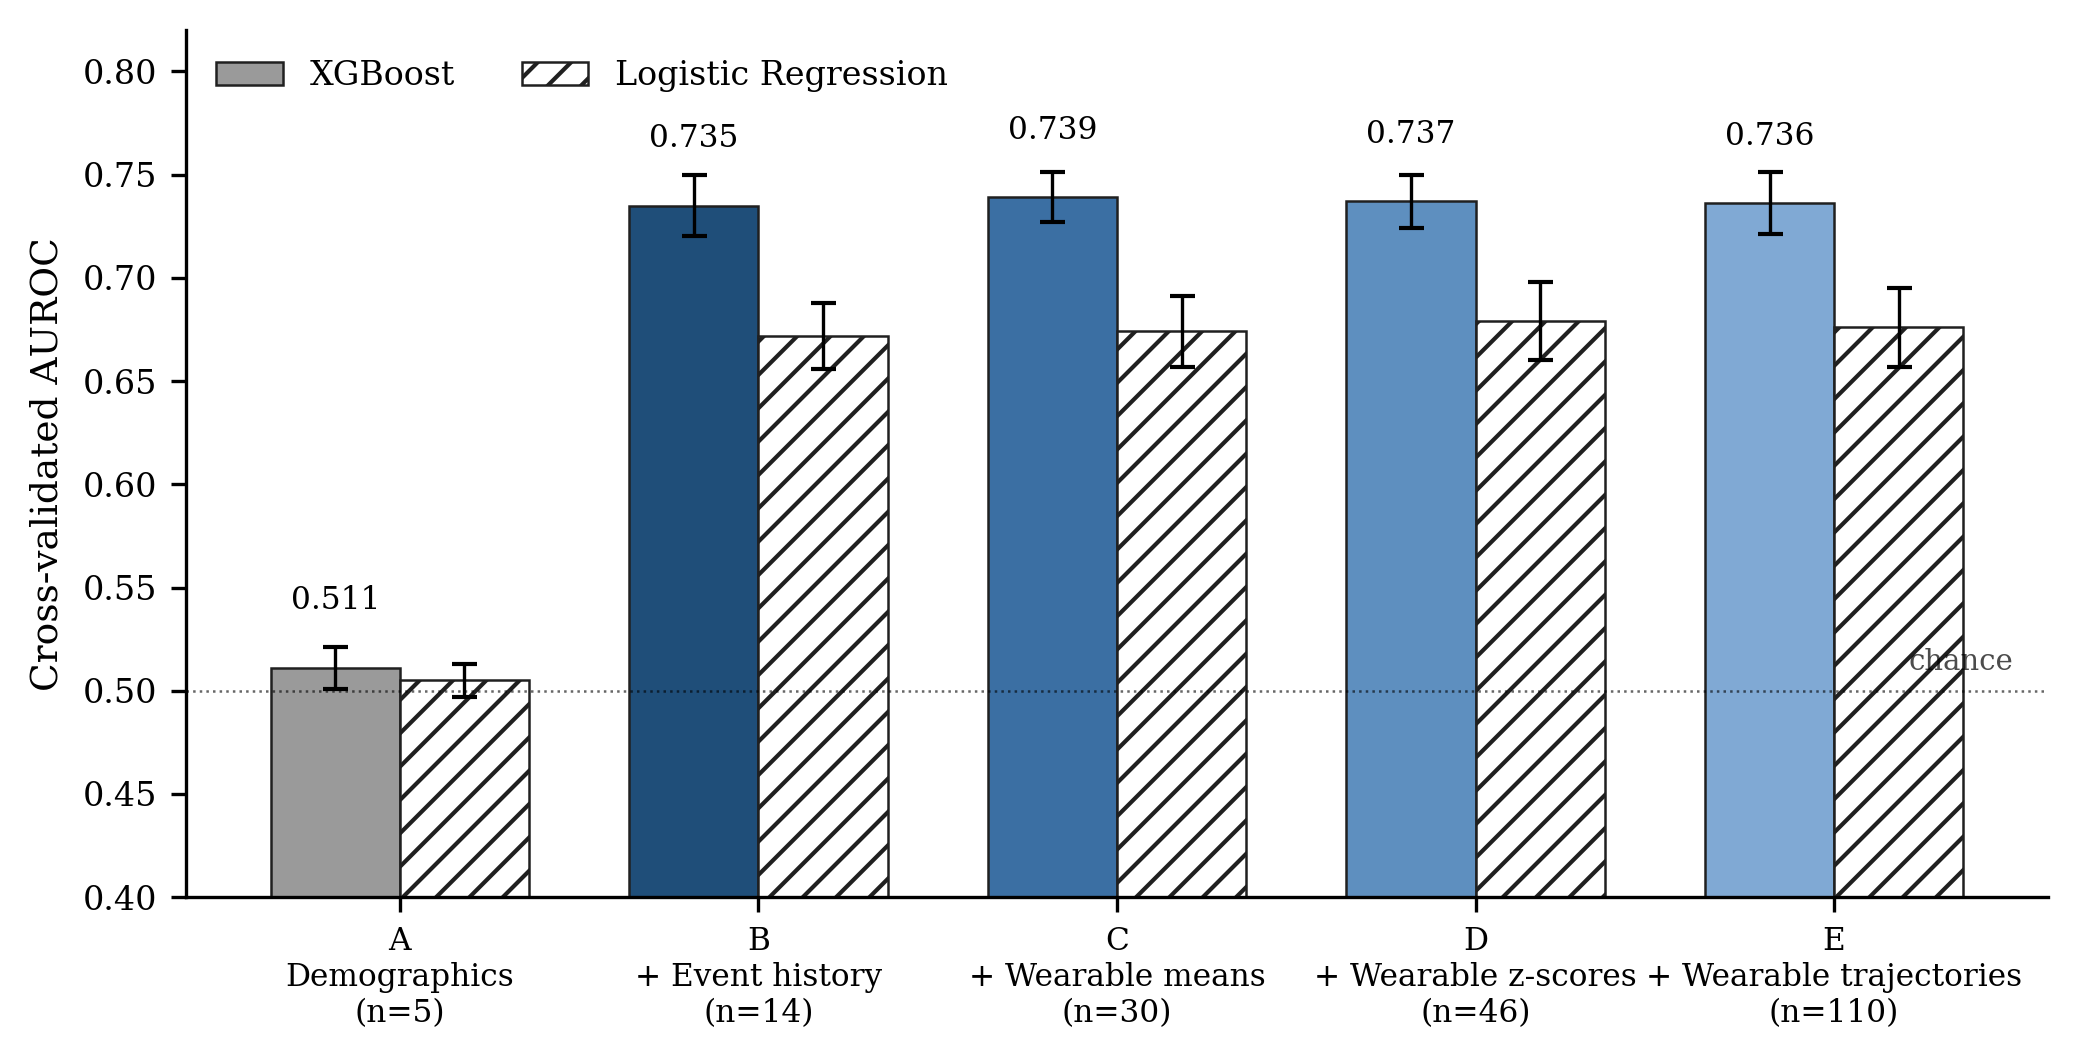

Saved Figure 3 (incremental AUROC)


In [2]:
# FIGURE 3 — Incremental AUROC (headline figure)

incremental_results = pd.DataFrame({
    'model': ['A', 'B', 'C', 'D', 'E'],
    'description': [
        'Demographics',
        '+ Event history',
        '+ Wearable means',
        '+ Wearable z-scores',
        '+ Wearable trajectories',
    ],
    'auroc_logistic':     [0.505, 0.672, 0.674, 0.679, 0.676],
    'auroc_logistic_std': [0.008, 0.016, 0.017, 0.019, 0.019],
    'auroc_xgboost':      [0.511, 0.735, 0.739, 0.737, 0.736],
    'auroc_xgboost_std':  [0.010, 0.015, 0.012, 0.013, 0.015],
    'n_features':         [5, 14, 30, 46, 110],
})

colors = ['#9a9a9a', '#1f4e79', '#3b6fa3', '#5e8fbf', '#80a9d4']
edge = '#202020'

fig, ax = plt.subplots(figsize=(7.0, 3.6))

x_positions = np.arange(len(incremental_results))
bar_width = 0.36

# XGBoost bars (primary)
ax.bar(x_positions - bar_width/2,
       incremental_results['auroc_xgboost'],
       width=bar_width,
       yerr=incremental_results['auroc_xgboost_std'],
       color=colors, edgecolor=edge, linewidth=0.6,
       capsize=3, error_kw={'elinewidth': 0.8},
       label='XGBoost')

# Logistic bars (secondary)
ax.bar(x_positions + bar_width/2,
       incremental_results['auroc_logistic'],
       width=bar_width,
       yerr=incremental_results['auroc_logistic_std'],
       color='white', edgecolor=edge, linewidth=0.6,
       hatch='///', capsize=3, error_kw={'elinewidth': 0.8},
       label='Logistic Regression')

# Annotate AUROC values above XGBoost bars
for i, v in enumerate(incremental_results['auroc_xgboost']):
    ax.text(x_positions[i] - bar_width/2, v + 0.025,
            f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)

# Delta arrows between consecutive XGBoost models
deltas = np.diff(incremental_results['auroc_xgboost'].values)
for i, d in enumerate(deltas):
    sign = '+' if d >= 0 else ''
    ax.annotate(f'Δ = {sign}{d:.3f}',
                xy=(x_positions[i+1] - bar_width/2, 0.05),
                ha='center', va='bottom', fontsize=7,
                color='#c0392b' if abs(d) < 0.01 else '#27ae60',
                fontweight='bold')

# Chance line
ax.axhline(0.5, color='black', linestyle=':', linewidth=0.6, alpha=0.6)
ax.text(len(x_positions) - 0.5, 0.51, 'chance', fontsize=7,
        color='black', alpha=0.7, ha='right')

ax.set_xticks(x_positions)
ax.set_xticklabels([f'{m}\n{d}\n(n={n})' for m, d, n in
                    zip(incremental_results['model'],
                        incremental_results['description'],
                        incremental_results['n_features'])],
                   fontsize=7.5)
ax.set_ylabel('Cross-validated AUROC')
ax.set_ylim(0.40, 0.82)
ax.set_yticks(np.arange(0.4, 0.85, 0.05))

ax.legend(loc='upper left', frameon=False, ncol=2)

plt.tight_layout()
plt.savefig('paper_figures/figure_3_incremental_auroc.png', dpi=300)
plt.savefig('paper_figures/figure_3_incremental_auroc.pdf')
plt.show()
print("Saved Figure 3 (incremental AUROC)")

In [7]:
import subprocess

# Replace with the actual bucket path you found in the UI
real_bucket = 'gs://REPLACE-WITH-REAL-BUCKET-PATH'

for fname in ['figure_3_incremental_auroc.png',
              'figure_3_incremental_auroc.pdf']:
    src = f'paper_figures/{fname}'
    dst = f'{real_bucket}/paper_figures/{fname}'
    result = subprocess.run(['gsutil', 'cp', src, dst],
                            capture_output=True, text=True)
    print(f"{fname}: rc={result.returncode}  {result.stderr.strip()}")

figure_3_incremental_auroc.png: rc=1  BucketNotFoundException: 404 gs://REPLACE-WITH-REAL-BUCKET-PATH bucket does not exist.
figure_3_incremental_auroc.pdf: rc=1  BucketNotFoundException: 404 gs://REPLACE-WITH-REAL-BUCKET-PATH bucket does not exist.


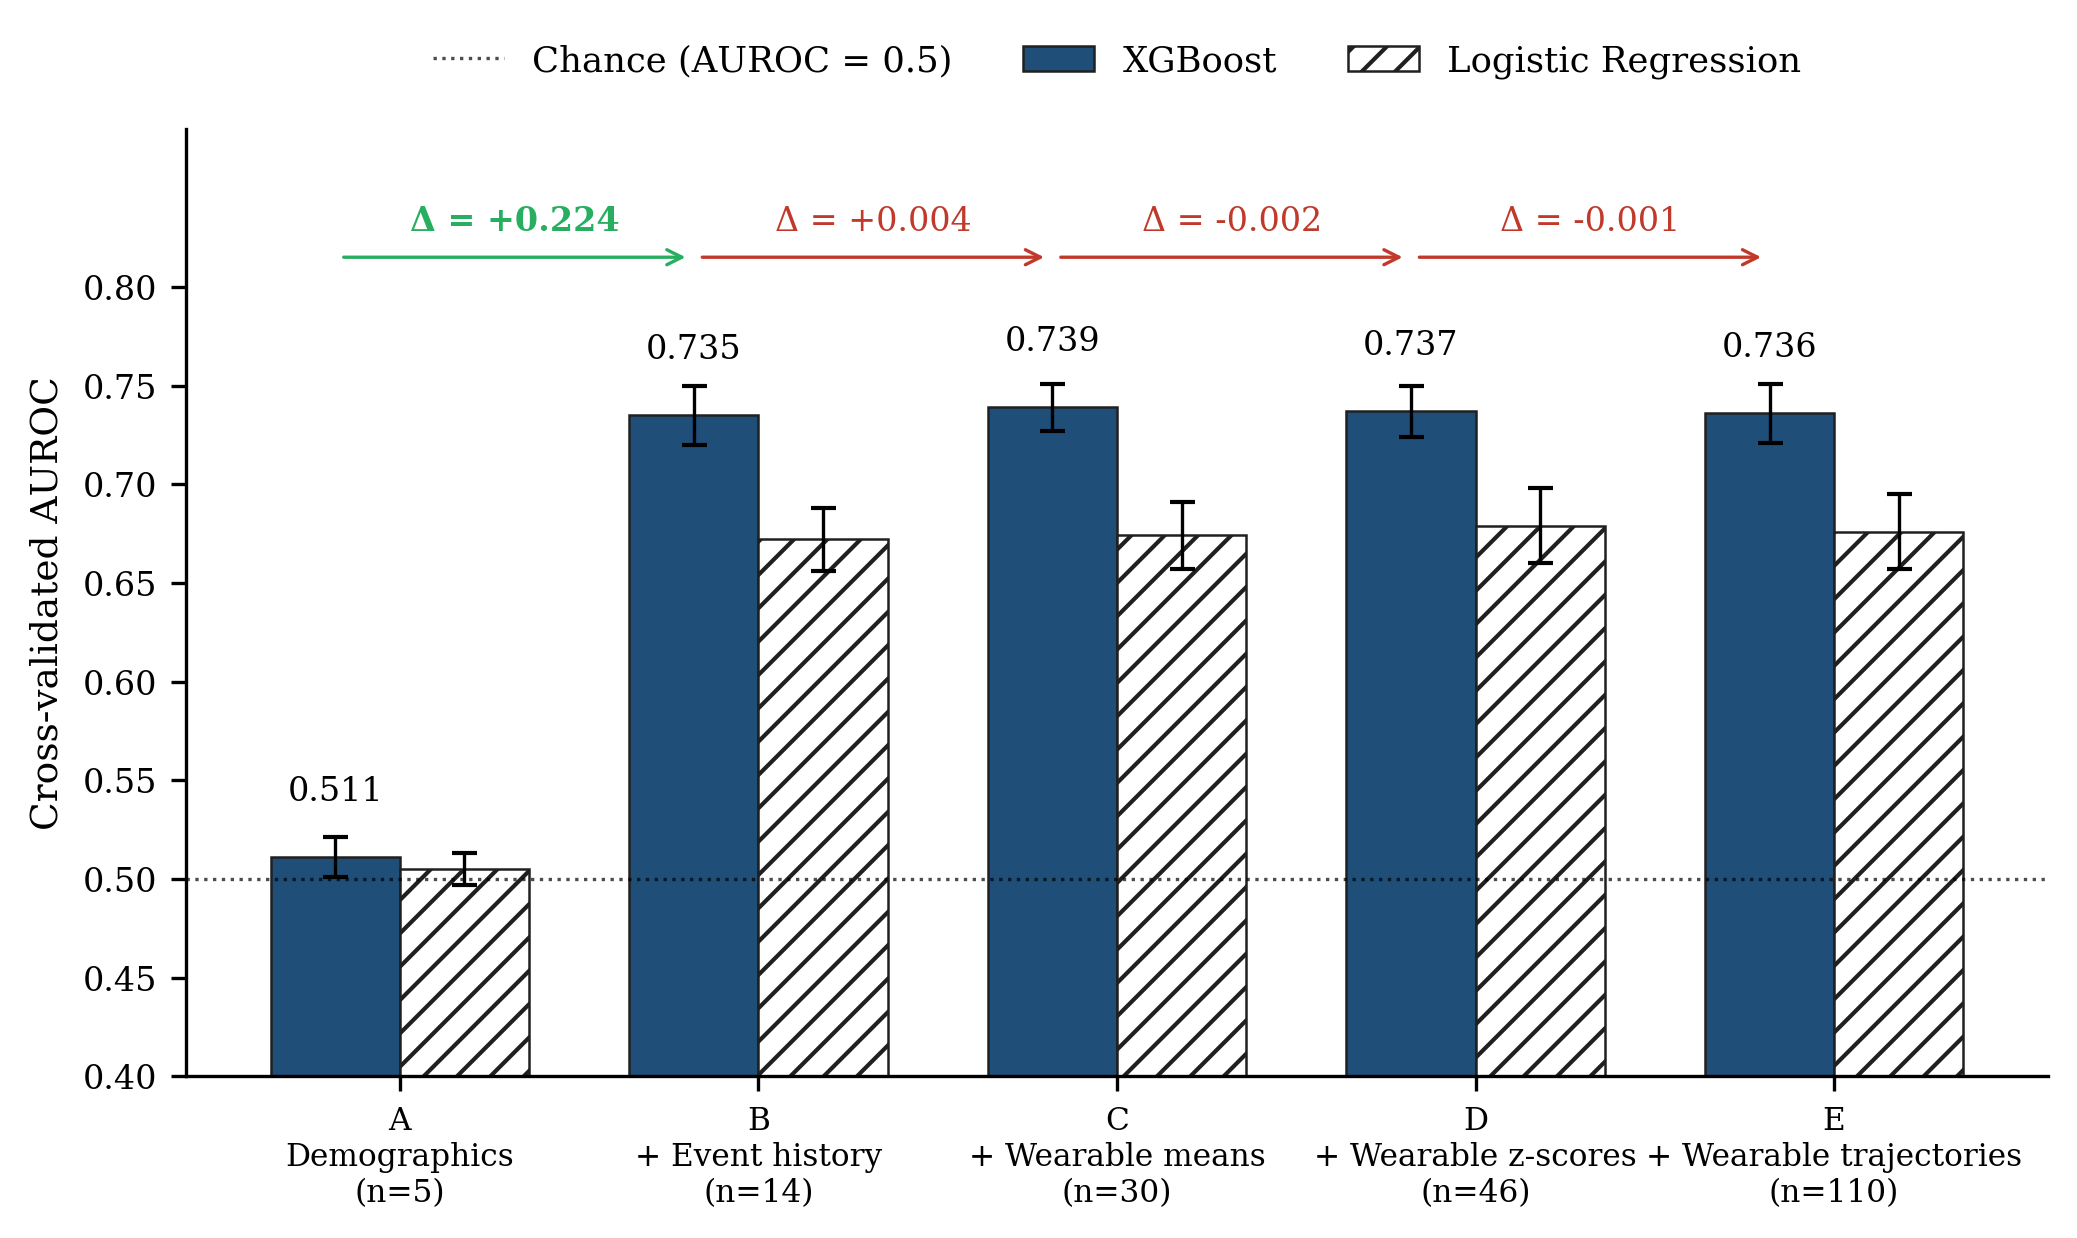

Saved Figure 3 v6 (chance in legend)


In [13]:
# FIGURE 3 v6 — chance line in legend

fig, ax = plt.subplots(figsize=(7.0, 4.2))

x_positions = np.arange(len(incremental_results))
bar_width = 0.36

ax.bar(x_positions - bar_width/2,
       incremental_results['auroc_xgboost'],
       width=bar_width,
       yerr=incremental_results['auroc_xgboost_std'],
       color='#1f4e79', edgecolor=edge, linewidth=0.6,
       capsize=3, error_kw={'elinewidth': 0.8},
       label='XGBoost')

ax.bar(x_positions + bar_width/2,
       incremental_results['auroc_logistic'],
       width=bar_width,
       yerr=incremental_results['auroc_logistic_std'],
       color='white', edgecolor=edge, linewidth=0.6,
       hatch='///', capsize=3, error_kw={'elinewidth': 0.8},
       label='Logistic Regression')

# AUROC value labels
for i, v in enumerate(incremental_results['auroc_xgboost']):
    ax.text(x_positions[i] - bar_width/2, v + 0.025,
            f'{v:.3f}', ha='center', va='bottom', fontsize=8)

# Delta arrows
deltas = np.diff(incremental_results['auroc_xgboost'].values)
arrow_y = 0.815
for i, d in enumerate(deltas):
    x_start = x_positions[i] - bar_width/2
    x_end   = x_positions[i+1] - bar_width/2
    x_mid   = (x_start + x_end) / 2

    ax.annotate('', xy=(x_end, arrow_y), xytext=(x_start, arrow_y),
                arrowprops=dict(arrowstyle='->', lw=0.8,
                                color='#27ae60' if abs(d) > 0.05 else '#c0392b'))
    sign = '+' if d >= 0 else ''
    color = '#27ae60' if abs(d) > 0.05 else '#c0392b'
    weight = 'bold' if abs(d) > 0.05 else 'normal'
    ax.text(x_mid, arrow_y + 0.010,
            f'Δ = {sign}{d:.3f}',
            ha='center', va='bottom', fontsize=8,
            color=color, fontweight=weight)

# Chance line WITH legend label (no floating text annotation)
ax.axhline(0.5, color='black', linestyle=':', linewidth=0.8, alpha=0.7,
           label='Chance (AUROC = 0.5)')

ax.set_xticks(x_positions)
ax.set_xticklabels([f'{m}\n{d}\n(n={n})' for m, d, n in
                    zip(incremental_results['model'],
                        incremental_results['description'],
                        incremental_results['n_features'])],
                   fontsize=7.5)
ax.set_ylabel('Cross-validated AUROC')
ax.set_ylim(0.40, 0.88)
ax.set_yticks(np.arange(0.4, 0.85, 0.05))

# Legend with all three entries on one row
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels,
          loc='lower center', bbox_to_anchor=(0.5, 1.02),
          ncol=3, frameon=False, fontsize=8.5)

plt.tight_layout()
plt.savefig('paper_figures/figure_3_incremental_auroc.png', dpi=300, bbox_inches='tight')
plt.savefig('paper_figures/figure_3_incremental_auroc.pdf', bbox_inches='tight')
plt.show()
print("Saved Figure 3 v6 (chance in legend)")

In [9]:
import os, glob

print("Current working directory:", os.getcwd())
print()
print("Does paper_figures/ exist as a directory?", os.path.isdir('paper_figures'))
print()
print("Contents of paper_figures/:")
for f in sorted(glob.glob('paper_figures/*')):
    size = os.path.getsize(f)
    mtime = os.path.getmtime(f)
    import datetime
    mtime_str = datetime.datetime.fromtimestamp(mtime).strftime('%H:%M:%S')
    print(f"  {f}  {size:,} bytes  modified {mtime_str}")
print()
print("All files in current directory matching 'figure*':")
for f in sorted(glob.glob('**/figure*', recursive=True)):
    size = os.path.getsize(f)
    print(f"  {f}  {size:,} bytes")

Current working directory: /home/jupyter

Does paper_figures/ exist as a directory? True

Contents of paper_figures/:
  paper_figures/figure_3_incremental_auroc.pdf  24,928 bytes  modified 18:40:34
  paper_figures/figure_3_incremental_auroc.png  142,367 bytes  modified 18:40:34

All files in current directory matching 'figure*':
  paper_figures/figure_3_incremental_auroc.pdf  24,928 bytes
  paper_figures/figure_3_incremental_auroc.png  142,367 bytes


In [2]:
import os, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Reload AoU environment
result = subprocess.run(['bash', '-c', 'source ~/load-env.sh && env'],
                        capture_output=True, text=True)
for line in result.stdout.split('\n'):
    if '=' in line:
        key, _, value = line.partition('=')
        if any(k in key.upper() for k in ['CDR', 'WORKSPACE', 'GOOGLE_PROJECT', 'AOU', 'BUCKET']):
            os.environ[key] = value

# Reload CSVs
analytic_df = pd.read_csv('analytic_cohort.csv')
hormonal    = pd.read_csv('hormonal_status.csv')
effect_df   = pd.read_csv('effect_sizes_categorized.csv')
subgroup_df = pd.read_csv('subgroup_results.csv')

# Re-hardcode the incremental results (we never saved this to CSV)
incremental_results = pd.DataFrame({
    'model': ['A', 'B', 'C', 'D', 'E'],
    'description': [
        'Demographics',
        '+ Event history',
        '+ Wearable means',
        '+ Wearable z-scores',
        '+ Wearable trajectories',
    ],
    'auroc_logistic':     [0.505, 0.672, 0.674, 0.679, 0.676],
    'auroc_logistic_std': [0.008, 0.016, 0.017, 0.019, 0.019],
    'auroc_xgboost':      [0.511, 0.735, 0.739, 0.737, 0.736],
    'auroc_xgboost_std':  [0.010, 0.015, 0.012, 0.013, 0.015],
    'n_features':         [5, 14, 30, 46, 110],
})

# IEEE-style figure settings
plt.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size':         9,
    'axes.titlesize':    10,
    'axes.labelsize':    9,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'legend.fontsize':   8,
    'figure.dpi':        300,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

edge = '#202020'

os.makedirs('paper_figures', exist_ok=True)

print(f"Reloaded:")
print(f"  Cohort:         {len(analytic_df)} patients")
print(f"  Effect sizes:   {len(effect_df)} features")
print(f"  Subgroups:      {len(subgroup_df)} subgroup analyses")
print(f"  Incremental:    {len(incremental_results)} nested models")

Reloaded:
  Cohort:         1700 patients
  Effect sizes:   32 features
  Subgroups:      10 subgroup analyses
  Incremental:    5 nested models


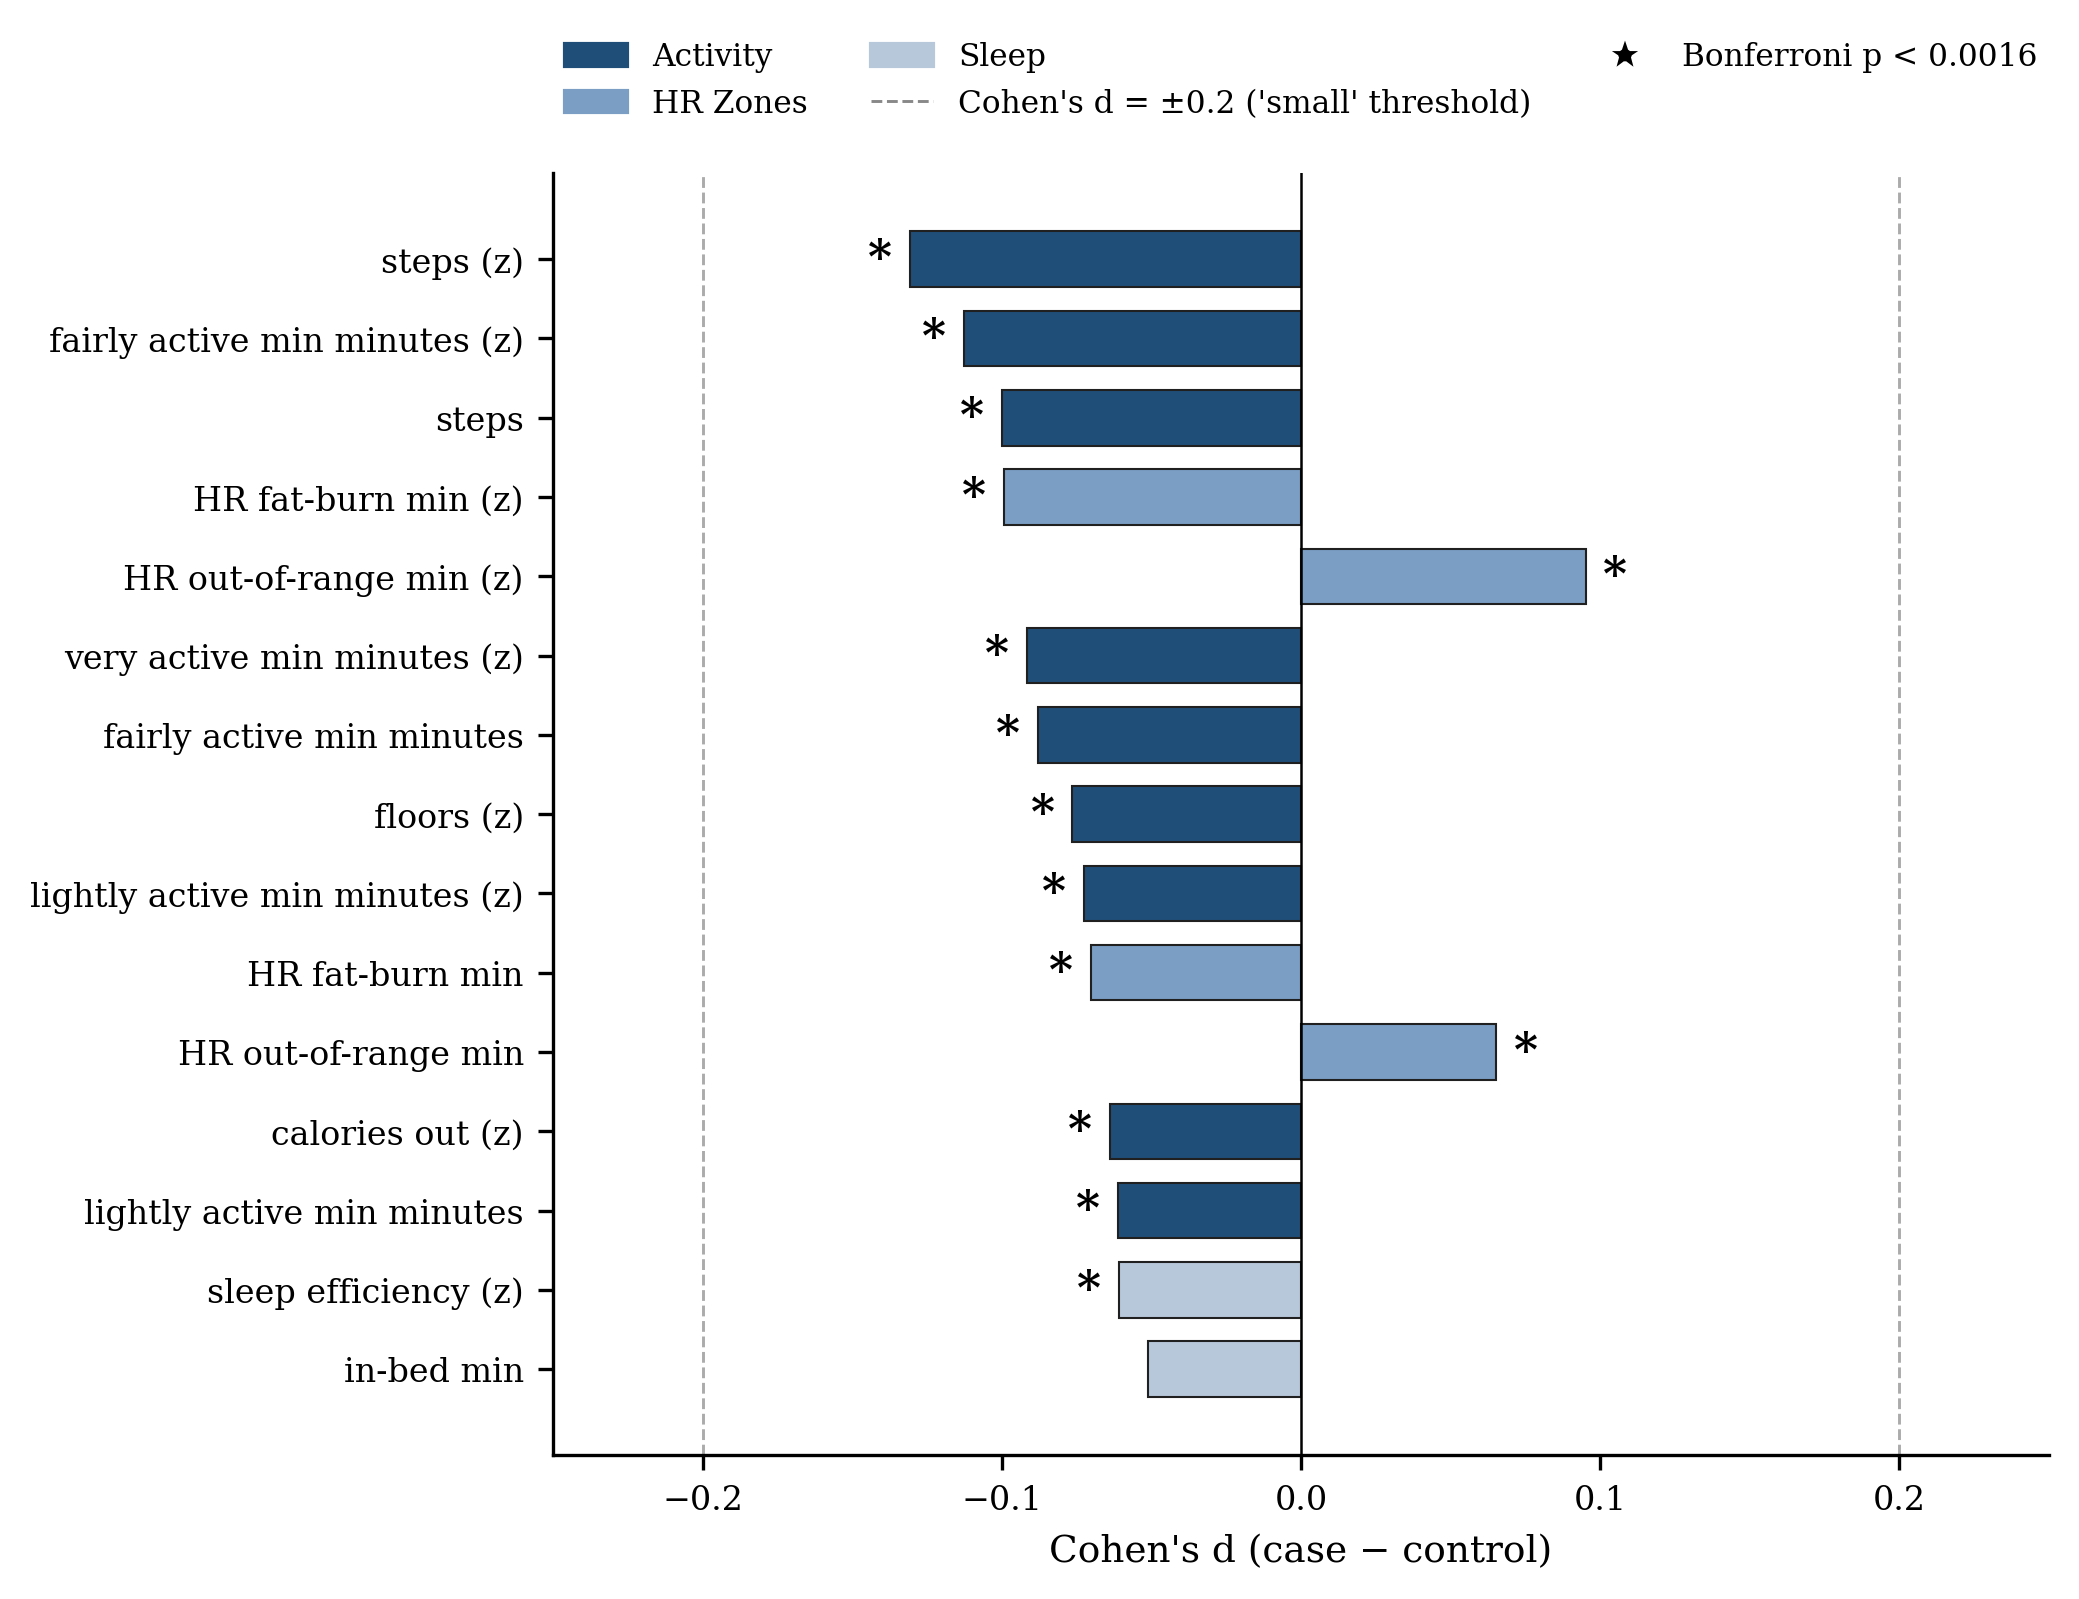

Saved Figure 2 (effect-size forest plot, clean legend)


In [3]:
# FIGURE 2 — Effect-size forest plot, modality-grouped, with clean legend

top15 = effect_df.nlargest(15, 'abs_cohen_d').copy()

def pretty_name(s):
    s = s.replace('_zscore', ' (z)').replace('_mean', '')
    s = s.replace('_', ' ')
    s = s.replace('lightly active', 'lightly active min')
    s = s.replace('fairly active', 'fairly active min')
    s = s.replace('very active', 'very active min')
    s = s.replace('minutes out of range', 'HR out-of-range min')
    s = s.replace('minutes fat burn', 'HR fat-burn min')
    s = s.replace('minutes cardio', 'HR cardio min')
    s = s.replace('minutes peak', 'HR peak min')
    s = s.replace('total calories burned', 'total cal. burned')
    s = s.replace('asleep minutes', 'asleep min')
    s = s.replace('awake minutes', 'awake min')
    s = s.replace('in bed minutes', 'in-bed min')
    return s

top15['label'] = top15['feature'].apply(pretty_name)
top15 = top15.iloc[::-1].reset_index(drop=True)

modality_colors = {
    'Activity':         '#1f4e79',
    'Heart Rate Zones': '#7a9ec4',
    'Sleep':            '#b8c8db',
}

fig, ax = plt.subplots(figsize=(7.0, 5.4))

y_positions = np.arange(len(top15))
bar_colors  = [modality_colors[m] for m in top15['modality']]

ax.barh(y_positions, top15['cohen_d'],
        color=bar_colors, edgecolor='#202020', linewidth=0.5, height=0.7)

# Bonferroni asterisks
for i, row in top15.iterrows():
    if row['bonferroni_sig']:
        offset = 0.006 if row['cohen_d'] > 0 else -0.006
        ha = 'left' if row['cohen_d'] > 0 else 'right'
        ax.text(row['cohen_d'] + offset, y_positions[i],
                '*', ha=ha, va='center', fontsize=11, fontweight='bold')

# Reference lines
ax.axvline(0, color='black', linewidth=0.6)
ax.axvline(-0.2, color='#888', linestyle='--', linewidth=0.7, alpha=0.7)
ax.axvline(0.2,  color='#888', linestyle='--', linewidth=0.7, alpha=0.7)

ax.set_yticks(y_positions)
ax.set_yticklabels(top15['label'], fontsize=8)
ax.set_xlabel("Cohen's d (case − control)")
ax.set_xlim(-0.25, 0.25)

# Legend ABOVE plot, all visual conventions in one row
legend_handles = [
    mpatches.Patch(color=modality_colors['Activity'],         label='Activity'),
    mpatches.Patch(color=modality_colors['Heart Rate Zones'], label='HR Zones'),
    mpatches.Patch(color=modality_colors['Sleep'],            label='Sleep'),
    Line2D([0], [0], color='#888', linestyle='--', linewidth=0.7,
           label="Cohen's d = ±0.2 ('small' threshold)"),
    Line2D([0], [0], marker='*', color='w',
           markerfacecolor='black', markersize=10,
           label='Bonferroni p < 0.0016'),
]
ax.legend(handles=legend_handles,
          loc='lower center', bbox_to_anchor=(0.5, 1.02),
          ncol=3, frameon=False, fontsize=7.5)

plt.tight_layout()
plt.savefig('paper_figures/figure_2_effect_sizes.png', dpi=300, bbox_inches='tight')
plt.savefig('paper_figures/figure_2_effect_sizes.pdf', bbox_inches='tight')
plt.show()
print("Saved Figure 2 (effect-size forest plot, clean legend)")

In [4]:
# Fix modality categorization with a cleaner function
def categorize_feature(feat):
    f = feat.lower()
    # Activity features (check first — most specific patterns)
    if any(k in f for k in ['steps', 'sedentary', 'lightly_active',
                            'fairly_active', 'very_active', 'calories_out',
                            'floors']):
        return 'Activity'
    # HR zone features
    if any(k in f for k in ['out_of_range', 'fat_burn', 'cardio',
                            'peak', 'total_calories_burned']):
        return 'Heart Rate Zones'
    # Sleep features
    if any(k in f for k in ['in_bed', 'asleep', 'awake', 'sleep_efficiency']):
        return 'Sleep'
    return 'Other'

# Re-categorize from scratch (overwrite the modality column)
effect_df['modality'] = effect_df['feature'].apply(categorize_feature)

# Print summary to verify
print("Modality counts after re-categorization:")
print(effect_df['modality'].value_counts())
print()
print("Sample of each modality:")
for m in ['Activity', 'Heart Rate Zones', 'Sleep']:
    print(f"\n{m}:")
    for f in effect_df[effect_df['modality']==m]['feature'].tolist():
        print(f"  {f}")

Modality counts after re-categorization:
modality
Activity            14
Heart Rate Zones    10
Sleep                8
Name: count, dtype: int64

Sample of each modality:

Activity:
  steps_zscore
  fairly_active_minutes_zscore
  steps_mean
  very_active_minutes_zscore
  fairly_active_minutes_mean
  floors_zscore
  lightly_active_minutes_zscore
  calories_out_zscore
  lightly_active_minutes_mean
  very_active_minutes_mean
  floors_mean
  sedentary_minutes_mean
  calories_out_mean
  sedentary_minutes_zscore

Heart Rate Zones:
  minutes_fat_burn_zscore
  minutes_out_of_range_zscore
  minutes_fat_burn_mean
  minutes_out_of_range_mean
  minutes_cardio_zscore
  total_calories_burned_zscore
  minutes_peak_zscore
  minutes_cardio_mean
  minutes_peak_mean
  total_calories_burned_mean

Sleep:
  sleep_efficiency_zscore
  in_bed_minutes_mean
  awake_minutes_zscore
  asleep_minutes_zscore
  in_bed_minutes_zscore
  asleep_minutes_mean
  sleep_efficiency_mean
  awake_minutes_mean


In [5]:
import re

def pretty_name(feat):
    """Convert raw feature name to clean display label."""
    s = feat
    
    # Track if this is a z-score
    is_z = '_zscore' in s
    s = s.replace('_zscore', '').replace('_mean', '')
    
    # Clean substitutions in a fixed order — most specific first
    replacements = [
        ('minutes_out_of_range',     'HR out-of-range min'),
        ('minutes_fat_burn',         'HR fat-burn min'),
        ('minutes_cardio',           'HR cardio min'),
        ('minutes_peak',             'HR peak min'),
        ('total_calories_burned',    'total cal. burned'),
        ('lightly_active_minutes',   'lightly active min'),
        ('fairly_active_minutes',    'fairly active min'),
        ('very_active_minutes',      'very active min'),
        ('sedentary_minutes',        'sedentary min'),
        ('calories_out',             'calories out'),
        ('in_bed_minutes',           'in-bed min'),
        ('asleep_minutes',           'asleep min'),
        ('awake_minutes',            'awake min'),
        ('sleep_efficiency',         'sleep efficiency'),
        ('floors',                   'floors'),
        ('steps',                    'steps'),
    ]
    
    for old, new in replacements:
        if old in s:
            s = new
            break
    
    if is_z:
        s = s + ' (z)'
    
    return s

# Test the labels
print("Label preview:")
for f in effect_df.nlargest(15, 'abs_cohen_d')['feature']:
    print(f"  {f:<45} -> {pretty_name(f)}")

Label preview:
  steps_zscore                                  -> steps (z)
  fairly_active_minutes_zscore                  -> fairly active min (z)
  steps_mean                                    -> steps
  minutes_fat_burn_zscore                       -> HR fat-burn min (z)
  minutes_out_of_range_zscore                   -> HR out-of-range min (z)
  very_active_minutes_zscore                    -> very active min (z)
  fairly_active_minutes_mean                    -> fairly active min
  floors_zscore                                 -> floors (z)
  lightly_active_minutes_zscore                 -> lightly active min (z)
  minutes_fat_burn_mean                         -> HR fat-burn min
  minutes_out_of_range_mean                     -> HR out-of-range min
  calories_out_zscore                           -> calories out (z)
  lightly_active_minutes_mean                   -> lightly active min
  sleep_efficiency_zscore                       -> sleep efficiency (z)
  in_bed_minutes_mean   

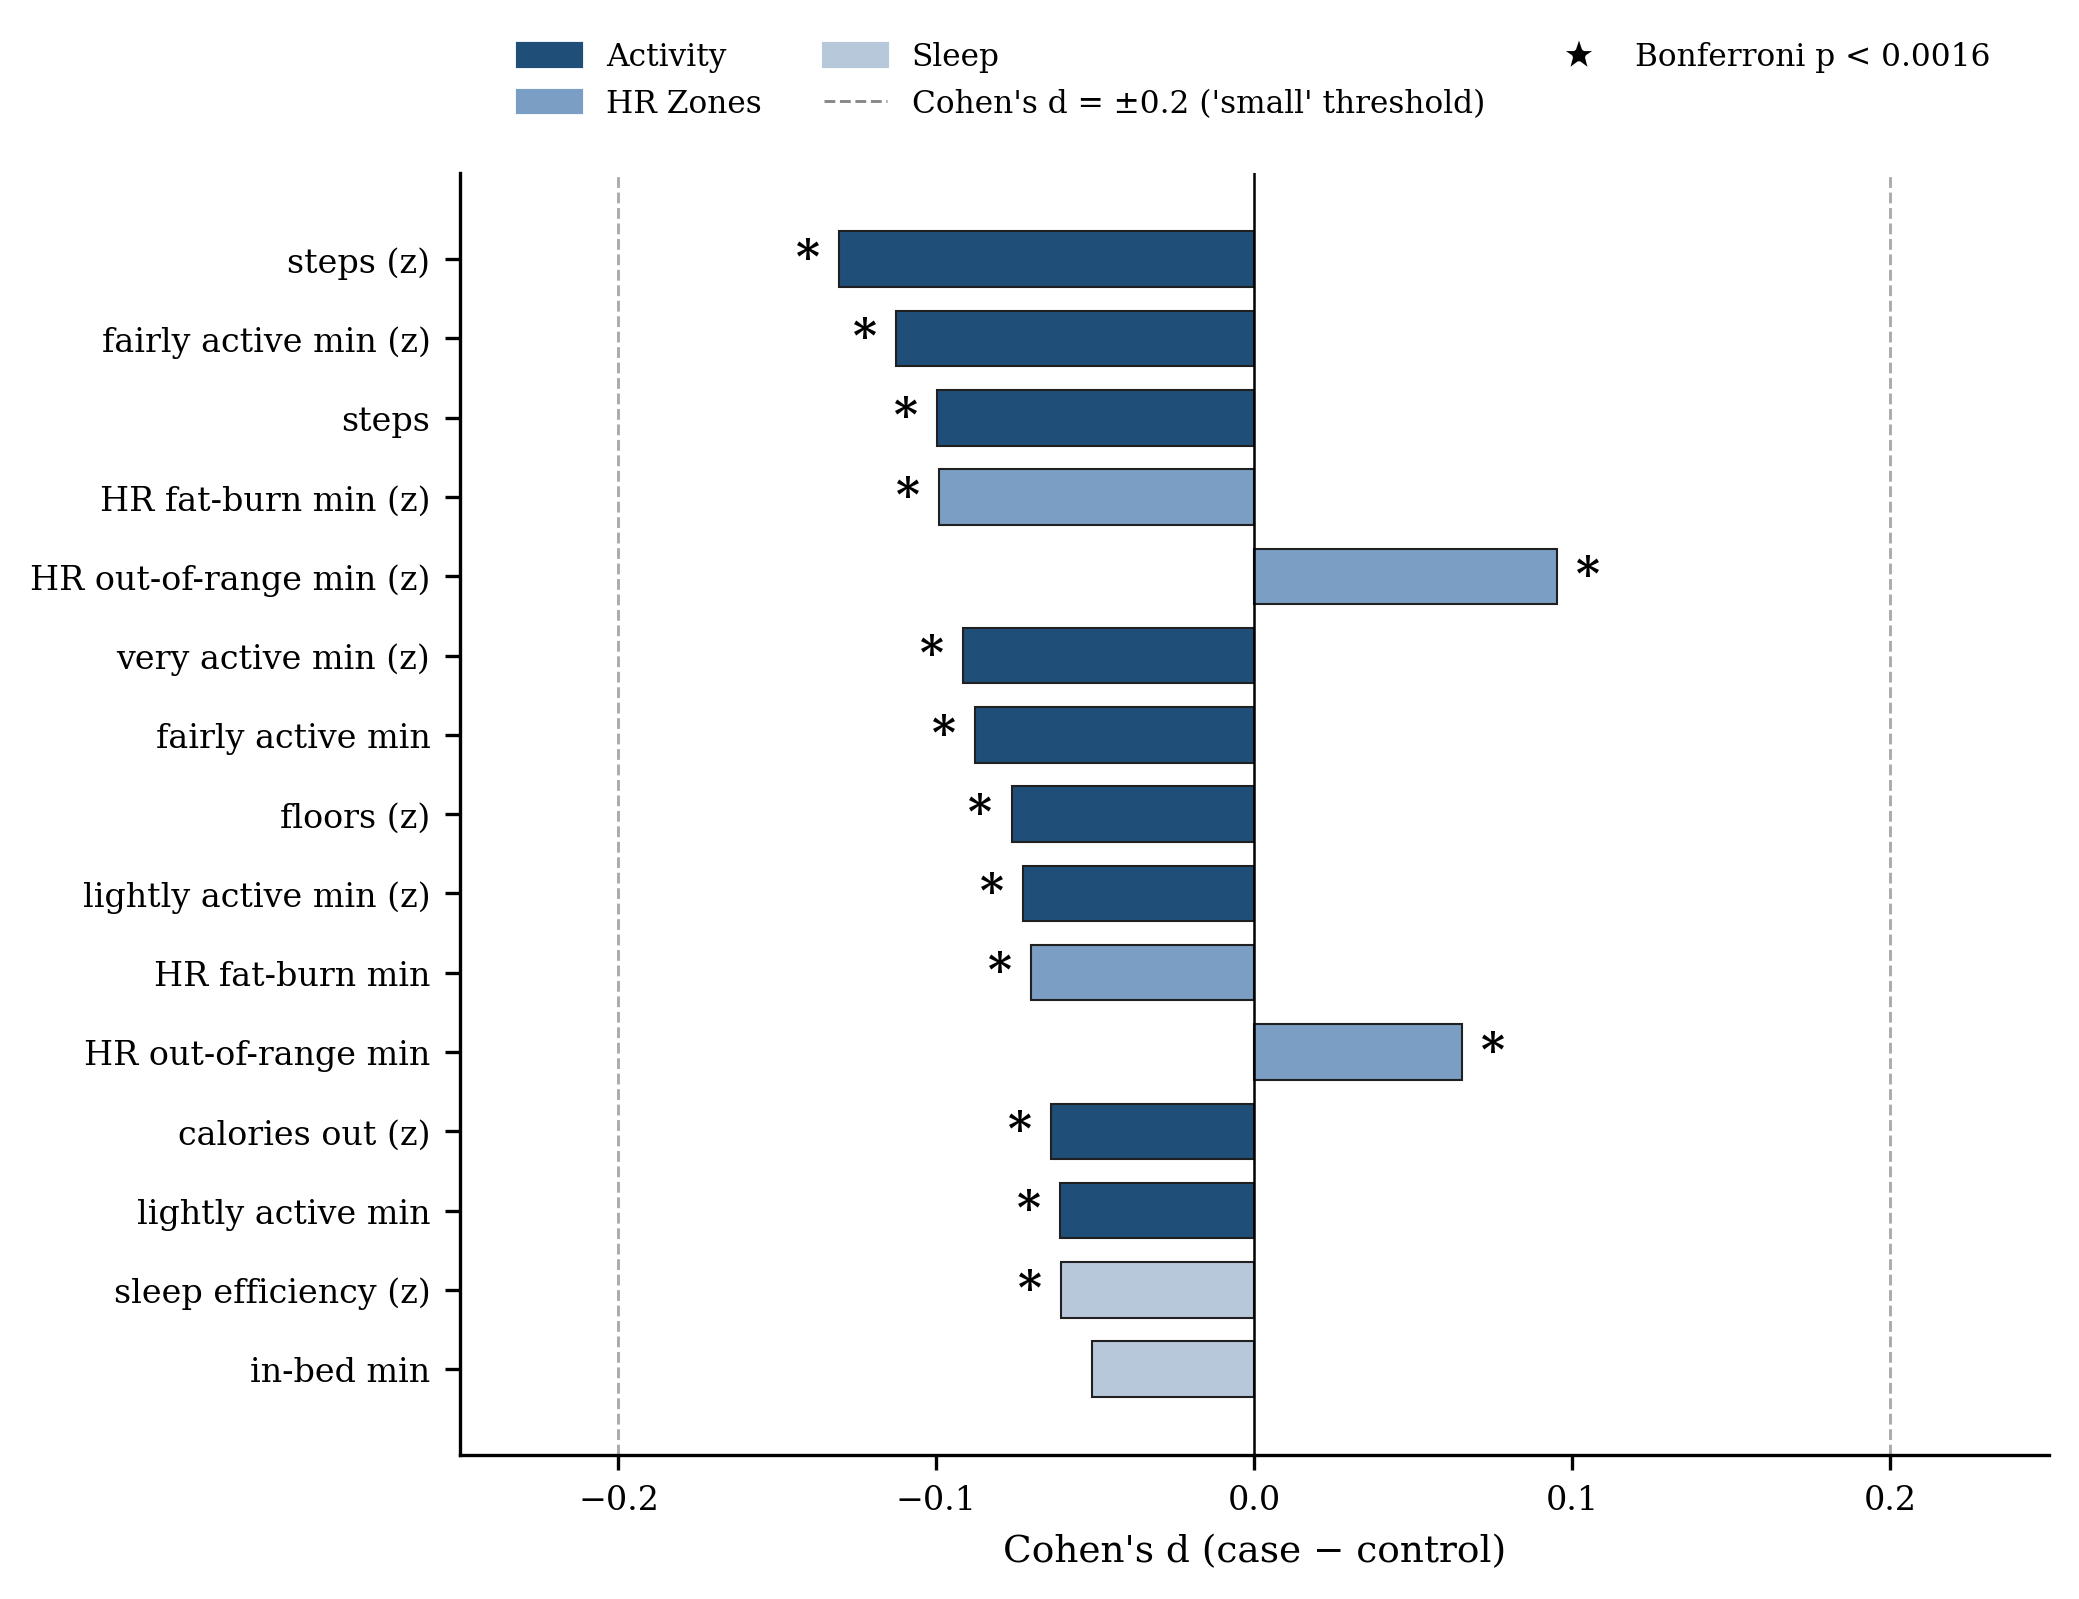

Saved Figure 2 v2 (corrected categorization and labels)


In [6]:
# FIGURE 2 v2 — corrected categorization and labels

top15 = effect_df.nlargest(15, 'abs_cohen_d').copy()
top15['label'] = top15['feature'].apply(pretty_name)
top15 = top15.iloc[::-1].reset_index(drop=True)  # largest at top

modality_colors = {
    'Activity':         '#1f4e79',
    'Heart Rate Zones': '#7a9ec4',
    'Sleep':            '#b8c8db',
}

fig, ax = plt.subplots(figsize=(7.0, 5.4))

y_positions = np.arange(len(top15))
bar_colors  = [modality_colors[m] for m in top15['modality']]

ax.barh(y_positions, top15['cohen_d'],
        color=bar_colors, edgecolor='#202020', linewidth=0.5, height=0.7)

# Bonferroni asterisks
for i, row in top15.iterrows():
    if row['bonferroni_sig']:
        offset = 0.006 if row['cohen_d'] > 0 else -0.006
        ha = 'left' if row['cohen_d'] > 0 else 'right'
        ax.text(row['cohen_d'] + offset, y_positions[i],
                '*', ha=ha, va='center', fontsize=11, fontweight='bold')

# Reference lines
ax.axvline(0, color='black', linewidth=0.6)
ax.axvline(-0.2, color='#888', linestyle='--', linewidth=0.7, alpha=0.7)
ax.axvline(0.2,  color='#888', linestyle='--', linewidth=0.7, alpha=0.7)

ax.set_yticks(y_positions)
ax.set_yticklabels(top15['label'], fontsize=8)
ax.set_xlabel("Cohen's d (case − control)")
ax.set_xlim(-0.25, 0.25)

# Legend above plot with all 5 conventions
legend_handles = [
    mpatches.Patch(color=modality_colors['Activity'],         label='Activity'),
    mpatches.Patch(color=modality_colors['Heart Rate Zones'], label='HR Zones'),
    mpatches.Patch(color=modality_colors['Sleep'],            label='Sleep'),
    Line2D([0], [0], color='#888', linestyle='--', linewidth=0.7,
           label="Cohen's d = ±0.2 ('small' threshold)"),
    Line2D([0], [0], marker='*', color='w',
           markerfacecolor='black', markersize=10,
           label='Bonferroni p < 0.0016'),
]
ax.legend(handles=legend_handles,
          loc='lower center', bbox_to_anchor=(0.5, 1.02),
          ncol=3, frameon=False, fontsize=7.5)

plt.tight_layout()
plt.savefig('paper_figures/figure_2_effect_sizes.png', dpi=300, bbox_inches='tight')
plt.savefig('paper_figures/figure_2_effect_sizes.pdf', bbox_inches='tight')
plt.show()
print("Saved Figure 2 v2 (corrected categorization and labels)")

In [7]:
# Diagnostic: trace exactly which color each top-15 row will get
top15 = effect_df.nlargest(15, 'abs_cohen_d').copy()
top15['label'] = top15['feature'].apply(pretty_name)
top15 = top15.iloc[::-1].reset_index(drop=True)

print(f"{'Feature':<32} {'Modality':<20} {'Color'}")
print('-' * 70)
for _, row in top15.iterrows():
    color = modality_colors.get(row['modality'], 'MISSING')
    color_name = {'#1f4e79': 'dark (Activity)',
                  '#7a9ec4': 'mid (HR Zones)',
                  '#b8c8db': 'light (Sleep)'}.get(color, color)
    print(f"{row['feature']:<32} {row['modality']:<20} {color_name}")

Feature                          Modality             Color
----------------------------------------------------------------------
in_bed_minutes_mean              Sleep                light (Sleep)
sleep_efficiency_zscore          Sleep                light (Sleep)
lightly_active_minutes_mean      Activity             dark (Activity)
calories_out_zscore              Activity             dark (Activity)
minutes_out_of_range_mean        Heart Rate Zones     mid (HR Zones)
minutes_fat_burn_mean            Heart Rate Zones     mid (HR Zones)
lightly_active_minutes_zscore    Activity             dark (Activity)
floors_zscore                    Activity             dark (Activity)
fairly_active_minutes_mean       Activity             dark (Activity)
very_active_minutes_zscore       Activity             dark (Activity)
minutes_out_of_range_zscore      Heart Rate Zones     mid (HR Zones)
minutes_fat_burn_zscore          Heart Rate Zones     mid (HR Zones)
steps_mean                       Acti

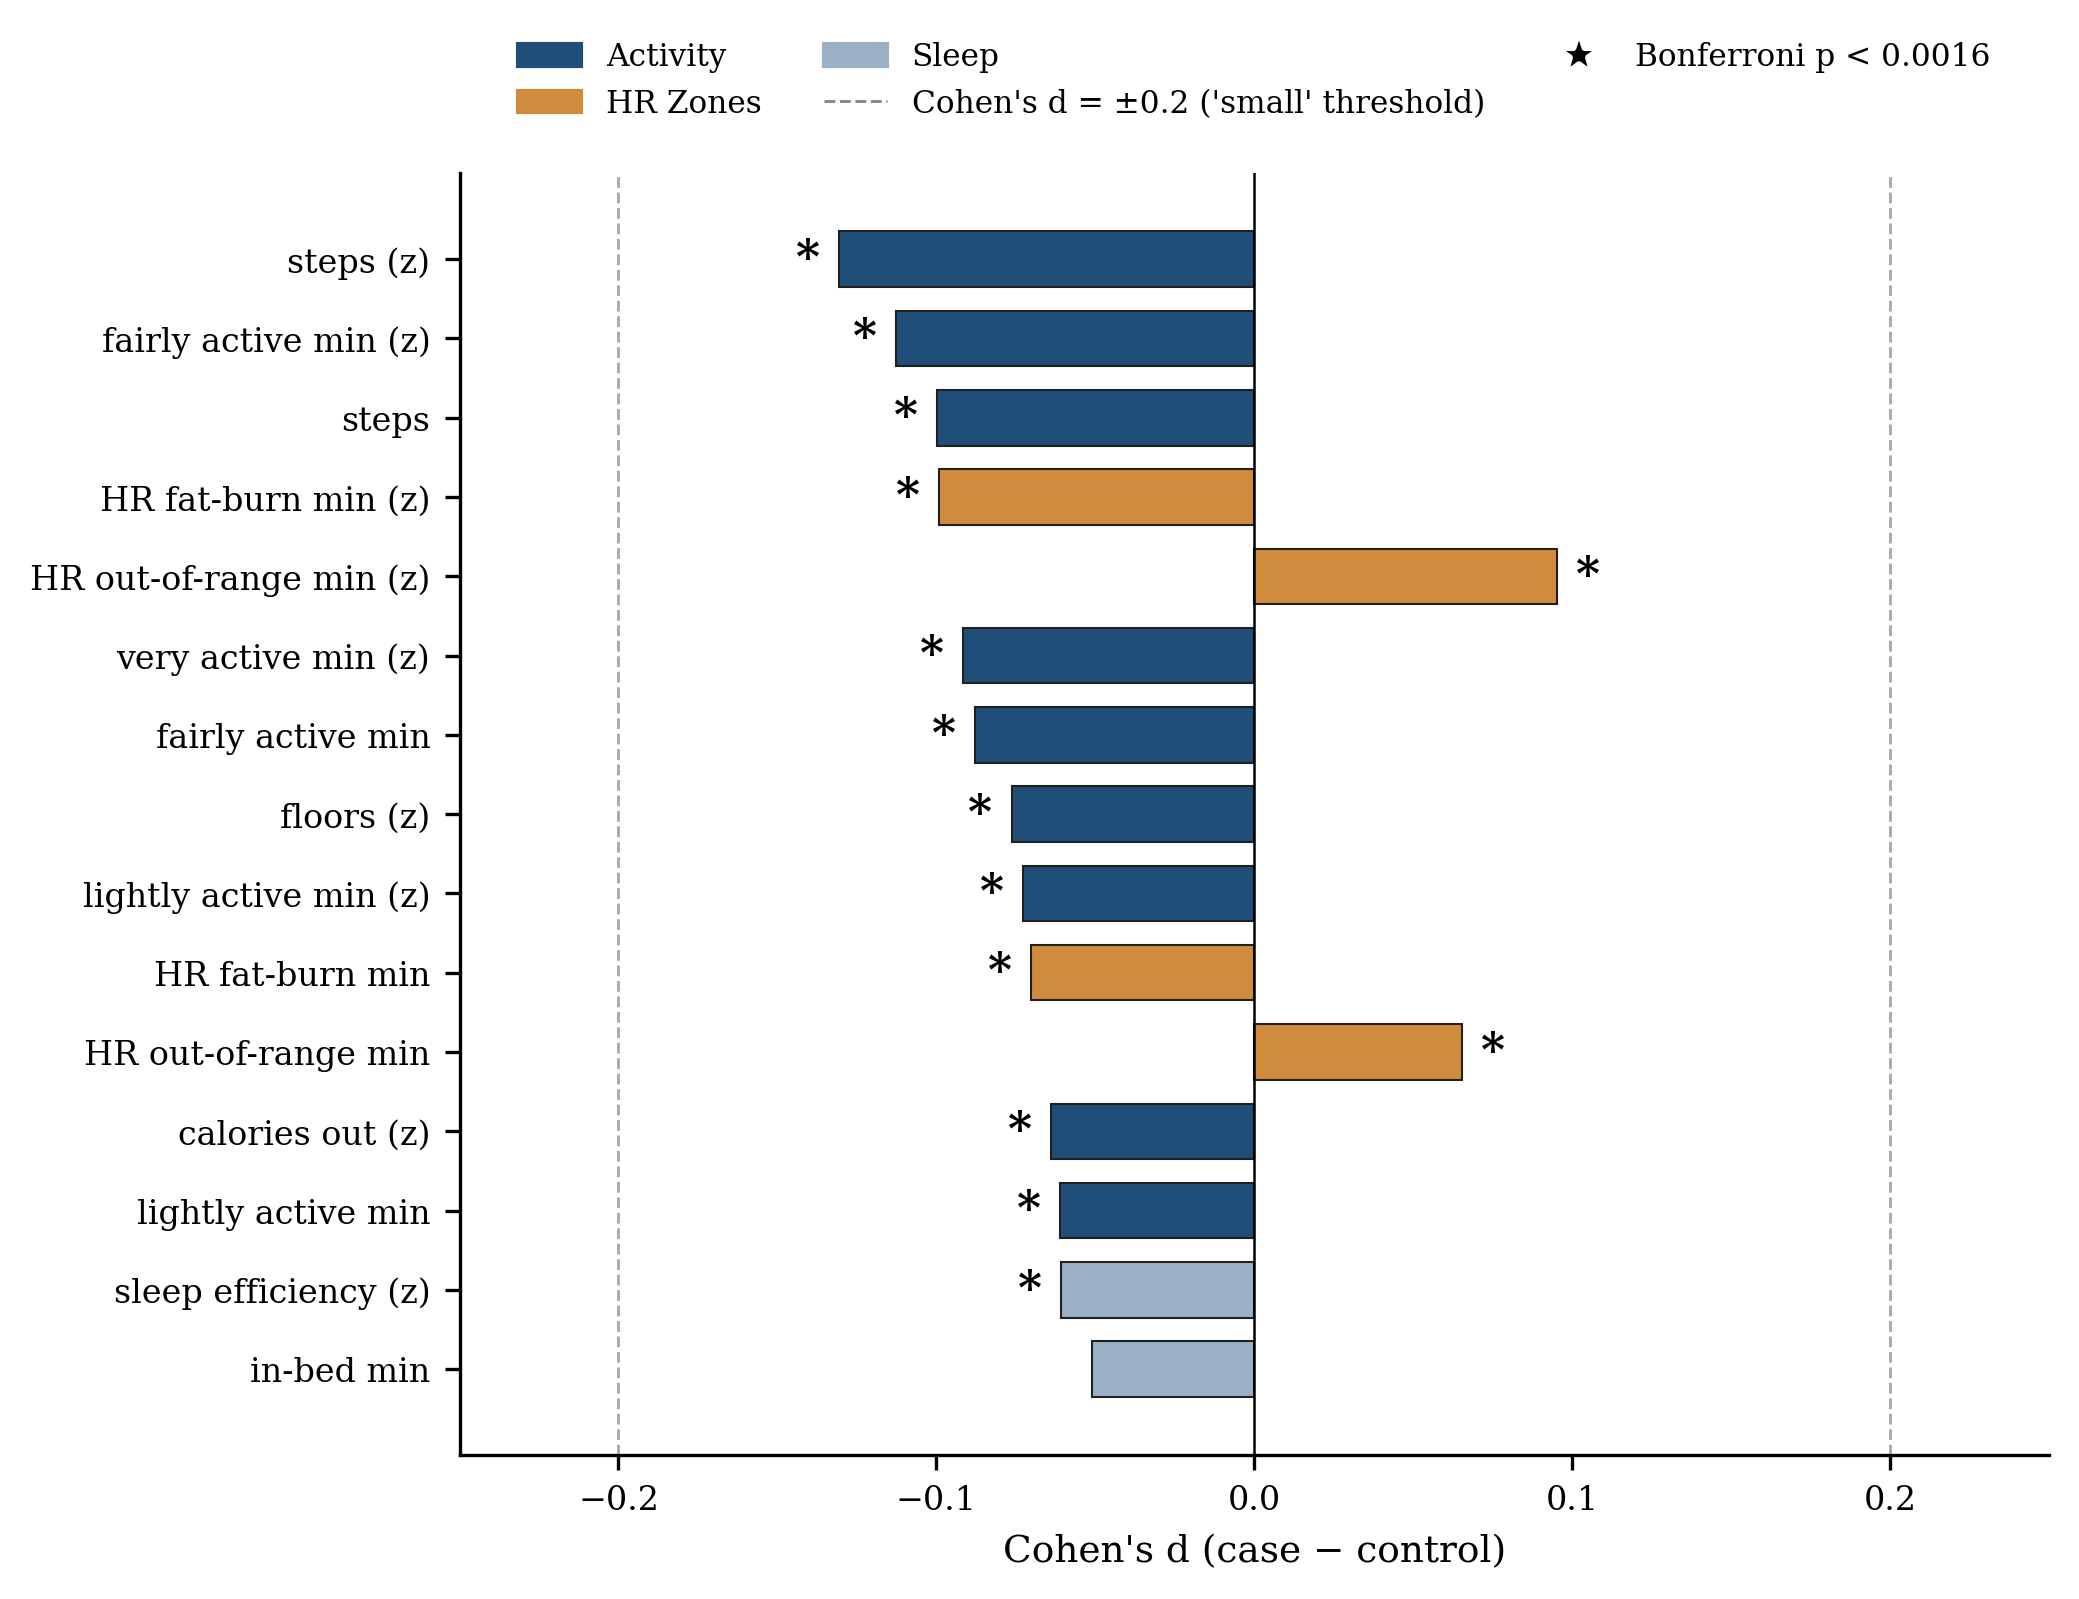

Saved Figure 2 v3 (distinguishable modality colors)


In [8]:
# FIGURE 2 v3 — distinguishable modality colors

# New palette: dark blue / amber / light gray-blue
modality_colors = {
    'Activity':         '#1f4e79',   # dark blue
    'Heart Rate Zones': '#d08c3c',   # amber/warm
    'Sleep':            '#9ab0c4',   # gray-blue (cool, clearly different from amber)
}

top15 = effect_df.nlargest(15, 'abs_cohen_d').copy()
top15['label'] = top15['feature'].apply(pretty_name)
top15 = top15.iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7.0, 5.4))

y_positions = np.arange(len(top15))
bar_colors  = [modality_colors[m] for m in top15['modality']]

ax.barh(y_positions, top15['cohen_d'],
        color=bar_colors, edgecolor='#202020', linewidth=0.5, height=0.7)

# Bonferroni asterisks
for i, row in top15.iterrows():
    if row['bonferroni_sig']:
        offset = 0.006 if row['cohen_d'] > 0 else -0.006
        ha = 'left' if row['cohen_d'] > 0 else 'right'
        ax.text(row['cohen_d'] + offset, y_positions[i],
                '*', ha=ha, va='center', fontsize=11, fontweight='bold')

# Reference lines
ax.axvline(0, color='black', linewidth=0.6)
ax.axvline(-0.2, color='#888', linestyle='--', linewidth=0.7, alpha=0.7)
ax.axvline(0.2,  color='#888', linestyle='--', linewidth=0.7, alpha=0.7)

ax.set_yticks(y_positions)
ax.set_yticklabels(top15['label'], fontsize=8)
ax.set_xlabel("Cohen's d (case − control)")
ax.set_xlim(-0.25, 0.25)

# Legend above plot
legend_handles = [
    mpatches.Patch(color=modality_colors['Activity'],         label='Activity'),
    mpatches.Patch(color=modality_colors['Heart Rate Zones'], label='HR Zones'),
    mpatches.Patch(color=modality_colors['Sleep'],            label='Sleep'),
    Line2D([0], [0], color='#888', linestyle='--', linewidth=0.7,
           label="Cohen's d = ±0.2 ('small' threshold)"),
    Line2D([0], [0], marker='*', color='w',
           markerfacecolor='black', markersize=10,
           label='Bonferroni p < 0.0016'),
]
ax.legend(handles=legend_handles,
          loc='lower center', bbox_to_anchor=(0.5, 1.02),
          ncol=3, frameon=False, fontsize=7.5)

plt.tight_layout()
plt.savefig('paper_figures/figure_2_effect_sizes.png', dpi=300, bbox_inches='tight')
plt.savefig('paper_figures/figure_2_effect_sizes.pdf', bbox_inches='tight')
plt.show()
print("Saved Figure 2 v3 (distinguishable modality colors)")

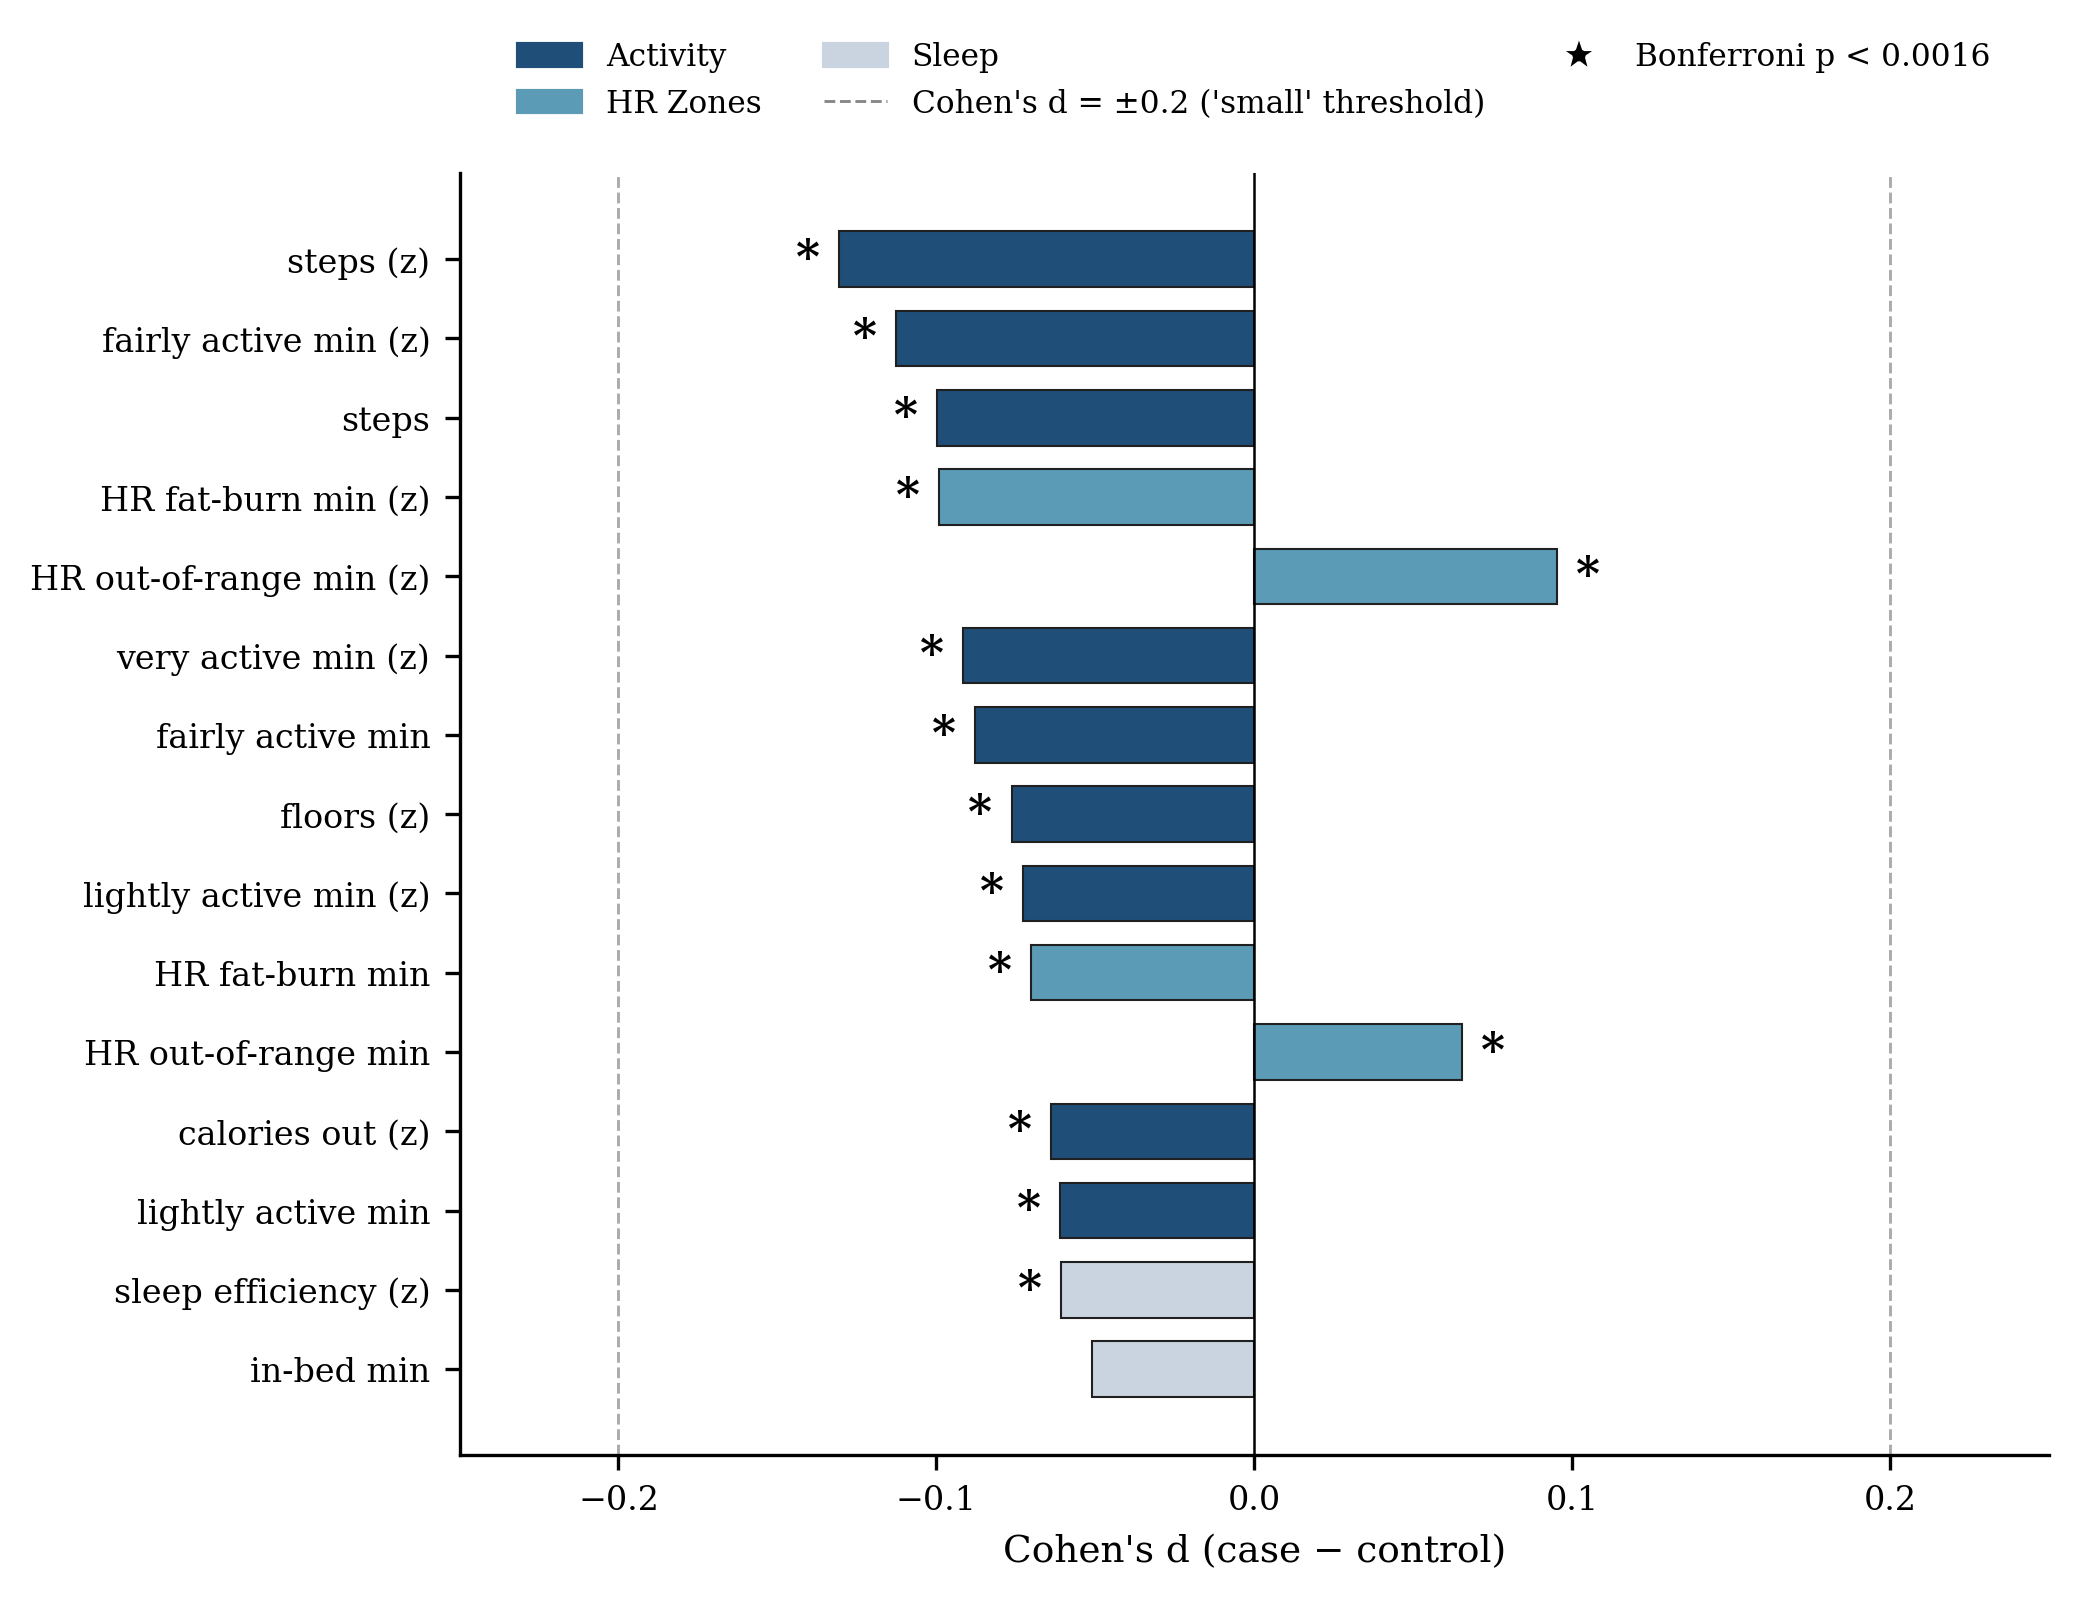

Saved Figure 2 v4 (three-blue palette)


In [9]:
# FIGURE 2 v4 — three distinct blues, properly contrasted

modality_colors = {
    'Activity':         '#1f4e79',   # dark navy blue
    'Heart Rate Zones': '#5b9bb5',   # teal-blue
    'Sleep':            '#c9d4e0',   # pale gray-blue
}

top15 = effect_df.nlargest(15, 'abs_cohen_d').copy()
top15['label'] = top15['feature'].apply(pretty_name)
top15 = top15.iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7.0, 5.4))

y_positions = np.arange(len(top15))
bar_colors  = [modality_colors[m] for m in top15['modality']]

ax.barh(y_positions, top15['cohen_d'],
        color=bar_colors, edgecolor='#202020', linewidth=0.5, height=0.7)

for i, row in top15.iterrows():
    if row['bonferroni_sig']:
        offset = 0.006 if row['cohen_d'] > 0 else -0.006
        ha = 'left' if row['cohen_d'] > 0 else 'right'
        ax.text(row['cohen_d'] + offset, y_positions[i],
                '*', ha=ha, va='center', fontsize=11, fontweight='bold')

ax.axvline(0, color='black', linewidth=0.6)
ax.axvline(-0.2, color='#888', linestyle='--', linewidth=0.7, alpha=0.7)
ax.axvline(0.2,  color='#888', linestyle='--', linewidth=0.7, alpha=0.7)

ax.set_yticks(y_positions)
ax.set_yticklabels(top15['label'], fontsize=8)
ax.set_xlabel("Cohen's d (case − control)")
ax.set_xlim(-0.25, 0.25)

legend_handles = [
    mpatches.Patch(color=modality_colors['Activity'],         label='Activity'),
    mpatches.Patch(color=modality_colors['Heart Rate Zones'], label='HR Zones'),
    mpatches.Patch(color=modality_colors['Sleep'],            label='Sleep'),
    Line2D([0], [0], color='#888', linestyle='--', linewidth=0.7,
           label="Cohen's d = ±0.2 ('small' threshold)"),
    Line2D([0], [0], marker='*', color='w',
           markerfacecolor='black', markersize=10,
           label='Bonferroni p < 0.0016'),
]
ax.legend(handles=legend_handles,
          loc='lower center', bbox_to_anchor=(0.5, 1.02),
          ncol=3, frameon=False, fontsize=7.5)

plt.tight_layout()
plt.savefig('paper_figures/figure_2_effect_sizes.png', dpi=300, bbox_inches='tight')
plt.savefig('paper_figures/figure_2_effect_sizes.pdf', bbox_inches='tight')
plt.show()
print("Saved Figure 2 v4 (three-blue palette)")

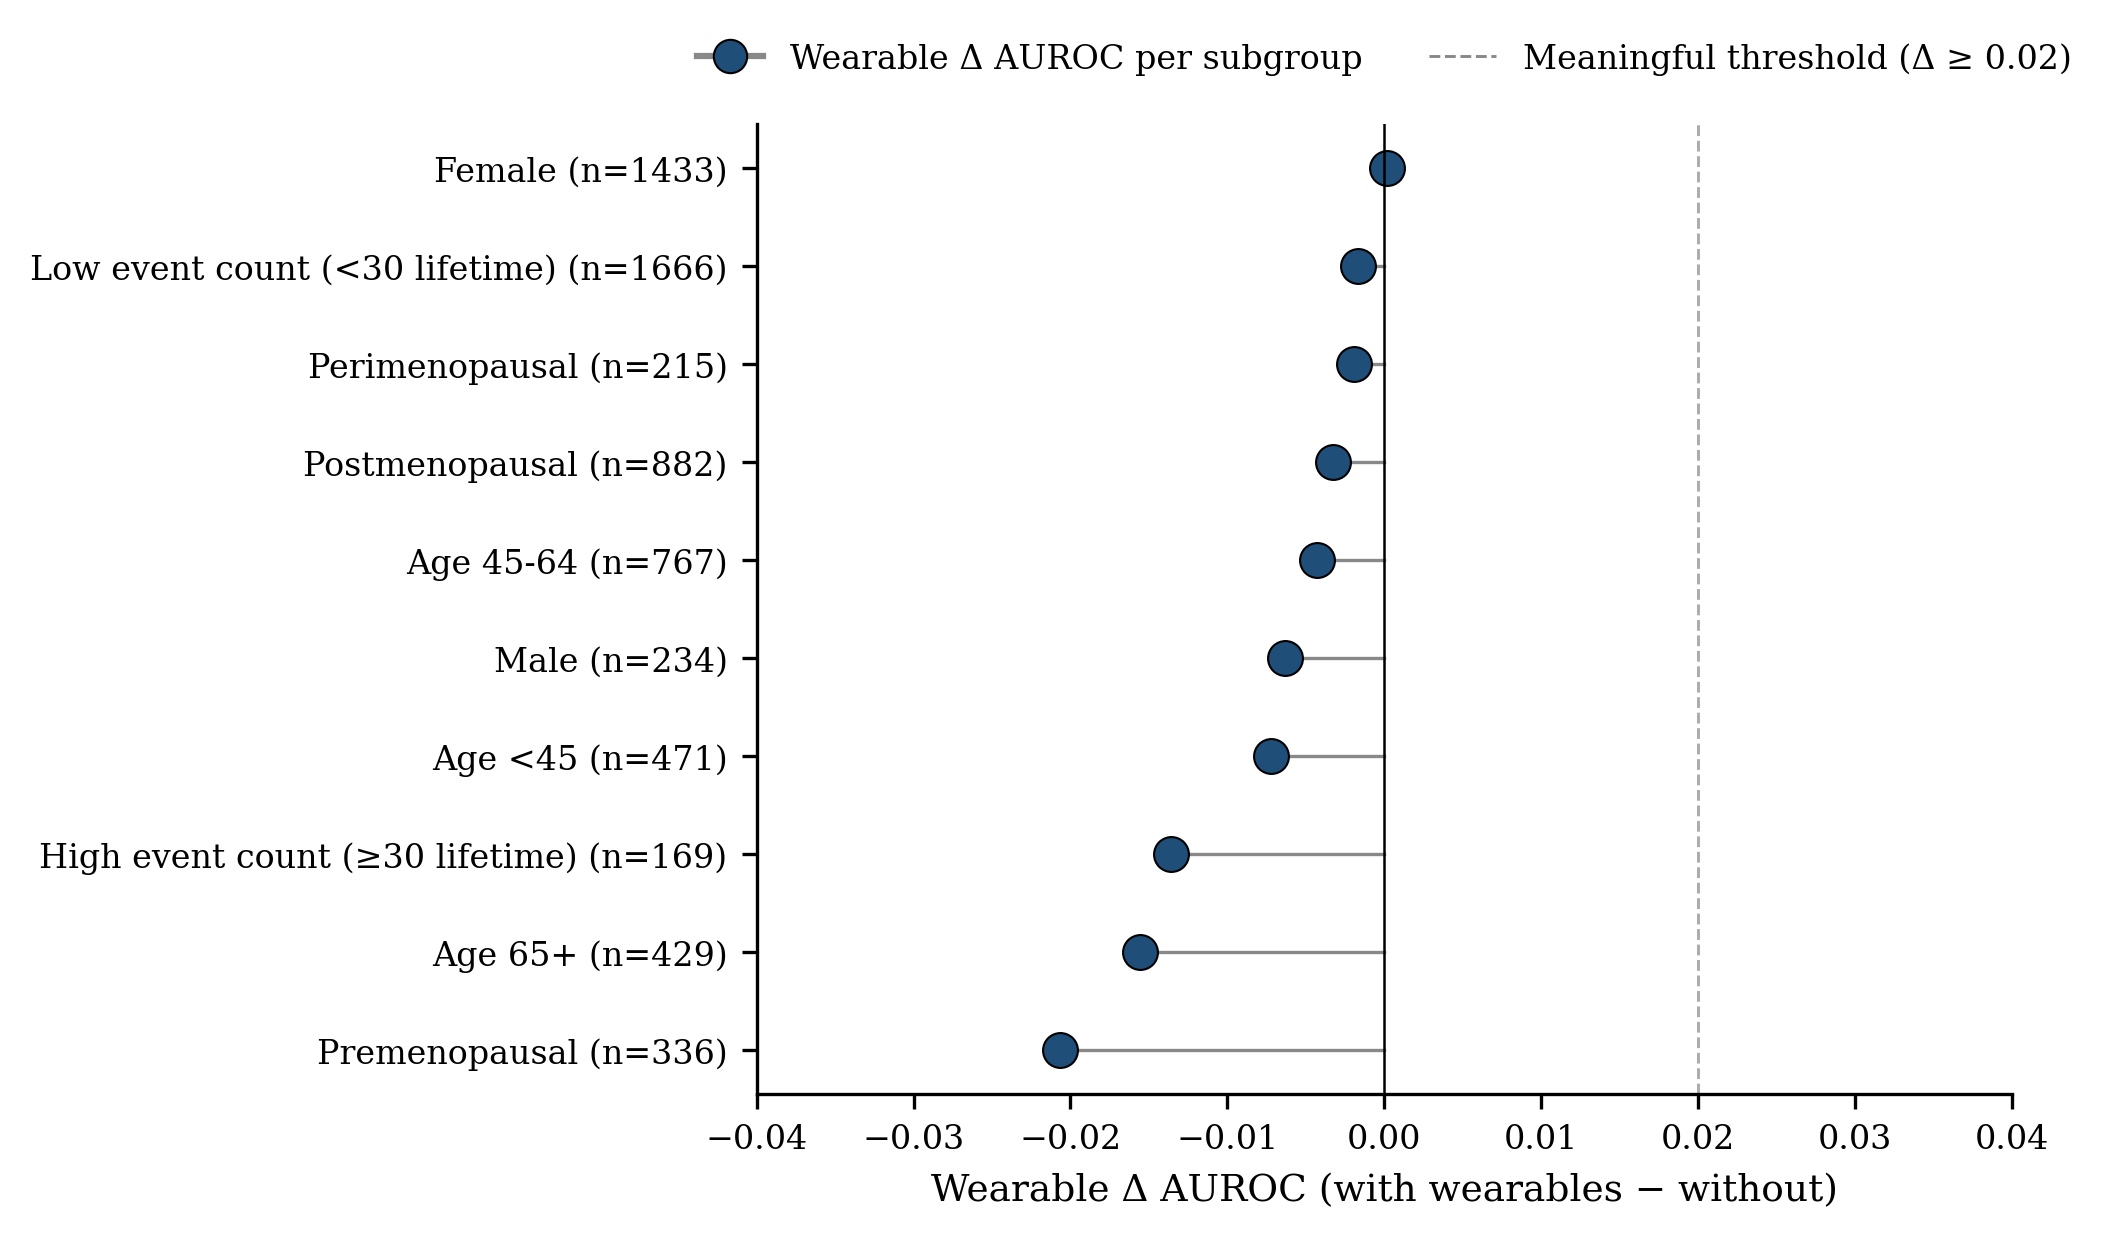

Saved Figure 4 v2 (clearer x-axis label)


In [12]:
# FIGURE 4 v2 — clearer x-axis label

sub = subgroup_df.copy()
sub = sub.sort_values('wearable_delta').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7.0, 4.2))

y = np.arange(len(sub))

# Lollipop sticks (lines from zero to point)
for i, row in sub.iterrows():
    ax.plot([0, row['wearable_delta']], [i, i],
            color='#888', linewidth=0.8, zorder=1)

# Lollipop heads (points at the delta value)
ax.scatter(sub['wearable_delta'], y,
           s=70, color='#1f4e79', edgecolor='black',
           linewidth=0.5, zorder=2)

# Reference lines
ax.axvline(0, color='black', linewidth=0.6)
ax.axvline(0.02, color='#888', linestyle='--', linewidth=0.7, alpha=0.7)

# Y-axis labels: subgroup name with N
labels = [f"{r['subgroup']} (n={r['n_patients']})" for _, r in sub.iterrows()]
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Wearable Δ AUROC (with wearables − without)')
ax.set_xlim(-0.04, 0.04)

# Legend above plot
legend_handles = [
    Line2D([0], [0], marker='o', color='#888', markerfacecolor='#1f4e79',
           markersize=8, markeredgecolor='black', markeredgewidth=0.5,
           label='Wearable Δ AUROC per subgroup'),
    Line2D([0], [0], color='#888', linestyle='--', linewidth=0.7,
           label='Meaningful threshold (Δ ≥ 0.02)'),
]
ax.legend(handles=legend_handles,
          loc='lower center', bbox_to_anchor=(0.5, 1.02),
          ncol=2, frameon=False, fontsize=8)

plt.tight_layout()
plt.savefig('paper_figures/figure_4_subgroups.png', dpi=300, bbox_inches='tight')
plt.savefig('paper_figures/figure_4_subgroups.pdf', bbox_inches='tight')
plt.show()
print("Saved Figure 4 v2 (clearer x-axis label)")

In [13]:
print("Columns in analytic_cohort.csv:")
print(list(analytic_df.columns))
print()
print("Number of rows:", len(analytic_df))
print()
print("Sample row (transposed):")
print(analytic_df.head(1).T)

Columns in analytic_cohort.csv:
['person_id', 'n_fitbit_days', 'n_encounters', 'n_drug_events', 'n_total_events']

Number of rows: 1700

Sample row (transposed):
                      0
person_id       6986318
n_fitbit_days       448
n_encounters         13
n_drug_events         0
n_total_events       13


In [16]:
# TABLE V v2 — clean labels, drop unreliable percentages

# Re-pull race/ethnicity (skip if already in memory)
# Skipping the BigQuery since we already have race_df from the previous run.

# Re-merge with clean handling of "Not reported" categories
demo = analytic_df.merge(
    hormonal[['person_id', 'gender', 'current_age', 'menopausal_status']],
    on='person_id', how='left'
).merge(
    race_df, on='person_id', how='left'
)

# Normalize race labels — merge equivalent "not reported" categories
def normalize_race(r):
    if pd.isna(r):
        return 'Not reported'
    mapping = {
        'Black or African American': 'Black / African American',
        'More than one population':  'More than one race',
        'None Indicated':            'Not reported',
        'None of these':             'Not reported',
        'PMI: Skip':                 'Not reported',
        'I prefer not to answer':    'Not reported',
        'Another single population': 'Other',
    }
    return mapping.get(r, r)

def normalize_ethnicity(e):
    if pd.isna(e):
        return 'Not reported'
    mapping = {
        'Hispanic or Latino':     'Hispanic / Latino',
        'Not Hispanic or Latino': 'Not Hispanic / Latino',
        'What Race Ethnicity: Race Ethnicity None Of These': 'Not reported',
        'PMI: Skip':              'Not reported',
        'PMI: Prefer Not To Answer': 'Not reported',
    }
    return mapping.get(e, e)

demo['race_clean']      = demo['race'].apply(normalize_race)
demo['ethnicity_clean'] = demo['ethnicity'].apply(normalize_ethnicity)

n_total = len(demo)

def fmt_pct(n, total):
    return f"{n:,} ({100*n/total:.1f}%)"

def fmt_median_iqr(x):
    x_clean = x.dropna()
    return f"{x_clean.median():.0f} ({x_clean.quantile(0.25):.0f}–{x_clean.quantile(0.75):.0f})"

rows = []

# Cohort size
rows.append(('Total participants', f'{n_total:,}'))

# Age
rows.append(('Age, median (IQR), years', fmt_median_iqr(demo['current_age'])))

# Sex
rows.append(('Sex assigned at birth, n (%)', ''))
for gender in ['Female', 'Male']:
    n = (demo['gender'] == gender).sum()
    rows.append((f'    {gender}', fmt_pct(n, n_total)))
n_other = ((demo['gender'].notna()) & (~demo['gender'].isin(['Female', 'Male']))).sum() + demo['gender'].isna().sum()
if n_other > 0:
    rows.append(('    Other / Not reported', fmt_pct(n_other, n_total)))

# Race — using cleaned labels, preserving display order
rows.append(('Race, n (%)', ''))
race_order = ['White', 'Black / African American', 'Asian',
              'More than one race', 'Other', 'Not reported']
race_counts = demo['race_clean'].value_counts()
for race in race_order:
    if race in race_counts.index:
        rows.append((f'    {race}', fmt_pct(race_counts[race], n_total)))

# Ethnicity — using cleaned labels
rows.append(('Ethnicity, n (%)', ''))
eth_order = ['Hispanic / Latino', 'Not Hispanic / Latino', 'Not reported']
eth_counts = demo['ethnicity_clean'].value_counts()
for eth in eth_order:
    if eth in eth_counts.index:
        rows.append((f'    {eth}', fmt_pct(eth_counts[eth], n_total)))

# Menopausal status (women only)
women = demo[demo['gender'] == 'Female']
n_women = len(women)
rows.append((f'Menopausal status (women, n={n_women:,}), n (%)', ''))
status_order = ['premenopausal', 'likely_premenopausal',
                'perimenopausal', 'likely_perimenopausal',
                'postmenopausal', 'likely_postmenopausal',
                'not_applicable']
for status in status_order:
    n = (women['menopausal_status'] == status).sum()
    if n > 0:
        label = status.replace('_', ' ').capitalize()
        rows.append((f'    {label}', fmt_pct(n, n_women)))

# Migraine events (without unreliable encounter/drug breakdown)
rows.append(('Migraine events per participant', ''))
rows.append(('    Median (IQR)', fmt_median_iqr(demo['n_total_events'])))
rows.append(('    Range', f"{int(demo['n_total_events'].min())}–{int(demo['n_total_events'].max())}"))
rows.append(('Total events across cohort (deduplicated)', '21,640'))

# Fitbit coverage
rows.append(('Fitbit observation, days per participant', ''))
rows.append(('    Median (IQR)', fmt_median_iqr(demo['n_fitbit_days'])))
rows.append(('    Range', f"{int(demo['n_fitbit_days'].min())}–{int(demo['n_fitbit_days'].max())}"))

# Build and save
demo_table = pd.DataFrame(rows, columns=['Characteristic', 'Value'])
demo_table.to_csv('paper_figures/table_V_demographics.csv', index=False)

print("="*70)
print("TABLE V — COHORT DEMOGRAPHICS (v2, cleaned)")
print("="*70)
print(demo_table.to_string(index=False))
print(f"\nSaved to paper_figures/table_V_demographics.csv")

# Verification: race counts should sum to 1,700
print(f"\nRace count check: {demo['race_clean'].value_counts().sum():,} (should be {n_total:,})")
print(f"Ethnicity count check: {demo['ethnicity_clean'].value_counts().sum():,} (should be {n_total:,})")

TABLE V — COHORT DEMOGRAPHICS (v2, cleaned)
                           Characteristic          Value
                       Total participants          1,700
                 Age, median (IQR), years     53 (43–65)
             Sex assigned at birth, n (%)               
                                   Female  1,464 (86.1%)
                                     Male    184 (10.8%)
                     Other / Not reported      52 (3.1%)
                              Race, n (%)               
                                    White  1,348 (79.3%)
                 Black / African American     119 (7.0%)
                                    Asian      20 (1.2%)
                       More than one race     113 (6.6%)
                                    Other      14 (0.8%)
                             Not reported      86 (5.1%)
                         Ethnicity, n (%)               
                        Hispanic / Latino     104 (6.1%)
                    Not Hispanic / Latino  1

In [17]:
# TABLE VI — Effect sizes by modality

modality_summary = effect_df.groupby('modality').agg(
    n_features    = ('feature',         'count'),
    n_p_lt_05     = ('significant',     'sum'),
    n_bonferroni  = ('bonferroni_sig',  'sum'),
    mean_abs_d    = ('abs_cohen_d',     'mean'),
    max_abs_d     = ('abs_cohen_d',     'max'),
)

# Reorder rows
modality_summary = modality_summary.reindex(
    ['Activity', 'Heart Rate Zones', 'Sleep'])

# Add overall row
overall_row = pd.DataFrame({
    'n_features':    [len(effect_df)],
    'n_p_lt_05':     [effect_df['significant'].sum()],
    'n_bonferroni':  [effect_df['bonferroni_sig'].sum()],
    'mean_abs_d':    [effect_df['abs_cohen_d'].mean()],
    'max_abs_d':     [effect_df['abs_cohen_d'].max()],
}, index=['Overall'])

modality_summary = pd.concat([modality_summary, overall_row])

# Format for display: round and convert to strings
modality_table = pd.DataFrame({
    'Modality':                    modality_summary.index,
    'Features tested':             modality_summary['n_features'].astype(int),
    'Significant (p < 0.05)':      modality_summary['n_p_lt_05'].astype(int).astype(str) +
                                   '/' + modality_summary['n_features'].astype(int).astype(str),
    'Bonferroni (p < 0.0016)':     modality_summary['n_bonferroni'].astype(int).astype(str) +
                                   '/' + modality_summary['n_features'].astype(int).astype(str),
    'Mean |Cohen\'s d|':           modality_summary['mean_abs_d'].round(3),
    'Max |Cohen\'s d|':            modality_summary['max_abs_d'].round(3),
}).reset_index(drop=True)

modality_table.to_csv('paper_figures/table_VI_effect_sizes_by_modality.csv', index=False)

print("="*80)
print("TABLE VI — EFFECT SIZES BY MODALITY")
print("="*80)
print(modality_table.to_string(index=False))
print(f"\nSaved to paper_figures/table_VI_effect_sizes_by_modality.csv")

TABLE VI — EFFECT SIZES BY MODALITY
        Modality  Features tested Significant (p < 0.05) Bonferroni (p < 0.0016)  Mean |Cohen's d|  Max |Cohen's d|
        Activity               14                  13/14                   12/14             0.068            0.131
Heart Rate Zones               10                   8/10                    8/10             0.049            0.099
           Sleep                8                    7/8                     5/8             0.034            0.061
         Overall               32                  28/32                   25/32             0.053            0.131

Saved to paper_figures/table_VI_effect_sizes_by_modality.csv


In [18]:
# TABLE VII — Full incremental model results

table_vii = incremental_results.copy()

# Formatted strings for the paper
table_vii['Model']               = table_vii['model']
table_vii['Feature set']         = table_vii['description']
table_vii['n features']          = table_vii['n_features']
table_vii['Logistic AUROC']      = (table_vii['auroc_logistic'].round(3).astype(str) +
                                    ' ± ' +
                                    table_vii['auroc_logistic_std'].round(3).astype(str))
table_vii['XGBoost AUROC']       = (table_vii['auroc_xgboost'].round(3).astype(str) +
                                    ' ± ' +
                                    table_vii['auroc_xgboost_std'].round(3).astype(str))

# Δ AUROC between consecutive models, for the XGBoost (primary model)
deltas = table_vii['auroc_xgboost'].diff().round(3)
table_vii['Δ AUROC (XGB)'] = deltas.apply(
    lambda d: '—' if pd.isna(d) else f'{d:+.3f}'
)

# Final table — drop the raw numeric columns
table_vii_clean = table_vii[['Model', 'Feature set', 'n features',
                              'Logistic AUROC', 'XGBoost AUROC',
                              'Δ AUROC (XGB)']].reset_index(drop=True)

table_vii_clean.to_csv('paper_figures/table_VII_incremental_models.csv', index=False)

print("="*100)
print("TABLE VII — INCREMENTAL MODEL RESULTS")
print("="*100)
print(table_vii_clean.to_string(index=False))
print(f"\nSaved to paper_figures/table_VII_incremental_models.csv")

TABLE VII — INCREMENTAL MODEL RESULTS
Model             Feature set  n features Logistic AUROC XGBoost AUROC Δ AUROC (XGB)
    A            Demographics           5  0.505 ± 0.008  0.511 ± 0.01             —
    B         + Event history          14  0.672 ± 0.016 0.735 ± 0.015        +0.224
    C        + Wearable means          30  0.674 ± 0.017 0.739 ± 0.012        +0.004
    D     + Wearable z-scores          46  0.679 ± 0.019 0.737 ± 0.013        -0.002
    E + Wearable trajectories         110  0.676 ± 0.019 0.736 ± 0.015        -0.001

Saved to paper_figures/table_VII_incremental_models.csv


In [19]:
import os, glob
print("All files in paper_figures/:")
for f in sorted(glob.glob('paper_figures/*')):
    size = os.path.getsize(f)
    print(f"  {f}  {size:,} bytes")

All files in paper_figures/:
  paper_figures/figure_2_effect_sizes.pdf  19,541 bytes
  paper_figures/figure_2_effect_sizes.png  164,494 bytes
  paper_figures/figure_3_incremental_auroc.pdf  24,821 bytes
  paper_figures/figure_3_incremental_auroc.png  147,388 bytes
  paper_figures/figure_4_subgroups.pdf  20,526 bytes
  paper_figures/figure_4_subgroups.png  170,535 bytes
  paper_figures/table_VII_incremental_models.csv  369 bytes
  paper_figures/table_VI_effect_sizes_by_modality.csv  246 bytes
  paper_figures/table_V_demographics.csv  943 bytes


In [4]:
# ============================================================
# FULL SETUP — re-import, reload CSVs, set IEEE rcParams
# ============================================================

import os, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Reload AoU environment
result = subprocess.run(['bash', '-c', 'source ~/load-env.sh && env'],
                        capture_output=True, text=True)
for line in result.stdout.split('\n'):
    if '=' in line:
        key, _, value = line.partition('=')
        if any(k in key.upper() for k in ['CDR', 'WORKSPACE', 'GOOGLE_PROJECT', 'AOU', 'BUCKET']):
            os.environ[key] = value

# Reload CSVs
analytic_df = pd.read_csv('analytic_cohort.csv')
hormonal    = pd.read_csv('hormonal_status.csv')
effect_df   = pd.read_csv('effect_sizes_categorized.csv')
subgroup_df = pd.read_csv('subgroup_results.csv')

# Re-categorize effect_df (CSV has the old, possibly stale categorization)
def categorize_feature(feat):
    f = feat.lower()
    if any(k in f for k in ['steps', 'sedentary', 'lightly_active',
                            'fairly_active', 'very_active', 'calories_out',
                            'floors']):
        return 'Activity'
    if any(k in f for k in ['out_of_range', 'fat_burn', 'cardio',
                            'peak', 'total_calories_burned']):
        return 'Heart Rate Zones'
    if any(k in f for k in ['in_bed', 'asleep', 'awake', 'sleep_efficiency']):
        return 'Sleep'
    return 'Other'
effect_df['modality'] = effect_df['feature'].apply(categorize_feature)

# Pretty-name function for feature labels
def pretty_name(feat):
    s = feat
    is_z = '_zscore' in s
    s = s.replace('_zscore', '').replace('_mean', '')
    replacements = [
        ('minutes_out_of_range',     'HR out-of-range min'),
        ('minutes_fat_burn',         'HR fat-burn min'),
        ('minutes_cardio',           'HR cardio min'),
        ('minutes_peak',             'HR peak min'),
        ('total_calories_burned',    'total cal. burned'),
        ('lightly_active_minutes',   'lightly active min'),
        ('fairly_active_minutes',    'fairly active min'),
        ('very_active_minutes',      'very active min'),
        ('sedentary_minutes',        'sedentary min'),
        ('calories_out',             'calories out'),
        ('in_bed_minutes',           'in-bed min'),
        ('asleep_minutes',           'asleep min'),
        ('awake_minutes',            'awake min'),
        ('sleep_efficiency',         'sleep efficiency'),
        ('floors',                   'floors'),
        ('steps',                    'steps'),
    ]
    for old, new in replacements:
        if old in s:
            s = new
            break
    if is_z:
        s = s + ' (z)'
    return s

# Hardcoded incremental modeling results
incremental_results = pd.DataFrame({
    'model': ['A', 'B', 'C', 'D', 'E'],
    'description': ['Demographics', '+ Event history', '+ Wearable means',
                    '+ Wearable z-scores', '+ Wearable trajectories'],
    'auroc_logistic':     [0.505, 0.672, 0.674, 0.679, 0.676],
    'auroc_logistic_std': [0.008, 0.016, 0.017, 0.019, 0.019],
    'auroc_xgboost':      [0.511, 0.735, 0.739, 0.737, 0.736],
    'auroc_xgboost_std':  [0.010, 0.015, 0.012, 0.013, 0.015],
    'n_features':         [5, 14, 30, 46, 110],
})

# IEEE column-width rcParams
plt.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size':         8,
    'axes.titlesize':    9,
    'axes.labelsize':    8,
    'xtick.labelsize':   7,
    'ytick.labelsize':   7,
    'legend.fontsize':   7,
    'figure.dpi':        300,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
})

edge = '#202020'

os.makedirs('paper_figures', exist_ok=True)

print("Setup complete:")
print(f"  Cohort:         {len(analytic_df):,} patients")
print(f"  Effect sizes:   {len(effect_df)} features")
print(f"  Subgroups:      {len(subgroup_df)} subgroup analyses")
print(f"  Incremental:    {len(incremental_results)} nested models")
print(f"  Modality split: {effect_df['modality'].value_counts().to_dict()}")
print(f"\nReady to render figures at IEEE column width (3.5\").")

Setup complete:
  Cohort:         1,700 patients
  Effect sizes:   32 features
  Subgroups:      10 subgroup analyses
  Incremental:    5 nested models
  Modality split: {'Activity': 14, 'Heart Rate Zones': 10, 'Sleep': 8}

Ready to render figures at IEEE column width (3.5").


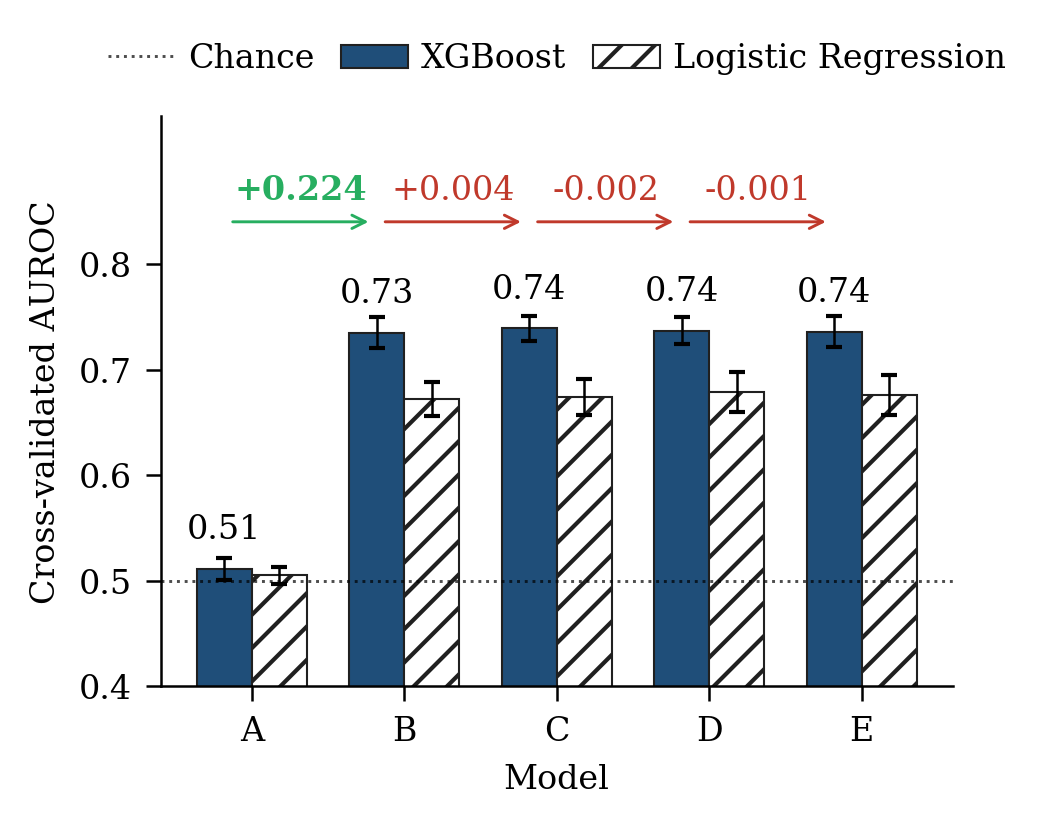

Saved Figure 3 v9 (uniform 8pt fonts)


In [10]:
# === FIGURE 3 v9 — uniform 8pt fonts ===

fig, ax = plt.subplots(figsize=(3.5, 2.8))

x_positions = np.arange(len(incremental_results))
bar_width = 0.36

ax.bar(x_positions - bar_width/2,
       incremental_results['auroc_xgboost'],
       width=bar_width,
       yerr=incremental_results['auroc_xgboost_std'],
       color='#1f4e79', edgecolor=edge, linewidth=0.5,
       capsize=2, error_kw={'elinewidth': 0.6},
       label='XGBoost')

ax.bar(x_positions + bar_width/2,
       incremental_results['auroc_logistic'],
       width=bar_width,
       yerr=incremental_results['auroc_logistic_std'],
       color='white', edgecolor=edge, linewidth=0.5,
       hatch='///', capsize=2, error_kw={'elinewidth': 0.6},
       label='Logistic Regression')

# AUROC value labels — uniform 8pt
for i, v in enumerate(incremental_results['auroc_xgboost']):
    ax.text(x_positions[i] - bar_width/2, v + 0.022,
            f'{v:.2f}', ha='center', va='bottom', fontsize=8)

# Delta arrows
deltas = np.diff(incremental_results['auroc_xgboost'].values)
arrow_y = 0.84
for i, d in enumerate(deltas):
    x_start = x_positions[i] - bar_width/2
    x_end   = x_positions[i+1] - bar_width/2
    x_mid   = (x_start + x_end) / 2

    ax.annotate('', xy=(x_end, arrow_y), xytext=(x_start, arrow_y),
                arrowprops=dict(arrowstyle='->', lw=0.7,
                                color='#27ae60' if abs(d) > 0.05 else '#c0392b'))
    sign = '+' if d >= 0 else ''
    color = '#27ae60' if abs(d) > 0.05 else '#c0392b'
    weight = 'bold' if abs(d) > 0.05 else 'normal'
    ax.text(x_mid, arrow_y + 0.014,
            f'{sign}{d:.3f}',
            ha='center', va='bottom', fontsize=8,
            color=color, fontweight=weight)

ax.axhline(0.5, color='black', linestyle=':', linewidth=0.7, alpha=0.7,
           label='Chance')

ax.set_xticks(x_positions)
ax.set_xticklabels(incremental_results['model'], fontsize=8)
ax.set_xlabel('Model', fontsize=8)
ax.set_ylabel('Cross-validated AUROC', fontsize=8)
ax.set_ylim(0.40, 0.94)
ax.set_yticks(np.arange(0.4, 0.85, 0.1))
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels,
          loc='lower center', bbox_to_anchor=(0.5, 1.02),
          ncol=3, frameon=False, fontsize=8,
          handletextpad=0.4, columnspacing=0.8)

plt.tight_layout()
plt.savefig('paper_figures/figure_3_incremental_auroc.png', dpi=300, bbox_inches='tight')
plt.savefig('paper_figures/figure_3_incremental_auroc.pdf', bbox_inches='tight')
plt.show()
print("Saved Figure 3 v9 (uniform 8pt fonts)")

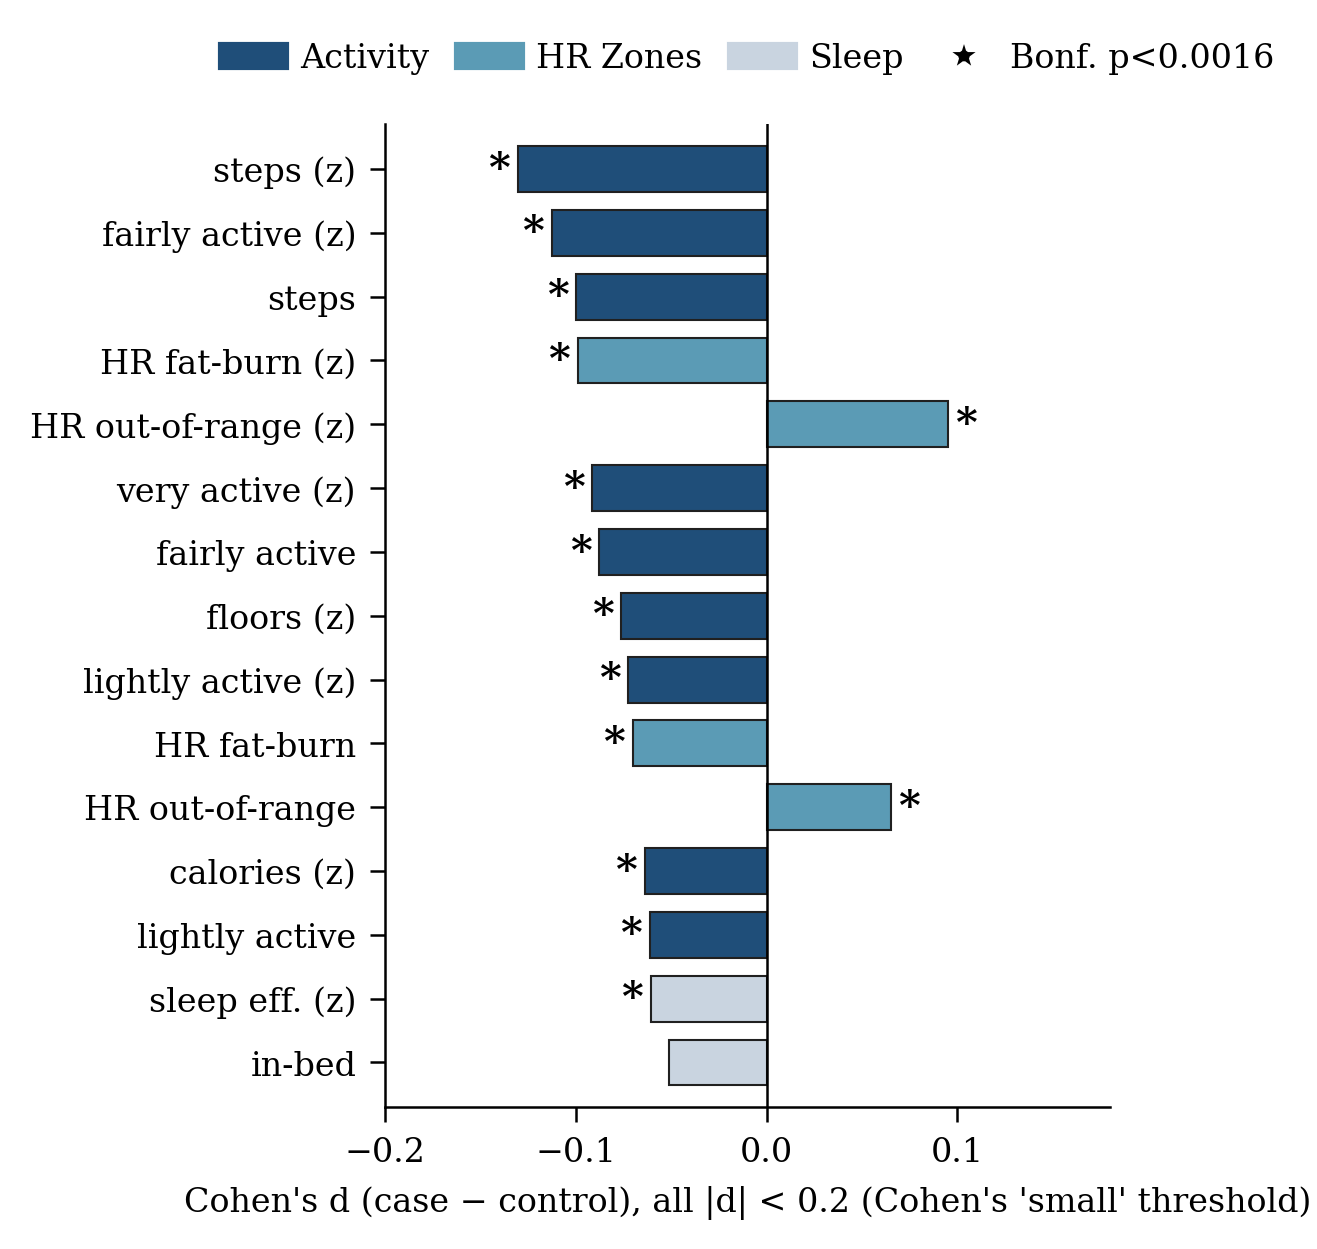

Saved Figure 2 v12 (no auto-scaling)


In [18]:
# === FIGURE 2 v12 — fixed scaling issue ===

modality_colors = {
    'Activity':         '#1f4e79',
    'Heart Rate Zones': '#5b9bb5',
    'Sleep':            '#c9d4e0',
}

def short_name(feat):
    s = feat
    is_z = '_zscore' in s
    s = s.replace('_zscore', '').replace('_mean', '')
    replacements = [
        ('minutes_out_of_range',     'HR out-of-range'),
        ('minutes_fat_burn',         'HR fat-burn'),
        ('minutes_cardio',           'HR cardio'),
        ('minutes_peak',             'HR peak'),
        ('total_calories_burned',    'total cal.'),
        ('lightly_active_minutes',   'lightly active'),
        ('fairly_active_minutes',    'fairly active'),
        ('very_active_minutes',      'very active'),
        ('sedentary_minutes',        'sedentary'),
        ('calories_out',             'calories'),
        ('in_bed_minutes',           'in-bed'),
        ('asleep_minutes',           'asleep'),
        ('awake_minutes',            'awake'),
        ('sleep_efficiency',         'sleep eff.'),
        ('floors',                   'floors'),
        ('steps',                    'steps'),
    ]
    for old, new in replacements:
        if old in s:
            s = new
            break
    if is_z:
        s = s + ' (z)'
    return s

top15 = effect_df.nlargest(15, 'abs_cohen_d').copy()
top15['label'] = top15['feature'].apply(short_name)
top15 = top15.iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(3.5, 4.2))

y_positions = np.arange(len(top15))
bar_colors  = [modality_colors[m] for m in top15['modality']]

ax.barh(y_positions, top15['cohen_d'],
        color=bar_colors, edgecolor='#202020', linewidth=0.5, height=0.72)

for i, row in top15.iterrows():
    if row['bonferroni_sig']:
        offset = 0.004 if row['cohen_d'] > 0 else -0.004
        ha = 'left' if row['cohen_d'] > 0 else 'right'
        ax.text(row['cohen_d'] + offset, y_positions[i],
                '*', ha=ha, va='center', fontsize=10, fontweight='bold')

ax.axvline(0, color='black', linewidth=0.6)

ax.set_xlim(-0.20, 0.18)
ax.set_xticks([-0.2, -0.1, 0, 0.1])
ax.set_yticks(y_positions)
ax.set_yticklabels(top15['label'], fontsize=8)
ax.set_xlabel("Cohen's d (case − control), all |d| < 0.2 (Cohen's 'small' threshold)",
              fontsize=8)
ax.set_ylim(-0.7, len(top15) - 0.3)
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8)

legend_handles = [
    mpatches.Patch(color=modality_colors['Activity'],         label='Activity'),
    mpatches.Patch(color=modality_colors['Heart Rate Zones'], label='HR Zones'),
    mpatches.Patch(color=modality_colors['Sleep'],            label='Sleep'),
    Line2D([0], [0], marker='*', color='w',
           markerfacecolor='black', markersize=9,
           label='Bonf. p<0.0016'),
]
ax.legend(handles=legend_handles,
          loc='lower center', bbox_to_anchor=(0.5, 1.02),
          ncol=4, frameon=False, fontsize=8,
          handletextpad=0.4, columnspacing=0.8)

# Critical fix: explicit subplots_adjust, NO bbox_inches='tight'
plt.subplots_adjust(left=0.28, right=0.97, top=0.88, bottom=0.10)
plt.savefig('paper_figures/figure_2_effect_sizes.png', dpi=300)
plt.savefig('paper_figures/figure_2_effect_sizes.pdf')
plt.show()
print("Saved Figure 2 v12 (no auto-scaling)")

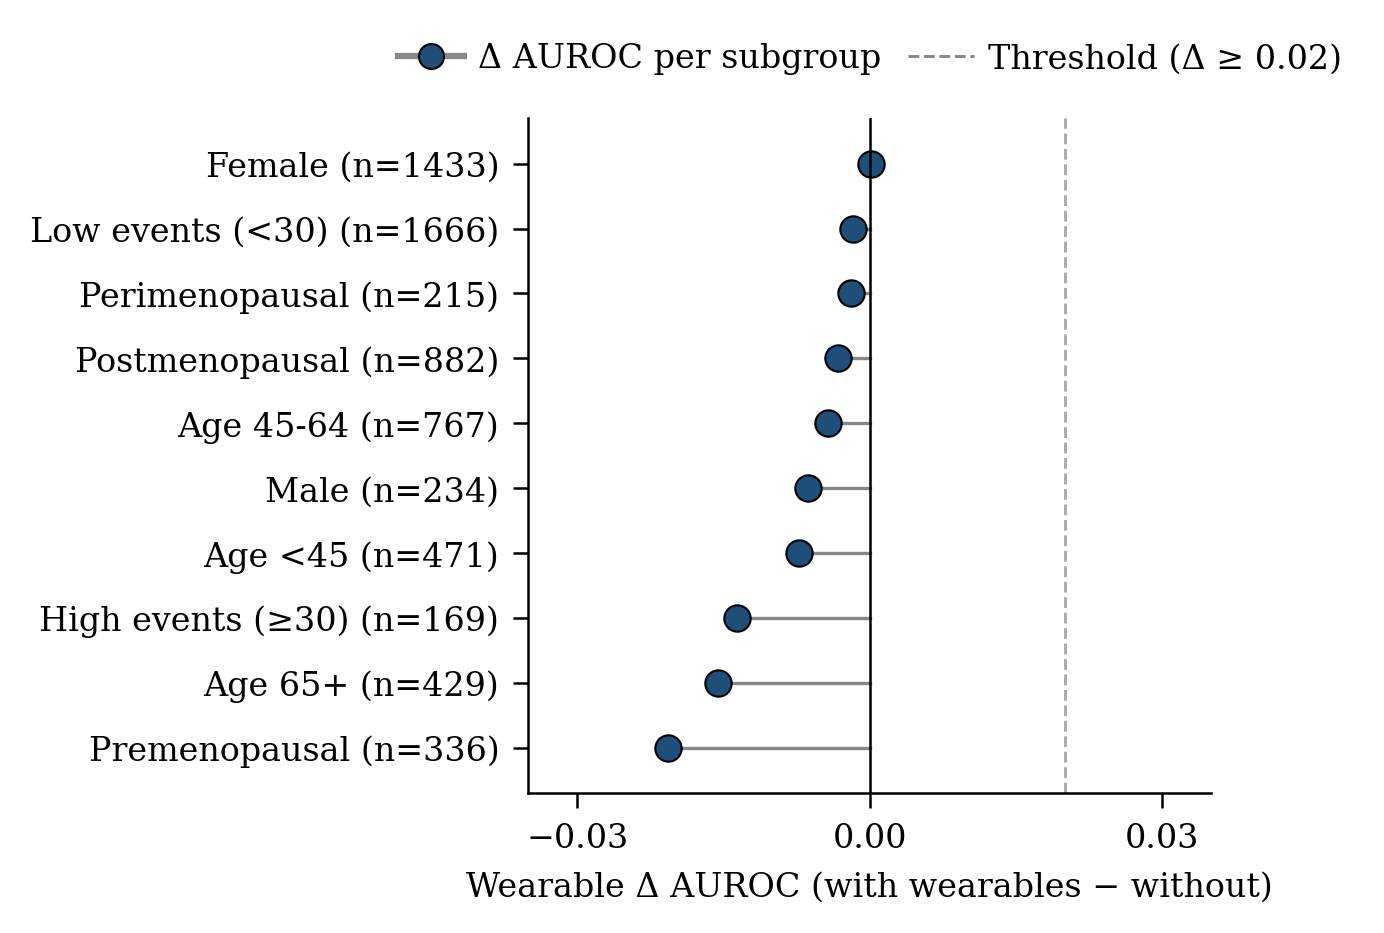

Saved Figure 4 v5 (no auto-scaling)


In [20]:
# === FIGURE 4 v5 — fixed scaling issue ===

sub = subgroup_df.copy()
sub = sub.sort_values('wearable_delta').reset_index(drop=True)

def short_subgroup(s):
    s = s.replace('event count', 'events')
    s = s.replace('lifetime', 'life.')
    s = s.replace('(≥30 life.)', '(≥30)')
    s = s.replace('(<30 life.)', '(<30)')
    return s

fig, ax = plt.subplots(figsize=(3.5, 3.0))

y = np.arange(len(sub))

for i, row in sub.iterrows():
    ax.plot([0, row['wearable_delta']], [i, i],
            color='#888', linewidth=0.8, zorder=1)

ax.scatter(sub['wearable_delta'], y,
           s=40, color='#1f4e79', edgecolor='black',
           linewidth=0.5, zorder=2)

ax.axvline(0, color='black', linewidth=0.6)
ax.axvline(0.02, color='#888', linestyle='--', linewidth=0.7, alpha=0.7)

labels = [f"{short_subgroup(r['subgroup'])} (n={r['n_patients']})"
          for _, r in sub.iterrows()]
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Wearable Δ AUROC (with wearables − without)', fontsize=8)
ax.set_xlim(-0.035, 0.035)
ax.set_xticks([-0.03, 0, 0.03])
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8)
ax.set_ylim(-0.7, len(sub) - 0.3)

legend_handles = [
    Line2D([0], [0], marker='o', color='#888', markerfacecolor='#1f4e79',
           markersize=6, markeredgecolor='black', markeredgewidth=0.5,
           label='Δ AUROC per subgroup'),
    Line2D([0], [0], color='#888', linestyle='--', linewidth=0.7,
           label='Threshold (Δ ≥ 0.02)'),
]
ax.legend(handles=legend_handles,
          loc='lower center', bbox_to_anchor=(0.5, 1.02),
          ncol=2, frameon=False, fontsize=8,
          handletextpad=0.4, columnspacing=0.8)

# Critical fix
plt.subplots_adjust(left=0.32, right=0.97, top=0.88, bottom=0.13)
plt.savefig('paper_figures/figure_4_subgroups.png', dpi=300)
plt.savefig('paper_figures/figure_4_subgroups.pdf')
plt.show()
print("Saved Figure 4 v5 (no auto-scaling)")

In [2]:
import os, subprocess
from google.cloud import bigquery

# Reload AoU environment if kernel restarted
result = subprocess.run(['bash', '-c', 'source ~/load-env.sh && env'],
                        capture_output=True, text=True)
for line in result.stdout.split('\n'):
    if '=' in line:
        key, _, value = line.partition('=')
        if any(k in key.upper() for k in ['CDR', 'WORKSPACE', 'GOOGLE_PROJECT', 'AOU', 'BUCKET']):
            os.environ[key] = value

CDR = os.environ['WORKSPACE_CDR']
client = bigquery.Client()

query = f"""
WITH prediabetic AS (
  SELECT DISTINCT person_id 
  FROM `{CDR}.measurement`
  WHERE measurement_concept_id IN (3004410, 3005673, 40762352)
    AND value_as_number BETWEEN 5.7 AND 6.4
),
wgs_participants AS (
  SELECT DISTINCT person_id 
  FROM `{CDR}.cb_search_person`
  WHERE has_whole_genome_variant = 1
),
fitbit_participants AS (
  SELECT DISTINCT person_id 
  FROM `{CDR}.activity_summary`
)
SELECT 
  COUNT(DISTINCT p.person_id) AS prediabetic,
  COUNT(DISTINCT CASE WHEN w.person_id IS NOT NULL THEN p.person_id END) AS with_wgs,
  COUNT(DISTINCT CASE WHEN f.person_id IS NOT NULL THEN p.person_id END) AS with_fitbit,
  COUNT(DISTINCT CASE WHEN w.person_id IS NOT NULL AND f.person_id IS NOT NULL 
                       THEN p.person_id END) AS with_both
FROM prediabetic p
LEFT JOIN wgs_participants w ON p.person_id = w.person_id
LEFT JOIN fitbit_participants f ON p.person_id = f.person_id
"""

results = client.query(query).to_dataframe()
print(results.T)

                 0
prediabetic  85026
with_wgs         0
with_fitbit   8096
with_both        0


In [3]:
query = f"""
SELECT column_name 
FROM `{CDR}.INFORMATION_SCHEMA.COLUMNS`
WHERE table_name = 'cb_search_person'
ORDER BY column_name
"""
cols = client.query(query).to_dataframe()
print("All columns in cb_search_person:")
print(cols.to_string())

All columns in cb_search_person:
                           column_name
0                       _PARTITIONTIME
1                           age_at_cdr
2                       age_at_consent
3                                  dob
4                            ethnicity
5                               gender
6                       has_array_data
7                         has_ehr_data
8             has_etm_delaydiscounting
9                     has_etm_emorecog
10                     has_etm_flanker
11                     has_etm_gradcpt
12                          has_fitbit
13         has_fitbit_activity_summary
14       has_fitbit_device_information
15         has_fitbit_heart_rate_level
16       has_fitbit_heart_rate_summary
17  has_fitbit_plus_device_information
18      has_fitbit_sleep_daily_summary
19              has_fitbit_sleep_level
20           has_fitbit_steps_intraday
21         has_lr_whole_genome_variant
22       has_physical_measurement_data
23                 has_ppi_surv

In [4]:
query = f"""
SELECT 
  COUNT(*) AS total_rows,
  SUM(CASE WHEN has_whole_genome_variant = 1 THEN 1 ELSE 0 END) AS wgs_eq_1,
  SUM(CASE WHEN has_whole_genome_variant = 0 THEN 1 ELSE 0 END) AS wgs_eq_0,
  SUM(CASE WHEN has_whole_genome_variant IS NULL THEN 1 ELSE 0 END) AS wgs_null,
  SUM(CASE WHEN has_array_data = 1 THEN 1 ELSE 0 END) AS array_eq_1,
  SUM(CASE WHEN has_fitbit = 1 THEN 1 ELSE 0 END) AS fitbit_eq_1
FROM `{CDR}.cb_search_person`
"""
results = client.query(query).to_dataframe()
print(results.T)

                  0
total_rows   626396
wgs_eq_1          0
wgs_eq_0          0
wgs_null     626396
array_eq_1        0
fitbit_eq_1   58833
